<a href="https://colab.research.google.com/github/Bbasilisco/Glass-Ceiling/blob/main/GlassCeiling_vf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

# **DISPARIDADE SALARIAL ENTRE GÊNEROS NO MERCADO DE TRABALHO FORMAL BRASILEIRO**

---

## **Integrantes**: Beatriz Fonseca, Gisele dos Santos, Juliana Alves, Leila Silva e Mislian Silva

### Fly Educação · diversiData · Grupo 2: *Mulheres in Tech*
Turma Setembro/2026

---

#### **Resumo**

Muito se discute, pública e socialmente, sobre a desigualdade entre gêneros (feminino *versus* masculino) consequente dos moldes da nossa sociedade patriarcal, conservadora e capitalista. Essa desigualdade existe em todos os âmbitos da sociedade, incluindo mercado de trabalho, direitos sociais, violências várias, entre outras.

Este trabalho investiga **um recorte mensurável dela**: a diferença de remuneração por hora entre homens e mulheres no mercado formal brasileiro, usando os microdados da **RAIS** (Relação Anual de Informações Sociais), com um olhar especial para para raça/cor o setor de **Tecnologia da Informação**.

O trabalho tem duas metades que se sustentam:

1. **A metade estatística** (Seções 2 a 4), que descreve, testa e mede o *gap* com testes de hipótese.

2. **A metade preditiva** (Seção 5), que treina um modelo para prever o salário/hora e responder a pergunta *"quanto muda o salário previsto quando a única coisa que muda é o gênero?"*


#### **Introdução e Contextualização**

Atualmente, no mundo, o debate sobre as desigualdades de gênero tem se aprofundado e se acalorado, tendo em vista o movimento feminista, que requer uma equalidade entre os gêneros, para que mulheres (e não apenas mulheres) tenham os mesmos direitos que os homens, que, historicamente, sempre tiveram privilégios e poder em relação às mulheres.

Com o passar dos anos e com a modernidade, inclusive digital, as mulheres têm ganhado mais espaço na esfera pública e privada, além de terem um aumento na participação do mercado de trabalho e no cenário político e de direitos mínimos, como, por exemplo, o direito de ter proteção para que não perca sua vida apenas por existir e ser uma mulher. Quando falamos de outros gêneros, que não os binários já conhecidos (masculino e feminino), e que não são adequados, mais, para descrever os variados tipos de gênero em nossa sociedade, a análise se complexifica ainda mais, pois: a) poucas são as fontes de dados fidedignas que apresentam informações de gênero (a maioridade dos dados dispostos fala sobre sexo, e não sobre gênero, reduzindo a análise a quem nasceu com órgão reprodutor feminino ou órgão reprodutor masculino); e b) a própria ausência de dados disponíveis sobre esses grupos distintos de gênero é um marcador invalidação da identidade de gênero nas esferas públicas.

Com base no que já é sabido e, em parte, exposto aqui, a desigualdade de gêneros permeia os discursos públicos desde os idos (quiçá antes, ainda) da Revolução Francesa, no século XVIII. Porém, foi somente em meados do século seguinte que as primeiras ações concretas e organizadas surgiram, na Convenção de Seneca Falls (EUA), marcando oficialmente o início da luta oficial pelos direitos das mulheres, que se alastrou mundo a fora, inclusive no Brasil.

A desigualdade de gênero, como mencionado, afeta todas as áreas da vida das pessoas e é capaz de roubar, ainda que temporariamente, a dignidade das mulheres, que são o foco deste estudo.

Homens e mulheres tem direito a receber o mesmo valor pela mesma atividade realizada, no entanto, é de conhecimento público que homens e mulheres, ainda que devam receber o mesmo montante pela mesma atividade realizada, recebem valores diferentes como forma de pagamento da sua força de trabalho, trazendo, de forma implícita um subjulgo que leva o todo a acreditar que mulheres ganham menos pois são menos capazes.

#### **Sobre a Base de Dados**

Para adentramos à análise exploratória das informações disponíveis, utilizamos a Base de Dados da Relação Anual de Informações Sociais (RAIS) (https://basedosdados.org/dataset/3e7c4d58-96ba-448e-b053-d385a829ef00).

A RAIS é uma declaração, feita através do eSocial, atualmente, e deve ser declarada por:
* pessoas jurídicas (CNPJ) com ou sem empregados;
* todos os empregadores (CLT);
* todas as pessoas jurídicas de direito privado, inclusive as empresas públicas domiciliadas no País, com registro, ou não, nas Juntas Comerciais, no Ministério da Fazenda, nas Secretarias de Finanças ou da Fazenda dos governos estaduais e nos cartórios de registro de pessoa jurídica;
* empresas individuais, com ou sem empregados;
* cartórios extrajudiciaisi e consórcios de empresa;
empregadores urbanos pessoas físicas (autônomos ou profissionais liberais) que mantiveram empregados no ano-base;
* órgãos da administração direta e indireta dos governos todos, inclusive fundações supervisionadas e entidades criadas por lei; condomínios e sociedades civis; filiais, agências, sucursais, representações ou quaisquer outras formas de entidades vinculadas à pessoa jurídica domiciliada no exterior

Além disso, cabe a todas essas empresas/entidades declarar as informações de todas as pessoas que realizam trabalhos de acordo com alguns tipos de vínculo, que são usados como critério de quem se pode relacionar e apresentar na declaração anual RAIS.

---

# 🗺️ **Mapa do Notebook**

Este notebook é uma **viagem com estações**.

| # | Estação | O que acontece |
|---|---|---|
| **0** | Ambiente | Importar as bibliotecas, fixar a semente da sorte, definir a paleta |
| **1** | Carregar | Ler o `parquet` congelado no Drive (o que garante reprodutibilidade) |
| **2** | EDA | O exame clínico: o que falta, o que é código disfarçado, como é o alvo |
| **3** | Faxina | Consertar o que a EDA diagnosticou: só regra fixa e rótulo |
| **4** | Hipóteses | H1 a H6, cada uma com tabela + gráfico + teste estatístico |
| **5** | **Machine Learning** | Amostra, alvo em log, separação, régua, 6 modelos, **coroação do campeão**, ajuste de botões, contrafactual e modelo salvo |
| **6** | Conclusão | O que os dados responderam, e o que eles **não** podem responder |

---
# **Estação 0: Ambiente e Configuração**

Nesta estação, vamos importar tudo que é necessário para este notebook usa, vamos fixar a **semente da sorte** (**`random_state=42`**, para que a mesma execução dê sempre o mesmo resultado) e definir a paleta de cores do trabalho.

Os imports do Google Colab (**`auth`**, **`drive`** e **`pandas_gbq`**) agora estão dentro de um `try/except`.
Desta forma, o notebook é capaz de **rodar no Colab e também no computador**.

In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
# BIBLIOTECAS: o que cada uma faz está no comentário ao lado
# ═══════════════════════════════════════════════════════════════════════════════
import os                                    # conversar com o sistema de arquivos (caminhos, tamanhos)
import gc                                    # coletor de lixo: libera memória RAM na marra quando pedimos
import joblib                                # salvar e carregar o modelo treinado como arquivo
import numpy as np                           # contas com números e vetores
import pandas as pd                          # tabelas (o DataFrame, nosso "Excel de código")
import matplotlib.pyplot as plt              # gráficos
import seaborn as sns                        # gráficos estatísticos mais bonitos

from scipy.stats import mannwhitneyu         # teste de Mann-Whitney U (compara medianas sem exigir normalidade)
from scipy.stats import chi2_contingency     # qui-quadrado, usado dentro do V de Cramér

# ── Machine Learning (scikit-learn) ───────────────────────────────────────────
from sklearn.base              import clone                                   # clonar um modelo "zerado", sem o treino antigo
from sklearn.model_selection   import train_test_split, GridSearchCV          # separar treino/teste e buscar botões
from sklearn.pipeline          import Pipeline                                # empilhar preparo + modelo num objeto só
from sklearn.compose           import ColumnTransformer                       # tratamentos diferentes por tipo de coluna
from sklearn.impute            import SimpleImputer                           # preencher vazios (aprende no treino)
from sklearn.preprocessing     import StandardScaler, OneHotEncoder           # padronizar números / transformar texto em colunas 0-1
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression, RFE
from sklearn.dummy             import DummyRegressor                          # o "chute" que serve de piso de comparação
from sklearn.linear_model      import LinearRegression, Ridge, Lasso          # modelos lineares
from sklearn.ensemble          import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics           import mean_absolute_error, mean_squared_error, r2_score

# ── Ferramentas que só existem no Google Colab ────────────────────────────────
# Ficam em try/except para o notebook rodar também fora do Colab.
NO_COLAB = False
try:
    from google.colab import drive, auth
    NO_COLAB = True
except ImportError:
    pass

np.random.seed(42)     # semente da sorte: mesma execução -> mesmos resultados

# ═══════════════════════════════════════════════════════════════════════════════
# PADRÃO VISUAL: a identidade do grupo em todos os gráficos
# ═══════════════════════════════════════════════════════════════════════════════
pd.set_option('display.max_columns', 40)
sns.set_theme(style='white', context='notebook')

CINZA, VIOLETA = '#808080', '#8A2BE2'          # cinza = homens, violeta = mulheres
ROXO, VERDE, SALMAO = '#6942AD', '#00FA9A', '#FF003E'
PALETA = {'Masculino': CINZA, 'Feminino': VIOLETA}

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.titleweight': 'bold'})

print('Ambiente pronto. Rodando no Colab?', NO_COLAB)

Ambiente pronto. Rodando no Colab? True


---
# **Estação 1: carregar os dados**

Nesta seção, vamos ler o arquivo **`.parquet`** que foi congelado no Drive, através da query da **subseção 1.1**.

O comando **`TABLESAMPLE`** sorteia uma amostra **diferente a cada execução**. Se rodássemos a query toda vez, cada rodada teria números levemente diferentes, afetando todo o restante deste trabalho.

Para eliminar essa variação, optamos por congelar a amostra num arquivo estático, garantindo, assim a **reprodutibilidade**: qualquer pessoa que rodar este notebook chega exatamente nos mesmos números que estão escritos no trabalho.

A escolha do arquivo tipo **`.parque`** se deveu ao fato de que é um tipo de arquivo que guarda os tipos das colunas, tem um alto volume de compressão/compactação e lê numa fração do tempo que seria caso utilizássemos um arquivo **`.csv`**, que não guarda os tipos das colunas, é pesado e lento.

## **1.1 A Query que Gerou o Arquivo (Registro Histórico)**

A célula abaixo está dentro de aspas triplas de propósito: ela é **documentação**, não execução. Ela mostra exatamente como a amostra nasceu.

A partir do **`TABLESAMPLE`**, selecionamos uma amostra de 0,5% do total da base, o que nos gerou uma amostra com mais de 6 milhões de linhas.

A query considera os seguintes critérios como filtro para a consulta:
- Ano posterior a 2005
- Valor de remuneração média maior que R$ 0.00
- Quantidade de horas contratadas diferentes de 0
- Gênero não é um valor nulo
- Raça/cor não é um valor nulo
- Idade superior a 0
- Grau de instrução não é um valor nulo
- CBO não é um valor nulo

In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
# REGISTRO DA QUERY: este bloco é COMENTÁRIO, não executa.
# Rodou uma única vez, gerou o parquet, e o parquet é o que usamos daqui pra frente.
# ═══════════════════════════════════════════════════════════════════════════════
#
#   !pip install basedosdados
#   from google.colab import drive; drive.mount('/content/drive')
#   project_id = "tccfly-502422"
#
#   query_vinculos = (uma string SQL) :
#
#       SELECT
#         ano,
#         sigla_uf       AS uf,
#         id_municipio,
#         tipo_vinculo   AS vinculo,
#         sexo           AS genero,
#         raca_cor,
#         idade,
#         grau_instrucao_apos_2005     AS grau_instrucao,
#         cbo_2002                     AS ocupacao,
#         tempo_emprego,
#         quantidade_horas_contratadas AS horas_semanais,
#         valor_remuneracao_media,
#         SAFE_DIVIDE(valor_remuneracao_media,
#                     quantidade_horas_contratadas * 4.5) AS salario_hora
#       FROM `basedosdados.br_me_rais.microdados_vinculos`
#            TABLESAMPLE SYSTEM (0.5 PERCENT)
#       WHERE ano >= 2005
#         AND valor_remuneracao_media > 0
#         AND quantidade_horas_contratadas > 0
#         AND sexo IS NOT NULL
#         AND raca_cor IS NOT NULL
#         AND idade > 0
#         AND grau_instrucao_apos_2005 IS NOT NULL
#         AND cbo_2002 IS NOT NULL
#         AND tipo_vinculo IS NOT NULL
#
#   df_vinculos = pandas_gbq.read_gbq(query_vinculos, project_id=project_id)
#   df_vinculos.to_parquet(CAMINHO_DRIVE, index=False, compression='zstd')
#
# O que a query faz, em português:
#   • renomeia colunas para nomes legíveis (sexo -> genero, cbo_2002 -> ocupacao);
#   • calcula salario_hora = remuneração / (horas contratadas x 4,5 semanas);
#   • TABLESAMPLE SYSTEM (0.5 PERCENT) sorteia 0,5% da tabela: a base completa
#     tem centenas de milhões de linhas e não caberia em memória nenhuma;
#   • o WHERE descarta registros sem as informações essenciais.

print('Query registrada acima (em comentário, não executada).')
print('O dado deste notebook vem do parquet congelado. ✅')

Query registrada acima (em comentário, não executada).
O dado deste notebook vem do parquet congelado. ✅


## **1.2 Carregar o parquet congelado**

Nesta seção, vamos procurar o arquivo em uma lista de caminhos possíveis (Drive primeiro, pasta local depois). Se não achar e estivermos no Colab, irá montar o Drive e tentar de novo.

In [16]:
# ═══════════════════════════════════════════════════════════════════════════════
PASTA_DRIVE = '/content/drive/MyDrive/TCC-MulheresInTech-FlyEducação2026/VersoesTcc/TccConsolidado'

CANDIDATOS = [
    f'{PASTA_DRIVE}/rais_vinculos_consolidado.parquet',   # 1º: o Drive de vocês
    'rais_vinculos_consolidado.parquet',                  # 2º: a mesma pasta do notebook
]

caminho = next((p for p in CANDIDATOS if os.path.exists(p)), None)

if caminho is None and NO_COLAB:          # não achou, mas estamos no Colab: montar o Drive e tentar de novo
    drive.mount('/content/drive')
    caminho = next((p for p in CANDIDATOS if os.path.exists(p)), None)

if caminho is None:
    raise FileNotFoundError(
        'Não encontrei o parquet. Confira o caminho em PASTA_DRIVE, '
        'ou coloque rais_vinculos_consolidado.parquet na mesma pasta do notebook.')

df = pd.read_parquet(caminho)

# PASTA_SAIDA: onde os checkpoints e o modelo final serão salvos.
# Se o Drive existir, salvamos lá; se não, numa pasta 'saidas' ao lado do notebook.
PASTA_SAIDA = PASTA_DRIVE if os.path.isdir(PASTA_DRIVE) else 'saidas'
os.makedirs(PASTA_SAIDA, exist_ok=True)

# TEM_ANO: esta base tem a coluna 'ano'? As seções que dependem do tempo
# (o boxplot por ano e a H5) consultam esta variável e se adaptam sozinhas,
# em vez de quebrar o notebook inteiro.
TEM_ANO = 'ano' in df.columns

print(f'Base carregada de: {caminho}')
print(f'{df.shape[0]:,} linhas x {df.shape[1]} colunas')
if TEM_ANO:
    print(f'Anos presentes: {sorted(df["ano"].unique())}')
else:
    print('AVISO: esta base não tem a coluna "ano". As análises temporais (H5) serão')
    print('puladas automaticamente; todo o resto do notebook roda normalmente.')
print(f'Tamanho do arquivo: {os.path.getsize(caminho)/1024**2:.1f} MB')
print(f'Memória ocupada pelo DataFrame: {df.memory_usage(deep=True).sum()/1024**2:.0f} MB')
print(f'\nSaídas deste notebook vão para: {PASTA_SAIDA}')

Base carregada de: /content/drive/MyDrive/TCC-MulheresInTech-FlyEducação2026/VersoesTcc/TccConsolidado/rais_vinculos_consolidado.parquet
6,117,095 linhas x 13 colunas
Anos presentes: [np.int64(2009), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2015), np.int64(2018), np.int64(2022), np.int64(2023), np.int64(2025)]
Tamanho do arquivo: 90.8 MB
Memória ocupada pelo DataFrame: 2415 MB

Saídas deste notebook vão para: /content/drive/MyDrive/TCC-MulheresInTech-FlyEducação2026/VersoesTcc/TccConsolidado


In [17]:
# O ritual pós-carga, parte 1: a CARA da tabela (as primeiras linhas)
df.head(10)

,ano,uf,id_municipio,vinculo,genero,raca_cor,idade,grau_instrucao,ocupacao,tempo_emprego,horas_semanais,valor_remuneracao_media,salario_hora
0,2023,PE,2611309,15,1,2,60,5,414105,2.6,44,1033.33,5.218838
1,2023,PE,2611101,25,1,8,29,6,622515,2.9,44,999.49,5.047929
2,2023,PE,2611101,75,2,8,18,7,622515,1.5,44,696.90,3.519697
3,2023,PE,2611101,70,2,8,23,4,622515,1.9,44,968.22,4.890000
4,2023,PE,2611101,70,1,8,30,7,641015,0.1,44,498.76,2.518990
5,2023,PE,2611101,70,2,9,20,5,621005,1.9,44,900.71,4.549040
6,2023,PE,2611101,55,2,8,19,7,622505,10.6,17,621.33,8.121961
7,2023,PE,2611101,70,2,8,35,7,623110,3.9,44,1005.41,5.077828
8,2023,PE,2611101,60,2,2,20,7,622020,0.4,44,586.74,2.963333
9,2023,PE,2611101,70,2,8,32,4,622515,2.9,44,1008.26,5.092222


In [18]:
# O ritual pós-carga, parte 2: o RG da tabela (tipos, não-nulos e memória)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6117095 entries, 0 to 6117094
Data columns (total 13 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   ano                      Int64  
 1   uf                       object 
 2   id_municipio             object 
 3   vinculo                  object 
 4   genero                   object 
 5   raca_cor                 object 
 6   idade                    Int64  
 7   grau_instrucao           object 
 8   ocupacao                 object 
 9   tempo_emprego            float64
 10  horas_semanais           Int64  
 11  valor_remuneracao_media  float64
 12  salario_hora             float64
dtypes: Int64(3), float64(3), object(7)
memory usage: 624.2+ MB


**Leitura**:

* **Linhas -** base de dados contém 6.117.095 linhas (seis milhões, cento e dezessete mil e noventa e cinco linhas).
* **Não nulos -** a base de dados não apresenta nenhuma coluna com valores vazios.
* **Tipo de cada coluna -** **`object`** (ou **`string`**) é texto. Repare que `genero`, `raca_cor`, `grau_instrucao`, `vinculo` e `ocupacao` são **texto**, mesmo parecendo número: são **códigos**, não quantidades. `'2'` em gênero não é "o dobro de 1", é "Feminino". Por isso eles vão virar rótulos legíveis na Estação 3, e nunca entram numa conta de média.

---
# **Estação 2: EDA - o exame clínico dos dados**

Nesta seção, vamos olhar e medir, **sem consertar nada ainda**. Essa separação é a coisa mais importante desta estação: EDA é o médico examinando.
A Estação 3 é o tratamento. Misturar as duas é como receitar remédio antes do exame.

Com esta análise, é possível identificar:
- Dados ausentes/faltantes
- Valores discrepantes (outliers), que podem representar erros de digitação, falhas na medição, eventos raros reais etc.
- Inconsistências e duplicatas

Também é possível compreender as distribuições e variáveis; identificar padrões, tendências, sazonalidades, relações e correlações e segmentação natural.

O roteiro é uma sequência de perguntas:

1. **O que está faltando?** (vazios)
2. **Existe número que na verdade é código?** (o **`99`** das horas, o **`999`** do vínculo, o `9` da raça)
3. **Como é o alvo?** (**`salario_hora`**): onde está o centro, quanto espalha, tem cauda?
4. **O que a faxina vai precisar consertar?** (a lista que fecha a estação)

### **Pergunta 1: o que está faltando?**

In [19]:
# ═══════════════════════════════════════════════════════════════════════════════
# Vazios por coluna, em número e em porcentagem
vazios = pd.DataFrame({
    'vazios': df.isnull().sum(),
    '% da base': (df.isnull().mean() * 100).round(2)
}).sort_values('% da base', ascending=False)
print(vazios.to_string())
print('\nA query já filtrou os NULL das colunas principais (WHERE ... IS NOT NULL),')
print('por isso o resultado aqui é praticamente zero. Um vazio que sobrasse teria de ser')
print('investigado ANTES de qualquer decisão: vazio tem sempre um motivo.')

                         vazios  % da base
ano                           0        0.0
uf                            0        0.0
id_municipio                  0        0.0
vinculo                       0        0.0
genero                        0        0.0
raca_cor                      0        0.0
idade                         0        0.0
grau_instrucao                0        0.0
ocupacao                      0        0.0
tempo_emprego                 0        0.0
horas_semanais                0        0.0
valor_remuneracao_media       0        0.0
salario_hora                  0        0.0

A query já filtrou os NULL das colunas principais (WHERE ... IS NOT NULL),
por isso o resultado aqui é praticamente zero. Um vazio que sobrasse teria de ser
investigado ANTES de qualquer decisão: vazio tem sempre um motivo.


### **Pergunta 2: que números são, na verdade, códigos disfarçados?**

In [20]:
# ═══════════════════════════════════════════════════════════════════════════════
# Resumo dos números: procurando valores impossíveis ou códigos disfarçados
df[['idade', 'tempo_emprego', 'horas_semanais', 'valor_remuneracao_media', 'salario_hora']].describe().round(2)

,idade,tempo_emprego,horas_semanais,valor_remuneracao_media,salario_hora
count,6117095.0,6117095.00,6117095.0,6117095.00,6117095.00
mean,35.18,45.45,41.43,2538.31,15.18
std,11.61,73.78,6.43,5124.28,41.97
min,10.0,-1.10,1.0,0.33,0.07
25%,26.0,4.90,40.0,857.00,4.52
50%,33.0,15.70,44.0,1338.49,7.07
75%,43.0,47.90,44.0,2316.27,12.90
max,108.0,600.00,99.0,891944.73,9885.24


In [21]:
# ═══════════════════════════════════════════════════════════════════════════════
# HORAS SEMANAIS: o 99 é código, não jornada
print('Horas semanais mais comuns:')
print(df['horas_semanais'].value_counts().head(10).to_string())

print('\nValores possíveis encontrados:', sorted(df['horas_semanais'].unique()))
print(f"\nLinhas com horas > 44 (limite da CLT): {(df['horas_semanais'] > 44).sum():,}")

med_99 = df.loc[df.horas_semanais == 99, 'salario_hora'].median()
med_44 = df.loc[df.horas_semanais == 44, 'salario_hora'].median()
print(f'\nMediana do salário/hora quando horas = 99: R$ {med_99:.2f}')
print(f'Mediana do salário/hora quando horas = 44: R$ {med_44:.2f}')
print('\n→ Como salario_hora = remuneração / (horas x 4,5), tratar o código 99 como se fossem')
print('  99 horas divide o salário por uma jornada FICTÍCIA e o rebaixa artificialmente.')
print('  Conclusão da EDA: o 99 é "não classificado". Sai na faxina.')

Horas semanais mais comuns:
horas_semanais
44    4280783
40     871714
36     331738
30     158907
20      83373
24      67104
42      61286
22      38610
48      23651
35      14312

Valores possíveis encontrados: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(

Este é o achado mais importante da EDA (e vale ouro).
Um número que parece jornada (`99`) é, na verdade, um **código de preenchimento**.
Se ninguém perceber, ele entra na conta e **rebaixa a mediana do salário/hora de toda a base**, e todo o resultado do trabalho sai errado por um motivo invisível.

**Identificamos que o valor "99" na variável de jornada contratual é código administrativo de "não classificado", ou seja, não é uma jornada real.
Manter esse código na base distorceria o denominador do salário/hora".**

In [22]:
# ═══════════════════════════════════════════════════════════════════════════════
# TIPO DE VÍNCULO: os códigos 99 e 999 são inválidos; o 80 é diretoria (sem limite de jornada)
print('Vínculos presentes na base:')
print(df['vinculo'].value_counts().to_string())

print(f"\nLinhas com vínculo 99 ou 999 (preenchimento inválido): {df['vinculo'].isin(['99','999']).sum():,}")
print(f"Linhas com vínculo 80 (diretor sem vínculo / dirigente sindical): {(df['vinculo'] == '80').sum():,}")
print('\n→ O código 80 é uma pessoa em cargo de direção, SEM limitação legal de jornada.')
print('  Como todo este trabalho usa a jornada da CLT (máx. 44h) como régua, o 80 sai na faxina.')
print('  (Analisar diretoria de TI seria uma pesquisa ótima, e fica registrada como trabalho futuro.)')

Vínculos presentes na base:
vinculo
10     4873242
30      460806
60      141543
50      124169
35       87578
25       83337
31       68546
15       53133
55       53020
97       51740
20       47814
75       18029
70       17766
90       15493
95        9214
96        4721
40        2777
65        2377
80        1755
999         35

Linhas com vínculo 99 ou 999 (preenchimento inválido): 35
Linhas com vínculo 80 (diretor sem vínculo / dirigente sindical): 1,755

→ O código 80 é uma pessoa em cargo de direção, SEM limitação legal de jornada.
  Como todo este trabalho usa a jornada da CLT (máx. 44h) como régua, o 80 sai na faxina.
  (Analisar diretoria de TI seria uma pesquisa ótima, e fica registrada como trabalho futuro.)


In [23]:
# ═══════════════════════════════════════════════════════════════════════════════
# SALÁRIO/HORA: a cauda extrema
print(df['salario_hora'].describe([.5, .95, .99, .999]).round(2).to_string())
q999 = df['salario_hora'].quantile(0.999)
print(f"\nRegistros no 0,1% mais alto (acima de R$ {q999:,.0f}/h): "
      f"{(df['salario_hora'] > q999).sum():,}")
print('→ O topo chega à casa dos milhares de reais por hora. São poucos registros, mas puxam')
print('  qualquer MÉDIA para cima. Duas defesas: usar a MEDIANA nas análises e cortar o 0,1% superior.')

count    6117095.00
mean          15.18
std           41.97
min            0.07
50%            7.07
95%           51.02
99%          127.66
99.9%        482.46
max         9885.24

Registros no 0,1% mais alto (acima de R$ 482/h): 6,118
→ O topo chega à casa dos milhares de reais por hora. São poucos registros, mas puxam
  qualquer MÉDIA para cima. Duas defesas: usar a MEDIANA nas análises e cortar o 0,1% superior.


In [24]:
# ═══════════════════════════════════════════════════════════════════════════════
# GRAU DE INSTRUÇÃO, GÊNERO E RAÇA: conferindo os códigos oficiais da RAIS
"""Dicionário oficial do grau de instrução (pós-2005):
 1 Analfabeto | 2 Até 5º ano incompleto | 3 5º ano completo | 4 6º ao 9º ano
 5 Fundamental completo | 6 Médio incompleto | 7 Médio completo
 8 Superior incompleto | 9 Superior completo | 10 Mestrado | 11 Doutorado
 -1 Ignorado | 99 Não informado
"""
for col in ['genero', 'raca_cor', 'grau_instrucao']:
    print(f'--- {col} ---')
    print(df[col].value_counts(dropna=False).sort_index().to_string(), '\n')

print('Checagem: apareceu algum código fora do dicionário oficial (-1, 99 na instrução)?')
print('Grau de instrução fora do esperado:',
      sorted(set(df['grau_instrucao'].unique()) - set(str(i) for i in range(1, 12))))

--- genero ---
genero
1    3487104
2    2629991 

--- raca_cor ---
raca_cor
1      13526
2    3064633
4     370850
6      40598
8    1676705
9     950783 

--- grau_instrucao ---
grau_instrucao
1       15430
10      27932
11      12359
2      160340
3      204690
4      412820
5      652982
6      460755
7     2781556
8      272690
9     1115541 

Checagem: apareceu algum código fora do dicionário oficial (-1, 99 na instrução)?
Grau de instrução fora do esperado: []


**`raca_cor = 9`** significa que a raça/cor *"não foi informada"* e é uma fatia grande da base.
**Isso não é um vazio para preencher: é um rótulo válido.** Inventar uma raça para essas pessoas seria fabricar dado. A decisão correta é manter "Não informado" como **categoria própria** e informar isto na seção de limitações.

### **Pergunta 3: como é o alvo (`salario_hora`)?**

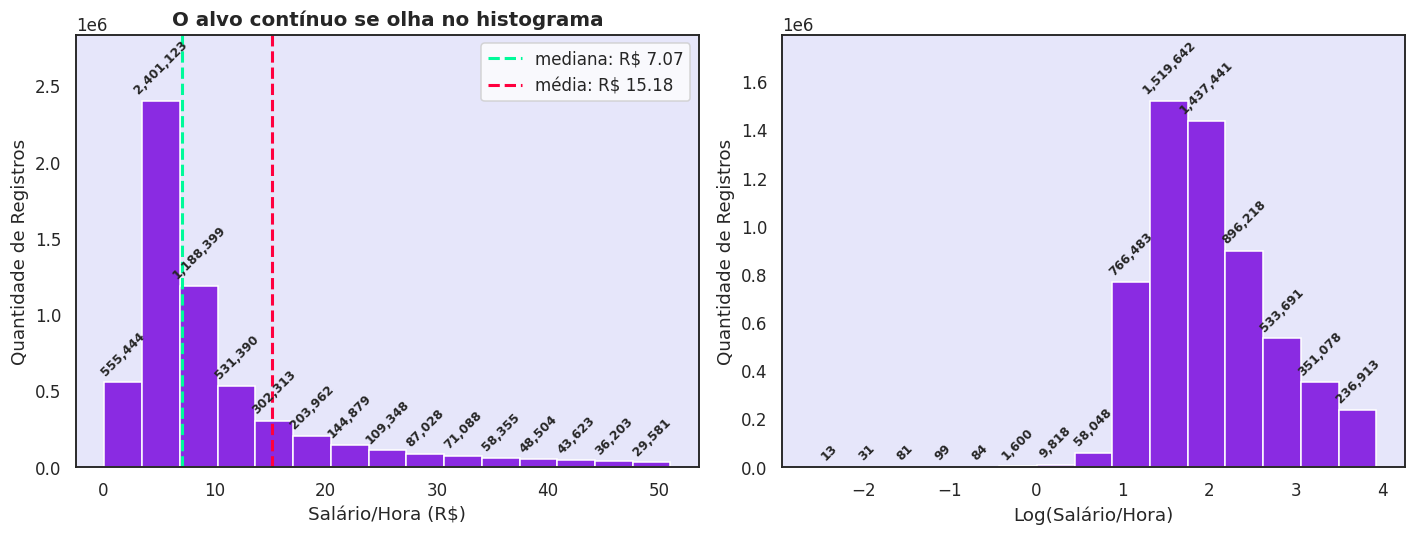

In [25]:
# ═══════════════════════════════════════════════════════════════════════════════
# O alvo é um NÚMERO CONTÍNUO. A lente certa é o HISTOGRAMA (value_counts não serve:
# cada salário é praticamente único).
limite_visual = df['salario_hora'].quantile(0.95)      # corta só PARA O GRÁFICO não ficar achatado
vis = df[df['salario_hora'] <= limite_visual]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax in axes:
    ax.set_facecolor('#E6E6FA')  # Cor interna do gráfico

n1, bins1, patches1 = axes[0].hist(vis['salario_hora'], bins=15, color=VIOLETA, edgecolor='white')
axes[0].axvline(df['salario_hora'].median(), color=VERDE, linestyle='--', linewidth=2,
                label=f"mediana: R$ {df['salario_hora'].median():.2f}")
axes[0].axvline(df['salario_hora'].mean(), color=SALMAO, linestyle='--', linewidth=2,
                label=f"média: R$ {df['salario_hora'].mean():.2f}")
axes[0].set_title('O alvo contínuo se olha no histograma')
axes[0].set_xlabel('Salário/Hora (R$)')
axes[0].set_ylabel('Quantidade de Registros')
axes[0].legend()

# Adiciona o valor em cima de cada coluna (Gráfico 1)
for count, bin_left, patch in zip(n1, bins1, patches1):
    if count > 0:
        height = patch.get_height()
        axes[0].annotate(f'{int(count):,}',
                         xy=(patch.get_x() + patch.get_width() / 2, height),
                         xytext=(0, 3), textcoords="offset points",
                         ha='center', va='bottom', fontsize=8, rotation=45, fontweight='bold')


n2, bins2, patches2 = axes[1].hist(np.log(vis['salario_hora']), bins=15, color=VIOLETA, edgecolor='white')
axes[1].set_xlabel('Log(Salário/Hora)')
axes[1].set_ylabel('Quantidade de Registros')

# Adiciona o valor em cima de cada coluna (Gráfico 2)
for count, bin_left, patch in zip(n2, bins2, patches2):
    if count > 0:
        height = patch.get_height()
        axes[1].annotate(f'{int(count):,}',
                         xy=(patch.get_x() + patch.get_width() / 2, height),
                         xytext=(0, 3), textcoords="offset points",
                         ha='center', va='bottom', fontsize=8, rotation=45, fontweight='bold')

# Ajusta o limite vertical para os rótulos não cortarem no topo
axes[0].set_ylim(0, max(n1) * 1.18)
axes[1].set_ylim(0, max(n2) * 1.18)

plt.tight_layout()
plt.show()

- **No gráfico da esquerda**, a **média está à direita da mediana**. Sempre que isso acontece, a distribuição tem **cauda longa à direita**: poucas pessoas ganhando muito puxam a média para cima. É por isso que este trabalho usa **mediana** em todas as análises descritivas, pois a média mentiria sobre "o salário típico".

- **No gráfico da direita**, o mesmo salário, depois de aplicar o **logaritmo**, vira quase um sino simétrico. O log **comprime a cauda**: a distância entre R\$ 10 e R\$ 20 (dobro) passa a valer o mesmo que entre R\$ 100 e R\$ 200 (também dobro). É exatamente assim que a desigualdade salarial funciona na vida real, em **proporção**, não em reais absolutos.

**É por isso que na Seção 5 o modelo vai prever `log(salario_hora)` e não `salario_hora`.** Pois escolhemos a escala em que o fenômeno realmente acontece. E é por isso, também, que toda métrica de erro vai ser reportada nas **duas escalas** e a Estação 5.4 explica isso com calma.

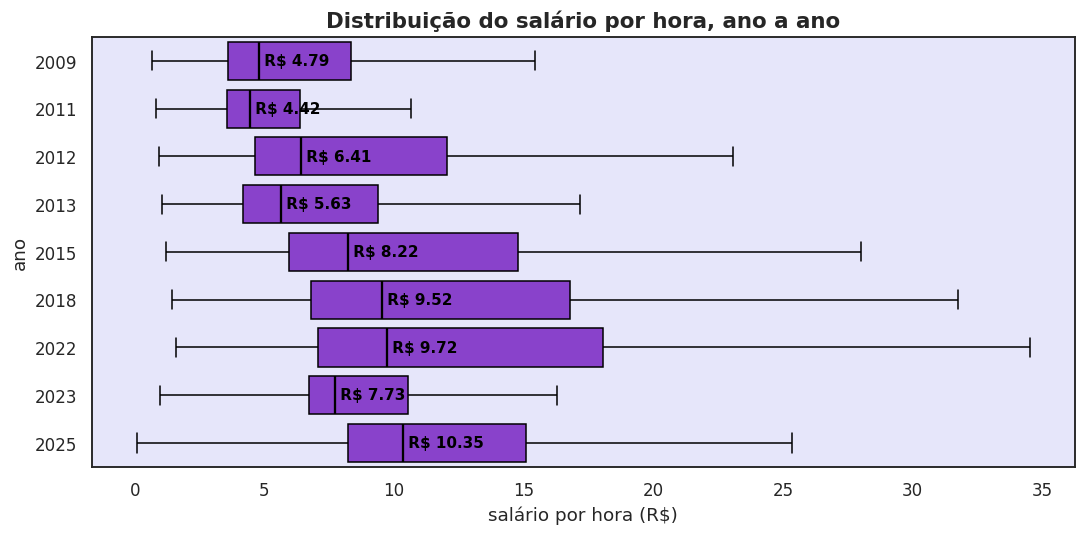


📖 Cada caixa é um ano. Ela cobre a metade do meio dos dados (do 1º ao 3º
   quartil) e o traço interno é a mediana. Caixas em posições diferentes ao
   longo dos anos indicam mudança de patamar salarial, inflação incluída.


In [32]:
if TEM_ANO:
    lim = df['salario_hora'].quantile(0.95)
    fig, ax = plt.subplots(figsize=(10, 5)) # Changed from plt.figure
    ax.set_facecolor('#E6E6FA')
    # A linha abaixo foi removida pois causava um TypeError e não se encaixava na lógica do gráfico subsequente.
    # axes[1].boxplot(['sal_mulher', 'sal_homem'], positions=[1, 2], widths=0.5, showfliers=False,
    #             patch_artist=True,
    #             boxprops=dict(facecolor=VIOLETA),  # Sem o alpha=0.6
    #             medianprops=dict(color='black', linewidth=2))
    sns.boxplot(
        data=df[df['salario_hora'] <= lim],
        x='salario_hora',
        y='ano',
        orient='h',
        color=VIOLETA,
        showfliers=False,
        ax=ax,
        boxprops=dict(edgecolor='black'),               # Borda da caixa em preto
        medianprops=dict(color='black', lw=1.5),        # Linha da mediana em preto
        whiskerprops=dict(color='black'),               # Linhas dos hastes (whiskers) em preto
        capprops=dict(color='black')                    # Traços das pontas em preto
    )
    medianas = df[df['salario_hora'] <= lim].groupby('ano')['salario_hora'].median()

    for i, (ano, valor_mediana) in enumerate(medianas.items()):
        ax.text(
            x=valor_mediana,
            y=i,
            s=f' R$ {valor_mediana:.2f}',
            verticalalignment='center',
            fontsize=10,
            fontweight='bold',
            color='black'
        )

    plt.title('Distribuição do salário por hora, ano a ano', fontsize=14, fontweight='bold')
    plt.xlabel('salário por hora (R$)'); plt.ylabel('ano')
    plt.tight_layout(); plt.show()
    print('\n📖 Cada caixa é um ano. Ela cobre a metade do meio dos dados (do 1º ao 3º')
    print('   quartil) e o traço interno é a mediana. Caixas em posições diferentes ao')
    print('   longo dos anos indicam mudança de patamar salarial, inflação incluída.')
else:
    print('Coluna "ano" ausente nesta base: o gráfico temporal foi pulado.')

### **Pergunta 4: a lista da faxina**

A EDA terminou. Ela **diagnosticou**; agora a Estação 3 **trata**. Os achados e as decisões:

| # | Achado da EDA | Decisão | Por quê |
|---|---|---|---|
| 1 | `horas_semanais = 99` é código, não jornada | **Remover as linhas** | Distorce o denominador do salário/hora |
| 2 | `horas_semanais > 44` foge da régua da CLT | **Remover as linhas** | O trabalho todo usa a jornada legal como referência |
| 3 | `vinculo` 99 e 999 são preenchimento inválido | **Remover as linhas** | Não correspondem a nenhum vínculo real |
| 4 | `vinculo = 80` é diretoria, sem limite de jornada | **Remover as linhas** | Fora da régua da CLT: vira trabalho futuro |
| 5 | `salario_hora` tem cauda extrema | **Cortar o 0,1% superior**, documentando | Poucos registros distorcem qualquer média |
| 6 | `raca_cor = 9` é "não informado" | **Manter como categoria própria** | É rótulo válido; imputar seria inventar dado |
| 7 | Códigos numéricos são ilegíveis | **Criar colunas `_rotulo`** | Regra fixa de dicionário: pode ser feita na base toda |

**O teste que decide QUANDO cada conserto pode acontecer:** *"esse conserto precisa CALCULAR um número a partir dos dados?"*
* **Não calcula** (regra fixa, dicionário de rótulos) → pode ser feito agora, na base toda.
* **Calcula** (mediana, média, escala) → o número seria **aprendido dos dados** e teria de esperar a separação treino/teste, dentro do Pipeline (Estação 5).

**A única exceção consciente aqui é o corte do 0,1%**, que usa um quantil, um número calculado da base. Fazemos isso na base toda porque este corte serve à **análise descritiva** (Estação 4) e é uma decisão editorial documentada, não um parâmetro que o modelo aprende.

---
# **Estação 3: a faxina (*data cleaning*)**

Nesta seção, vamos executar, uma a uma, as sete decisões da tabela acima, **contando quantas linhas cada regra remove**. Esse contador não é enfeite, é a prestação de contas do que foi descartado, e a banca costuma perguntar exatamente isso.

Os rótulos de **vínculo** (**`vinculo_rotulo`**) agora nascem **aqui dentro**, junto com os rótulos de gênero, raça e escolaridade.

A ordem é natural: **carregar → examinar → limpar → analisar**, de cima para baixo, sem pulos.

In [33]:
# ═══════════════════════════════════════════════════════════════════════════════
# A FAXINA, passo a passo e com contador de linhas
# ═══════════════════════════════════════════════════════════════════════════════
df_limpo = df.copy()
n_inicial = len(df_limpo)
print(f'Base bruta: {n_inicial:,} linhas\n')

def remover(dados, condicao_manter, descricao):
    """Aplica um filtro, informa quantas linhas saíram e devolve a base filtrada."""
    antes = len(dados)
    dados = dados[condicao_manter(dados)]
    saiu = antes - len(dados)
    print(f'  {descricao:<52} −{saiu:>8,} linhas ({saiu/n_inicial:5.1%})')
    return dados

print('REGRAS FIXAS (não calculam nada dos dados):')
df_limpo = remover(df_limpo, lambda d: d['horas_semanais'] != 99,
                   '(a) horas = 99 (código, não jornada)')
df_limpo = remover(df_limpo, lambda d: d['horas_semanais'] <= 44,
                   '(b) horas > 44 (acima do limite da CLT)')
df_limpo = remover(df_limpo, lambda d: ~d['vinculo'].isin(['99', '999']),
                   '(c) vínculo 99 e 999 (preenchimento inválido)')
# Antes de remover a diretoria, GUARDAMOS essas linhas: elas viram uma análise
# própria na Estação 4.7. Excluir da régua da CLT não é o mesmo que jogar fora.
df_diretoria = df_limpo[df_limpo['vinculo'] == '80'].copy()
df_limpo = remover(df_limpo, lambda d: d['vinculo'] != '80',
                   '(d) vínculo 80 (diretoria, guardado em df_diretoria)')
df_limpo = remover(df_limpo, lambda d: d['salario_hora'] > 0,
                   '(e) salário/hora zerado ou negativo (impossível)')

Base bruta: 6,117,095 linhas

REGRAS FIXAS (não calculam nada dos dados):
  (a) horas = 99 (código, não jornada)                 −   8,173 linhas ( 0.1%)
  (b) horas > 44 (acima do limite da CLT)              −  41,935 linhas ( 0.7%)
  (c) vínculo 99 e 999 (preenchimento inválido)        −      35 linhas ( 0.0%)
  (d) vínculo 80 (diretoria, guardado em df_diretoria) −   1,755 linhas ( 0.0%)
  (e) salário/hora zerado ou negativo (impossível)     −       0 linhas ( 0.0%)


In [34]:
# ═══════════════════════════════════════════════════════════════════════════════
# (f) RÓTULOS: dicionários oficiais da RAIS. Regra fixa: não aprende nada dos dados.
# ═══════════════════════════════════════════════════════════════════════════════
dic_genero = {'1': 'Masculino', '2': 'Feminino'}

dic_raca = {'1': 'Indígena', '2': 'Branca', '4': 'Preta',
            '6': 'Amarela', '8': 'Parda', '9': 'Não informado'}

dic_instrucao = {'1': 'Analfabeto', '2': 'Até 5º ano incompleto', '3': '5º ano completo',
                 '4': '6º ao 9º ano', '5': 'Fundamental completo', '6': 'Médio incompleto',
                 '7': 'Médio completo', '8': 'Superior incompleto', '9': 'Superior completo',
                 '10': 'Mestrado', '11': 'Doutorado'}

dic_vinculo = {'10': 'trabalhador urbano PJ CLT',   '15': 'trabalhador urbano PF CLT',
               '20': 'trabalhador rural PJ CLT',    '25': 'trabalhador rural PF CLT',
               '30': 'servidor público RJU/militar (RPPS)',
               '31': 'servidor público RJU/militar (RGPS)',
               '35': 'servidor público não efetivo', '40': 'trabalhador avulso',
               '50': 'trabalhador temporário',       '55': 'jovem aprendiz',
               '60': 'urbano PJ CLT prazo determinado',
               '65': 'urbano PF CLT prazo determinado',
               '70': 'rural PJ prazo determinado',   '75': 'rural PF prazo determinado',
               '80': 'diretor sem vínculo / dirigente sindical',
               '90': 'contrato por prazo determinado',
               '95': 'prazo determinado (adm. federal)',
               '96': 'prazo determinado (adm. estadual)',
               '97': 'prazo determinado (adm. municipal)'}

df_limpo['genero_rotulo']         = df_limpo['genero'].astype(str).map(dic_genero)
df_limpo['raca_cor_rotulo']       = df_limpo['raca_cor'].astype(str).map(dic_raca).fillna('Não informado')
df_limpo['grau_instrucao_rotulo'] = df_limpo['grau_instrucao'].astype(str).map(dic_instrucao)
df_limpo['vinculo_rotulo']        = df_limpo['vinculo'].astype(str).map(dic_vinculo).fillna('outro vínculo')

# A escolaridade tem ORDEM natural: informamos isso ao pandas para tabelas e gráficos
# saírem sempre na sequência pedagógica (e não em ordem alfabética).
ordem_escolaridade = ['Analfabeto', 'Até 5º ano incompleto', '5º ano completo', '6º ao 9º ano',
                      'Fundamental completo', 'Médio incompleto', 'Médio completo',
                      'Superior incompleto', 'Superior completo', 'Mestrado', 'Doutorado']
df_limpo['grau_instrucao_rotulo'] = pd.Categorical(df_limpo['grau_instrucao_rotulo'],
                                                   categories=ordem_escolaridade, ordered=True)

print('Rótulos criados. Conferência de sobras (o ideal é 0 em gênero e instrução):')
print(f"  gênero sem rótulo:      {df_limpo['genero_rotulo'].isna().sum():,}")
print(f"  instrução sem rótulo:   {df_limpo['grau_instrucao_rotulo'].isna().sum():,}")
print(f"  vínculo 'outro':        {(df_limpo['vinculo_rotulo'] == 'outro vínculo').sum():,}")

Rótulos criados. Conferência de sobras (o ideal é 0 em gênero e instrução):
  gênero sem rótulo:      0
  instrução sem rótulo:   0
  vínculo 'outro':        0


In [35]:
# ═══════════════════════════════════════════════════════════════════════════════
# (g) OUTLIERS: cortar o 0,1% superior do salário/hora (decisão documentada)
# ═══════════════════════════════════════════════════════════════════════════════
antes = len(df_limpo)
LIMITE_TOPO = df_limpo['salario_hora'].quantile(0.999)
df_limpo = df_limpo[df_limpo['salario_hora'] <= LIMITE_TOPO]
print(f'(g) outliers acima de R$ {LIMITE_TOPO:,.2f}/h removidos: {antes - len(df_limpo):,} linhas')

# ── Conferência final da faxina ───────────────────────────────────────────────
print(f'\nBase final: {len(df_limpo):,} linhas '
      f'({len(df_limpo)/n_inicial:.1%} da original, {n_inicial - len(df_limpo):,} removidas)')
print(f"Mediana do salário/hora depois da faxina: R$ {df_limpo['salario_hora'].median():.2f}")
print(f"(antes da faxina era R$ {df['salario_hora'].median():.2f}, "
      f'a diferença é o efeito do código 99 nas horas)')

# df_analise é o nome que usamos daqui pra frente. NÃO é uma cópia: é o mesmo objeto,
# com outro nome. Copiar duplicaria centenas de MB de RAM à toa: e RAM é justamente
# o que faltou da última vez.
df_analise = df_limpo

# Liberar a base bruta da memória: já extraímos tudo o que precisávamos dela.
del df
_ = gc.collect()
print(f'\nMemória do df_analise: {df_analise.memory_usage(deep=True).sum()/1024**2:.0f} MB')
print('Base bruta liberada da RAM (o del + gc.collect() acima).')

(g) outliers acima de R$ 483.43/h removidos: 6,066 linhas

Base final: 6,059,131 linhas (99.1% da original, 57,964 removidas)
Mediana do salário/hora depois da faxina: R$ 7.06
(antes da faxina era R$ 7.07, a diferença é o efeito do código 99 nas horas)

Memória do df_analise: 3559 MB
Base bruta liberada da RAM (o del + gc.collect() acima).


### **Decisões metodológicas da limpeza: escopo e limitações**

---



- **Tratamento de dados ausentes.** Não foram aplicadas técnicas de imputação (preenchimento por mediana ou moda). As colunas selecionadas não apresentaram valores nulos, porque a própria query já os excluiu. Além disso, em abordagens preditivas, qualquer imputação estatística deve ocorrer **depois** da separação treino/teste e **dentro do Pipeline**, para evitar vazamento de dados, é exatamente o que a Estação 5 faz.
- **Integração de tabelas (*merge*).** A junção entre a tabela de vínculos e a de estabelecimentos não foi realizada: as duas são amostras independentes, e a probabilidade de correspondência exata entre um vínculo e seu estabelecimento é estatisticamente insignificante, o que geraria ruído e viés.
- **Registros duplicados.** Não foram removidos. Como os microdados são anonimizados, dois registros idênticos representam observações **válidas de pessoas distintas** com o mesmo perfil sociodemográfico e ocupacional. Apagá-los destruiria informação real.
- **Corte de outliers.** O 0,1% superior foi removido por decisão editorial documentada, e o limite (**`LIMITE_TOPO`**) está impresso acima para que qualquer pessoa possa reproduzir ou contestar a escolha.

---
# **Estação 4: As Hipóteses (H1 a H6)**

A diferença entre **fuçar dados** e **fazer ciência** é escrever o que se espera encontrar **antes** de olhar.

Uma boa hipótese tem três pedaços: a **afirmação** (o que se espera), o **mecanismo** (por qual razão isso aconteceria no mundo real) e o **teste** (qual gráfico ou número confirma ou derruba as hipóteses).

| # | Hipótese | Por que ela é válida |
|---|----------|----------------------|
| **H1** | Mulheres ganham menos que homens **em todos os níveis de escolaridade** | É a pergunta central do TCC, e os dados respondem diretamente |
| **H2** | A qualificação **não diminui** o *gap* (teto de vidro) | Transforma o achado descritivo num padrão testável |
| **H3** | Gênero e raça se **acumulam**: mulheres pretas e pardas na base da pirâmide | Análise interseccional, agora com teste estatístico |
| **H4** | Em **TI**, mulheres são minoria e ainda assim ganham menos | O grupo se chama *Mulheres in Tech*: este é o recorte de casa |
| **H5** | O *gap* **não está diminuindo** após a Lei nº 14.611/2023 | Usa o *gap* em %, que é imune à inflação |
| **H6** | O *gap* geral "parece pequeno" porque as mulheres estudam mais (**paradoxo de composição**) | Explica por que o *gap* bruto e o *gap* por escolaridade contam histórias diferentes |

**As duas ferramentas de todas as hipóteses:**

- **A mediana** do salário/hora, e não a média, pelo motivo que o histograma da Estação 2 mostrou.
- **O teste de Mann-Whitney U**, que compara dois grupos **sem exigir que os dados tenham distribuição normal** (salário nunca tem). Junto dele vem o **tamanho de efeito**, e a razão disso é crucial: com centenas de milhares de linhas, *qualquer* diferença, por menor que seja, sai com p-valor minúsculo. O p-valor responde **"essa diferença é real ou é acaso?"**; o tamanho de efeito responde **"e ela é grande?"**.

In [36]:
# ═══════════════════════════════════════════════════════════════════════════════
# AS DUAS FERRAMENTAS DAS HIPÓTESES
# ═══════════════════════════════════════════════════════════════════════════════

def gap_pct(mediana_m, mediana_f):
    """Gap salarial: quantos % a mediana feminina está ABAIXO da masculina.
    Positivo = mulheres ganham menos."""
    return (mediana_m - mediana_f) / mediana_m * 100


def testar_grupos(dados, descricao, alpha=0.05):
    """Mann-Whitney U (testa se M > F) + tamanho de efeito (correlação rank-biserial).

    p-valor  : a diferença é real, ou poderia ser sorte do sorteio?
    rbc      : 0 = nenhuma separação entre os grupos; 1 = separação total.
               Referência usual: 0,10 pequeno · 0,30 médio · 0,50 grande.
    """
    m = dados.loc[dados['genero_rotulo'] == 'Masculino', 'salario_hora']
    f = dados.loc[dados['genero_rotulo'] == 'Feminino',  'salario_hora']
    if len(m) < 30 or len(f) < 30:
        print(f'{descricao}: amostra pequena demais (M={len(m)}, F={len(f)}), não testado')
        return None, None
    u, p = mannwhitneyu(m, f, alternative='greater')
    rbc = 1 - 2 * u / (len(m) * len(f))
    sig = 'significativo' if p < alpha else 'NÃO significativo'
    print(f'{descricao}: medianas M = R$ {m.median():6.2f} | F = R$ {f.median():6.2f} '
          f'| gap = {gap_pct(m.median(), f.median()):5.1f}% '
          f'| p = {p:.2e} ({sig}) | efeito rbc = {abs(rbc):.3f}')
    return p, rbc

print('Ferramentas prontas: gap_pct() e testar_grupos().')

Ferramentas prontas: gap_pct() e testar_grupos().


### **H1: O *Gap* Existe em Todos os Níveis de Escolaridade**

In [37]:
# ═══════════════════════════════════════════════════════════════════════════════
# Tabela: mediana do salário/hora por escolaridade e gênero
tab_h1 = (df_analise.groupby(['grau_instrucao_rotulo', 'genero_rotulo'], observed=True)['salario_hora']
          .median().unstack().round(2))
tab_h1['gap_%'] = gap_pct(tab_h1['Masculino'], tab_h1['Feminino']).round(1)
tab_h1['n_mulheres'] = (df_analise[df_analise.genero_rotulo == 'Feminino']
                        .groupby('grau_instrucao_rotulo', observed=True).size())
tab_h1

genero_rotulo,Feminino,Masculino,gap_%,n_mulheres
grau_instrucao_rotulo,,,,
Analfabeto,4.37,5.82,24.9,3073
Até 5º ano incompleto,4.35,6.04,28.0,34830
5º ano completo,4.19,5.81,27.9,52143
6º ao 9º ano,4.11,5.58,26.3,115970
Fundamental completo,4.37,5.87,25.6,202121
Médio incompleto,4.38,5.58,21.5,160408
Médio completo,5.83,7.30,20.1,1248949
Superior incompleto,7.83,10.08,22.3,142404
Superior completo,19.57,28.31,30.9,629565


In [38]:
# ═══════════════════════════════════════════════════════════════════════════════
# Teste estatístico nível a nível (só onde a amostra comporta)
print('Mann-Whitney U por nível de escolaridade:\n')
for nivel in ordem_escolaridade:
    sub = df_analise[df_analise['grau_instrucao_rotulo'] == nivel]
    if len(sub) > 500:
        testar_grupos(sub, f'{nivel:<24}')

Mann-Whitney U por nível de escolaridade:

Analfabeto              : medianas M = R$   5.82 | F = R$   4.37 | gap =  24.9% | p = 1.50e-97 (significativo) | efeito rbc = 0.244
Até 5º ano incompleto   : medianas M = R$   6.04 | F = R$   4.35 | gap =  28.0% | p = 0.00e+00 (significativo) | efeito rbc = 0.351
5º ano completo         : medianas M = R$   5.81 | F = R$   4.19 | gap =  27.8% | p = 0.00e+00 (significativo) | efeito rbc = 0.367
6º ao 9º ano            : medianas M = R$   5.58 | F = R$   4.11 | gap =  26.3% | p = 0.00e+00 (significativo) | efeito rbc = 0.342
Fundamental completo    : medianas M = R$   5.87 | F = R$   4.37 | gap =  25.6% | p = 0.00e+00 (significativo) | efeito rbc = 0.317
Médio incompleto        : medianas M = R$   5.58 | F = R$   4.38 | gap =  21.4% | p = 0.00e+00 (significativo) | efeito rbc = 0.244
Médio completo          : medianas M = R$   7.30 | F = R$   5.83 | gap =  20.1% | p = 0.00e+00 (significativo) | efeito rbc = 0.210
Superior incompleto     : mediana

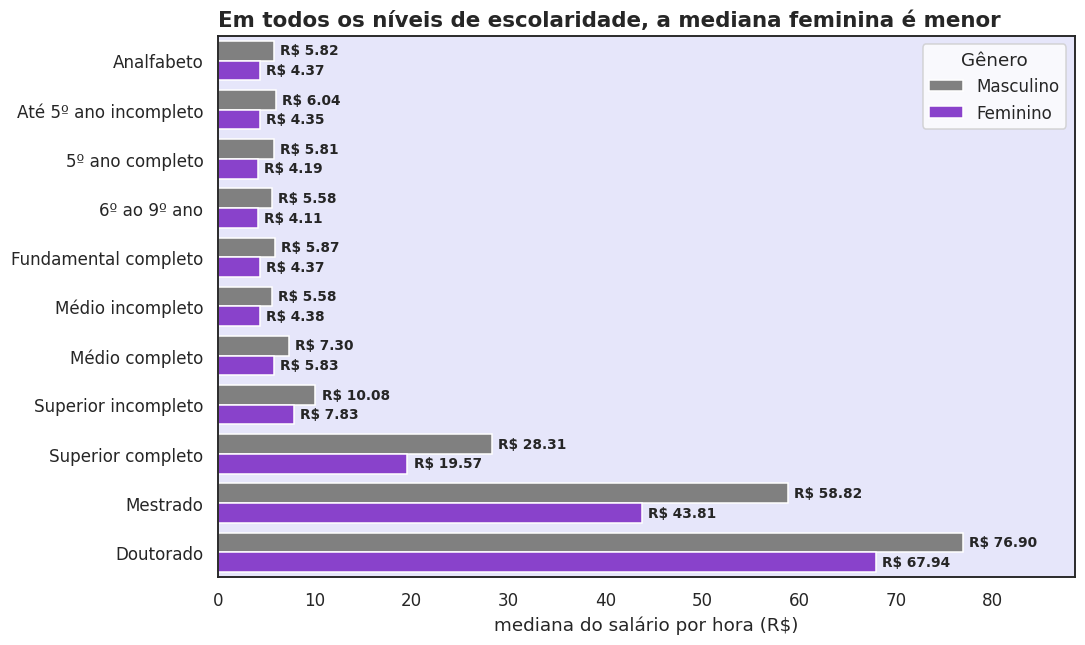

In [40]:
# ═══════════════════════════════════════════════════════════════════════════════
# O gráfico de H1
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor('#E6E6FA')
plot_df = (tab_h1.reset_index()
           .melt(id_vars=['grau_instrucao_rotulo'], value_vars=['Masculino', 'Feminino'],
                 var_name='Gênero', value_name='Mediana R$ por hora'))

sns.barplot(
    data=plot_df,
    y='grau_instrucao_rotulo',
    x='Mediana R$ por hora',
    hue='Gênero', hue_order=['Masculino', 'Feminino'],
    palette=PALETA,
    ax=ax
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='R$ %.2f',           # Formatação em Reais
        padding=4,               # Distância entre a barra e o texto
        fontsize=9,
        fontweight='bold'
    )

ax.set_title('Em todos os níveis de escolaridade, a mediana feminina é menor',
             fontsize=14, fontweight='bold', loc='left')
ax.set_ylabel('')
ax.set_xlabel('mediana do salário por hora (R$)')

# Ajusta a largura para que os rótulos do final das barras não cortem na imagem
ax.set_xlim(0, plot_df['Mediana R$ por hora'].max() * 1.15)

plt.tight_layout()
plt.show()

As barras roxas ficam **sistematicamente à esquerda** das cinzas, em todos os níveis, sem exceção.

E o teste confirma: a diferença é estatisticamente significativa em todos os estratos com amostra representativa.

**A ressalva honesta:** com um **`n`** desta ordem de grandeza, mesmo diferenças pequenas produzem p-valores minúsculos. Por isso reportamos também o **tamanho de efeito** (**`rbc`**).

O efeito agregado é modesto, e a relevância do achado está justamente na **heterogeneidade entre subgrupos**, que H2 e H3 revelam.

### **H2: A Qualificação Não Diminui o *Gap* (Teto de Vidro)**

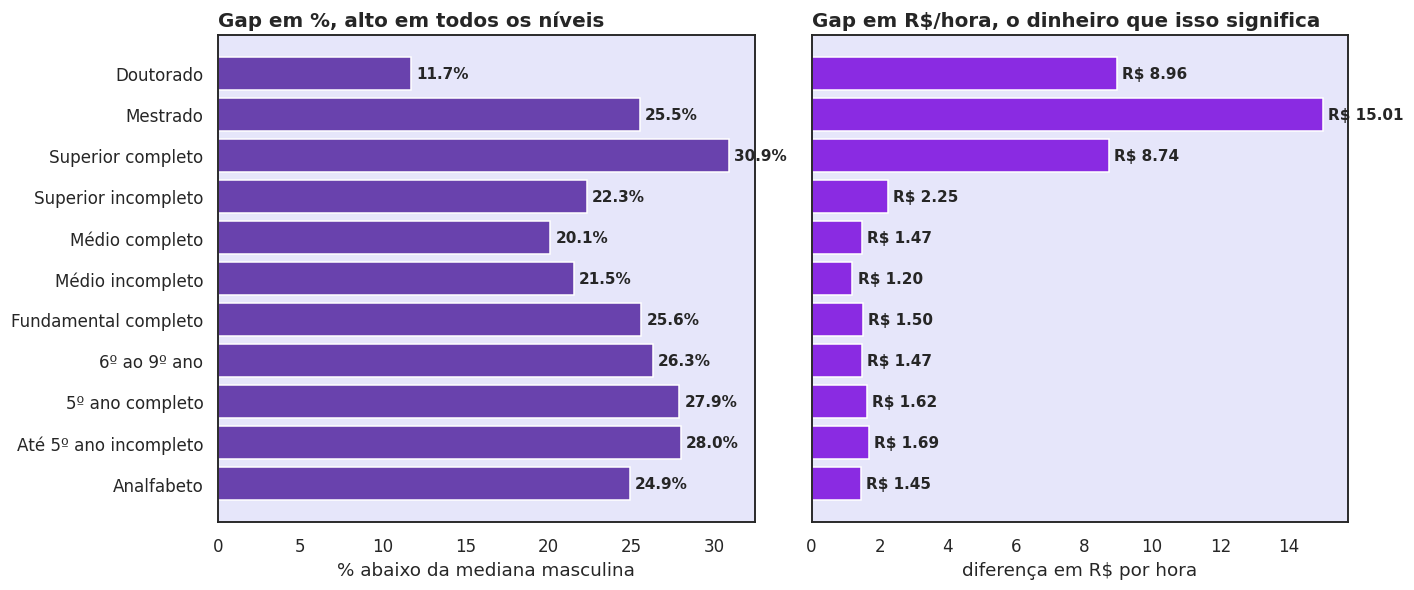


Gap em %, mínimo e máximo entre os níveis: 11.7% a 30.9%
Maior diferença ABSOLUTA (R$/h): Mestrado, R$ 15.01/h


In [41]:
# ═══════════════════════════════════════════════════════════════════════════════
# Duas lentes sobre o mesmo fato: o gap em % e o gap em R$
tab_h2 = tab_h1.copy()
tab_h2['dif_R$'] = (tab_h2['Masculino'] - tab_h2['Feminino']).round(2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)

for ax in axes:
    ax.set_facecolor('#E6E6FA')

axes[0].barh(tab_h2.index.astype(str), tab_h2['gap_%'], color=ROXO)
axes[0].set_title('Gap em %, alto em todos os níveis', fontsize=13, fontweight='bold', loc='left')
axes[0].set_xlabel('% abaixo da mediana masculina')
for i, v in enumerate(tab_h2['gap_%']):
    if pd.notna(v):
        axes[0].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=10, fontweight='bold')

axes[1].barh(tab_h2.index.astype(str), tab_h2['dif_R$'], color=VIOLETA)
axes[1].set_title('Gap em R$/hora, o dinheiro que isso significa',
                  fontsize=13, fontweight='bold', loc='left')
axes[1].set_xlabel('diferença em R$ por hora')
for i, v in enumerate(tab_h2['dif_R$']):
    if pd.notna(v):
        axes[1].text(v + 0.15, i, f'R$ {v:.2f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout(); plt.show()

print('\nGap em %, mínimo e máximo entre os níveis: '
      f"{tab_h2['gap_%'].min():.1f}% a {tab_h2['gap_%'].max():.1f}%")
print('Maior diferença ABSOLUTA (R$/h):',
      f"{tab_h2['dif_R$'].idxmax()}, R$ {tab_h2['dif_R$'].max():.2f}/h")

Os dois gráficos contam a mesma história em duas moedas, e as duas são necessárias.

- **O gap em %** responde: a desigualdade **encolhe** conforme a escolaridade sobe? Se a qualificação fosse a solução, essa barra diminuiria da base para o topo.
- **O gap em R\$** responde: **quanto dinheiro** isso significa. Uma diferença percentual parecida vale muito mais no topo da escala. Se multiplicarmos a maior diferença por 220 horas mensais: é esse o número mensal da disparidade.

A célula abaixo lê o padrão sozinha e escreve a conclusão, para que o texto do TCC nunca fique desatualizado em relação aos dados.

In [42]:
# ═══════════════════════════════════════════════════════════════════════════════
# LEITURA AUTOMÁTICA DE H2: o texto sai dos dados, não da nossa expectativa
# ═══════════════════════════════════════════════════════════════════════════════
t = tab_h2.dropna(subset=['gap_%']).copy()

nivel_max_pct = t['gap_%'].idxmax(); nivel_min_pct = t['gap_%'].idxmin()
nivel_max_reais = t['dif_R$'].idxmax()

print('O QUE OS DADOS DIZEM SOBRE H2\n' + '=' * 62)
print(f"Maior gap em %:      {nivel_max_pct} ({t.loc[nivel_max_pct,'gap_%']:.1f}%)")
print(f"Menor gap em %:      {nivel_min_pct} ({t.loc[nivel_min_pct,'gap_%']:.1f}%)")
print(f"Maior gap em R$/h:   {nivel_max_reais} (R$ {t.loc[nivel_max_reais,'dif_R$']:.2f}/h"
      f"  =  R$ {t.loc[nivel_max_reais,'dif_R$']*220:,.2f}/mês em 220h)")

# a escolaridade tem ordem: dá para comparar a base e o topo da escada
niveis = [n for n in ordem_escolaridade if n in t.index]
base_escada, topo_escada = niveis[0], niveis[-1]
print(f"\nDa base ao topo da escada: {base_escada} = {t.loc[base_escada,'gap_%']:.1f}%"
      f"  →  {topo_escada} = {t.loc[topo_escada,'gap_%']:.1f}%")

# a qualificação resolve? o teste é se o gap some no topo
if t['gap_%'].min() > 5:
    print('\n✅ H2 CONFIRMADA: o gap é relevante em TODOS os níveis de escolaridade.')
    print('   A qualificação não elimina a desigualdade: ela acompanha a mulher escada acima.')
else:
    print('\n⚠️  Há pelo menos um nível com gap quase nulo. Vale investigar o n desse nível.')

# o gap cresce, cai ou oscila com a escolaridade?
correlacao_escada = pd.Series(range(len(niveis)), index=niveis).corr(t.loc[niveis, 'gap_%'])
if abs(correlacao_escada) < 0.3:
    forma = 'NÃO é linear: o gap oscila ao longo da escada, sem crescer nem cair de forma consistente'
elif correlacao_escada > 0:
    forma = 'CRESCE com a escolaridade (o teto de vidro clássico)'
else:
    forma = 'DIMINUI conforme a escolaridade sobe'
print(f'\nFormato da relação (correlação escada x gap = {correlacao_escada:+.2f}):')
print(f'   o gap {forma}.')

print('\n📌 Para o TCC: descrevam o padrão que a saída acima mostra, não o que')
print('   se esperava encontrar. Um padrão inesperado bem explicado vale mais')
print('   que um padrão esperado que os dados não sustentam.')

if t.loc[nivel_min_pct, 'n_mulheres'] < t['n_mulheres'].median():
    print(f"\n⚠️  Cuidado: '{nivel_min_pct}' (o menor gap) tem apenas "
          f"{int(t.loc[nivel_min_pct,'n_mulheres']):,} mulheres, abaixo da mediana dos níveis.")
    print('   Estimativas em células pequenas oscilam muito. Reportem o n junto do número.')

O QUE OS DADOS DIZEM SOBRE H2
Maior gap em %:      Superior completo (30.9%)
Menor gap em %:      Doutorado (11.7%)
Maior gap em R$/h:   Mestrado (R$ 15.01/h  =  R$ 3,302.20/mês em 220h)

Da base ao topo da escada: Analfabeto = 24.9%  →  Doutorado = 11.7%

✅ H2 CONFIRMADA: o gap é relevante em TODOS os níveis de escolaridade.
   A qualificação não elimina a desigualdade: ela acompanha a mulher escada acima.

Formato da relação (correlação escada x gap = -0.47):
   o gap DIMINUI conforme a escolaridade sobe.

📌 Para o TCC: descrevam o padrão que a saída acima mostra, não o que
   se esperava encontrar. Um padrão inesperado bem explicado vale mais
   que um padrão esperado que os dados não sustentam.

⚠️  Cuidado: 'Doutorado' (o menor gap) tem apenas 5,575 mulheres, abaixo da mediana dos níveis.
   Estimativas em células pequenas oscilam muito. Reportem o n junto do número.


### **H3: Gênero e Raça se Acumulam**

In [43]:
# ═══════════════════════════════════════════════════════════════════════════════
tab_h3 = (df_analise.groupby(['raca_cor_rotulo', 'genero_rotulo'], observed=True)['salario_hora']
          .median().unstack().round(2))
tab_h3['gap_%']   = gap_pct(tab_h3['Masculino'], tab_h3['Feminino']).round(1)
tab_h3['n_total'] = df_analise.groupby('raca_cor_rotulo', observed=True).size()
tab_h3.sort_values('Feminino')

genero_rotulo,Feminino,Masculino,gap_%,n_total
raca_cor_rotulo,,,,
Branca,5.66,6.61,14.4,3038458
Preta,6.24,7.06,11.6,366422
Indígena,6.62,6.93,4.5,13293
Parda,6.84,7.55,9.4,1653310
Amarela,9.32,9.90,5.9,40196
Não informado,11.58,11.15,-3.9,947452


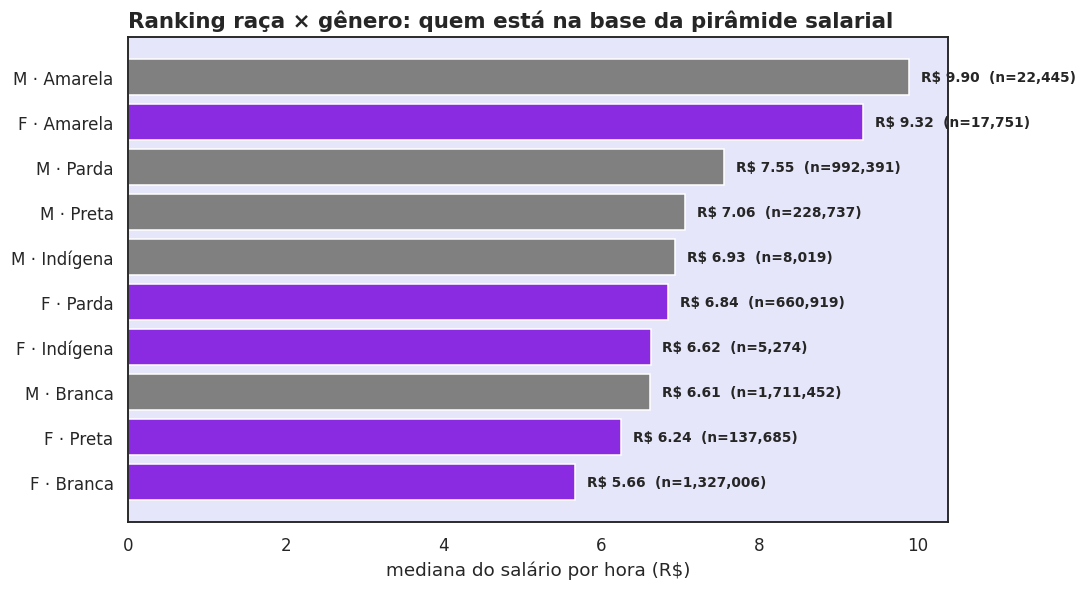


Teste dentro de cada grupo racial:

Branca      : medianas M = R$   6.61 | F = R$   5.66 | gap =  14.4% | p = 0.00e+00 (significativo) | efeito rbc = 0.111
Parda       : medianas M = R$   7.55 | F = R$   6.84 | gap =   9.4% | p = 0.00e+00 (significativo) | efeito rbc = 0.102
Preta       : medianas M = R$   7.06 | F = R$   6.24 | gap =  11.6% | p = 0.00e+00 (significativo) | efeito rbc = 0.109
Amarela     : medianas M = R$   9.90 | F = R$   9.32 | gap =   5.8% | p = 2.60e-15 (significativo) | efeito rbc = 0.045
Indígena    : medianas M = R$   6.93 | F = R$   6.62 | gap =   4.5% | p = 5.12e-05 (significativo) | efeito rbc = 0.040


In [45]:
# ═══════════════════════════════════════════════════════════════════════════════
# Ranking único: todas as combinações raça x gênero, da MENOR para a MAIOR mediana.
# Ver as 10 barras numa fila só é o que torna a interseccionalidade visível.
comb = (df_analise.groupby(['raca_cor_rotulo', 'genero_rotulo'], observed=True)['salario_hora']
        .agg(mediana='median', n='size').reset_index())
comb = comb[comb['raca_cor_rotulo'].isin(['Branca', 'Preta', 'Parda', 'Indígena', 'Amarela'])]
comb['grupo'] = comb['genero_rotulo'].str[0] + ' · ' + comb['raca_cor_rotulo']
comb = comb.sort_values('mediana')

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.set_facecolor('#E6E6FA')
cores = [VIOLETA if g.startswith('F') else CINZA for g in comb['grupo']]
ax.barh(comb['grupo'], comb['mediana'], color=cores, edgecolor='white')
for i, (v, n) in enumerate(zip(comb['mediana'], comb['n'])):
    ax.text(v + 0.15, i, f'R$ {v:.2f}  (n={n:,})', va='center', fontsize=9, fontweight='bold')
ax.set_title('Ranking raça × gênero: quem está na base da pirâmide salarial',
             fontsize=14, fontweight='bold', loc='left')
ax.set_xlabel('mediana do salário por hora (R$)')
plt.tight_layout(); plt.show()

print('\nTeste dentro de cada grupo racial:\n')
for r in ['Branca', 'Parda', 'Preta', 'Amarela', 'Indígena']:
    sub = df_analise[df_analise['raca_cor_rotulo'] == r]
    testar_grupos(sub, f'{r:<12}')

O ranking mostra o que uma média geral esconderia. As desvantagens **não se substituem, se somam**: ser mulher tem um custo, e esse custo é diferente conforme a raça.

**Cautelas obrigatórias no texto:**
1. A categoria **"Não informado"** ficou fora do ranking, ela é ausência de registro administrativo, não um grupo social. Compará-la com os demais seria comparar uma lacuna com pessoas.
2. Onde o **`n`** é pequeno (repare nos números entre parênteses), a estimativa **oscila muito**.
3. **Se a categoria "Não informado" aparecer com gap NEGATIVO** (mulheres ganhando mais), isso não é um achado social: é um artefato de quem deixa o campo em branco. A não declaração de raça/cor é mais comum em certos setores e faixas salariais, então esse grupo não é uma população, é um padrão de preenchimento. Mais um motivo para mantê-lo fora das comparações diretas, e mais uma frase pronta para as limitações.

### **H4: Mulheres em TI: Minoria, e Ainda Assim com *Gap***

In [46]:
# ═══════════════════════════════════════════════════════════════════════════════
# O recorte de TI pela CBO (Classificação Brasileira de Ocupações, 2002).
# Escolhemos filtrar por OCUPAÇÃO (o que a pessoa faz) e não por setor da empresa:
# assim entram as profissionais de TI que trabalham em bancos, varejo, indústria :
# ou seja, o corpo técnico inteiro, não só quem está numa "empresa de tecnologia".
prefixos_cbo = ['1237',   # gerentes de TI
                '1425',   # gerentes de operações de TI
                '2112',   # matemáticos, estatísticos
                '2122',   # engenheiros e afins de computação
                '2123',   # administradores de TI / redes
                '2124',   # analistas de sistemas
                '3171',   # técnicos de desenvolvimento de sistemas
                '3172']   # técnicos em operação e monitoramento

padrao = r'^(' + '|'.join(prefixos_cbo) + r')'
df_ti = df_analise[df_analise['ocupacao'].astype(str).str.strip().str.match(padrao, na=False)]

print(f'Vínculos em ocupações de TI: {len(df_ti):,} '
      f'({len(df_ti)/len(df_analise):.1%} da base)')
print('\nParticipação por gênero em TI:')
print((df_ti['genero_rotulo'].value_counts(normalize=True) * 100).round(1).to_string())
print('\nParticipação por gênero no mercado geral (para comparar):')
print((df_analise['genero_rotulo'].value_counts(normalize=True) * 100).round(1).to_string())

Vínculos em ocupações de TI: 85,908 (1.4% da base)

Participação por gênero em TI:
genero_rotulo
Masculino    78.5
Feminino     21.5

Participação por gênero no mercado geral (para comparar):
genero_rotulo
Masculino    56.9
Feminino     43.1


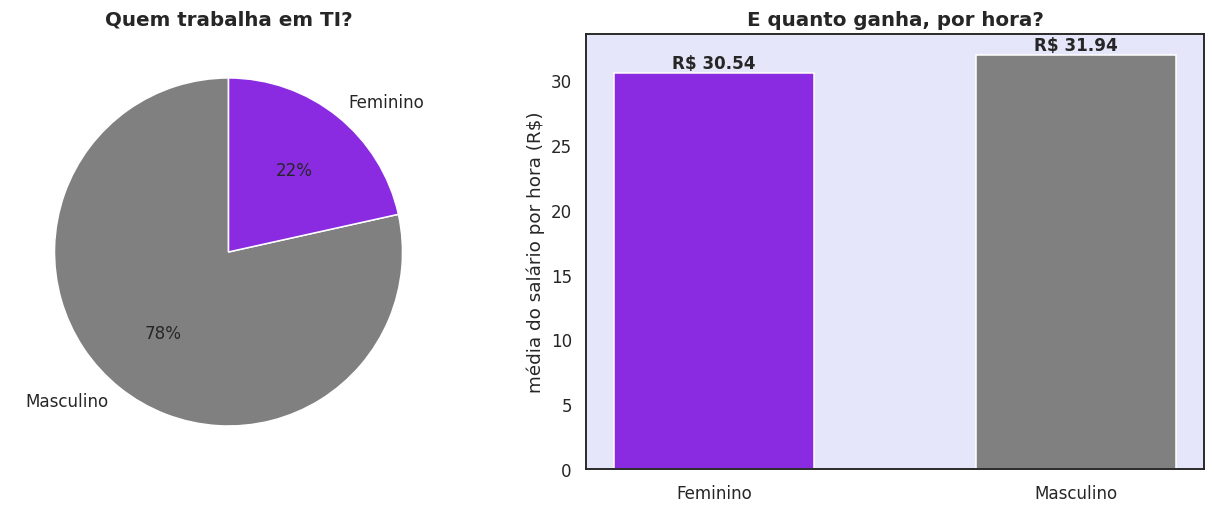



📊 --- TI (todas as escolaridades) (MÉDIAS) ---
   Média Masculino: R$ 31.94/h
   Média Feminino:  R$ 30.54/h
   Gap na Média:    4.38% a menos para mulheres

📊 --- TI (superior completo ou mais) (MÉDIAS) ---
   Média Masculino: R$ 41.15/h
   Média Feminino:  R$ 37.69/h
   Gap na Média:    8.41% a menos para mulheres


In [48]:
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

for ax in axes:
    ax.set_facecolor('#E6E6FA')

part = df_ti['genero_rotulo'].value_counts()
axes[0].pie(part, labels=part.index, autopct='%1.0f%%',
            colors=[PALETA[g] for g in part.index], startangle=90,
            textprops={'fontsize': 11})
axes[0].set_title('Quem trabalha em TI?', fontsize=13, fontweight='bold')

med_ti = df_ti.groupby('genero_rotulo', observed=True)['salario_hora'].mean()
axes[1].bar(med_ti.index, med_ti.values, color=[PALETA[g] for g in med_ti.index],
            edgecolor='white', width=0.55)
for i, v in enumerate(med_ti.values):
    axes[1].text(i, v + 0.4, f'R$ {v:.2f}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('E quanto ganha, por hora?', fontsize=13, fontweight='bold')
axes[1].set_ylabel('média do salário por hora (R$)')

plt.tight_layout(); plt.show()

def testar_grupos_media(df_subgrupo, nome_grupo):
    """Calcula a média salarial por gênero e o gap percentual para o grupo informado."""
    media_g = df_subgrupo.groupby('genero_rotulo', observed=True)['salario_hora'].mean()
    m_h = media_g.get('Masculino', 0)
    m_m = media_g.get('Feminino', 0)
    gap = ((m_h - m_m) / m_h) * 100 if m_h > 0 else 0

    print(f"\n📊 --- {nome_grupo} (MÉDIAS) ---")
    print(f"   Média Masculino: R$ {m_h:.2f}/h")
    print(f"   Média Feminino:  R$ {m_m:.2f}/h")
    print(f"   Gap na Média:    {gap:.2f}% a menos para mulheres")

print()
testar_grupos_media(df_ti, 'TI (todas as escolaridades)')

ti_sup = df_ti[df_ti['grau_instrucao_rotulo'].isin(['Superior completo', 'Mestrado', 'Doutorado'])]
testar_grupos_media(ti_sup, 'TI (superior completo ou mais)')

1. **Quantas mulheres estão em TI?**

Apenas 22% (aproximadamente 1 em cada 5 pessoas) do mercado de TI é ocupado por mulheres.


2. **As mulheres em TI ganham menos?**

**O gap em TI no recorte amplo pode ser bem menor que o gap do mercado geral, e AINDA ASSIM crescer quando se olha só quem tem ensino superior.**

In [49]:
# ═══════════════════════════════════════════════════════════════════════════════
# LEITURA AUTOMÁTICA DE H4
# ═══════════════════════════════════════════════════════════════════════════════
part_ti  = (df_ti.genero_rotulo == 'Feminino').mean() * 100
part_ger = (df_analise.genero_rotulo == 'Feminino').mean() * 100

def gap_de(dados):
    m = dados.loc[dados.genero_rotulo == 'Masculino', 'salario_hora'].median()
    f = dados.loc[dados.genero_rotulo == 'Feminino',  'salario_hora'].median()
    return gap_pct(m, f)

gap_ti_todos = gap_de(df_ti)
gap_ti_sup   = gap_de(ti_sup)
gap_geral    = gap_de(df_analise)

print('O QUE OS DADOS DIZEM SOBRE H4\n' + '=' * 62)
print(f'Participação feminina em TI:        {part_ti:5.1f}%')
print(f'Participação feminina no mercado:   {part_ger:5.1f}%')
print(f'   → em TI as mulheres são {part_ger/part_ti:.1f}x menos presentes que no mercado geral\n')
print(f'Gap salarial no mercado geral:      {gap_geral:5.1f}%')
print(f'Gap salarial em TI (todo o recorte):{gap_ti_todos:5.1f}%')
print(f'Gap salarial em TI (superior ou +):  {gap_ti_sup:5.1f}%')

print('\nLEITURA:')
if part_ti < part_ger - 5:
    print(f'  • SUB-REPRESENTAÇÃO confirmada: TI tem participação feminina bem abaixo do mercado.')
if gap_ti_sup > gap_ti_todos + 2:
    print('  • O gap em TI CRESCE entre quem tem ensino superior. Isso desmonta o argumento')
    print('    de que "elas ganham menos porque estão em cargos menos qualificados":')
    print('    comparando só quem tem diploma, a diferença aumenta em vez de sumir.')
    print('    Hipótese para o texto: nos níveis iniciais e técnicos as faixas salariais são')
    print('    mais padronizadas; a desigualdade aparece onde entra negociação e promoção.')
elif gap_ti_todos > gap_ti_sup + 2:
    print('  • O gap em TI DIMINUI entre quem tem ensino superior: a formação alta reduz,')
    print('    mas não elimina, a diferença dentro do setor.')
else:
    print('  • O gap em TI é parecido nos dois recortes: a diferença não vem da escolaridade.')

if gap_ti_todos < gap_geral - 3:
    print(f'  • O gap bruto de TI ({gap_ti_todos:.1f}%) é MENOR que o do mercado ({gap_geral:.1f}%).')
    print('    Não escrevam isso como "em TI é pior". Escrevam o que é: em TI a desigualdade')
    print('    salarial bruta é menor, e o problema principal do setor é a AUSÊNCIA de mulheres.')
    print('    São dois problemas diferentes, e o trabalho mede os dois.')

O QUE OS DADOS DIZEM SOBRE H4
Participação feminina em TI:         21.5%
Participação feminina no mercado:    43.1%
   → em TI as mulheres são 2.0x menos presentes que no mercado geral

Gap salarial no mercado geral:        9.4%
Gap salarial em TI (todo o recorte):  2.1%
Gap salarial em TI (superior ou +):    9.1%

LEITURA:
  • SUB-REPRESENTAÇÃO confirmada: TI tem participação feminina bem abaixo do mercado.
  • O gap em TI CRESCE entre quem tem ensino superior. Isso desmonta o argumento
    de que "elas ganham menos porque estão em cargos menos qualificados":
    comparando só quem tem diploma, a diferença aumenta em vez de sumir.
    Hipótese para o texto: nos níveis iniciais e técnicos as faixas salariais são
    mais padronizadas; a desigualdade aparece onde entra negociação e promoção.
  • O gap bruto de TI (2.1%) é MENOR que o do mercado (9.4%).
    Não escrevam isso como "em TI é pior". Escrevam o que é: em TI a desigualdade
    salarial bruta é menor, e o problema principal do 

**A escolha metodológica do recorte:** filtramos por **ocupação** (o código CBO do que a pessoa faz) e não por **setor da empresa** (CNAE).

Assim entram as profissionais de TI que trabalham em bancos, varejo e indústria, ou seja, o corpo técnico inteiro, e não apenas quem está numa "empresa de tecnologia". É o recorte que corresponde à pergunta do grupo.

### **H5: o *Gap* ao Longo do Tempo, e A Lei nº 14.611/2023**

**Duas particularidades da amostra:**

1. **Os anos não são contínuos.** O `TABLESAMPLE` sorteia linhas, não anos, então a amostra cobre alguns anos e pula outros. A célula abaixo mostra exatamente quais anos estão sendo analisados. Uma série com buracos **não é uma série temporal**: é um conjunto de fotografias em momentos diferentes, e conclusões sobre "tendência" precisam desse cuidado.
2. **O gap bruto por ano sofre do mesmo paradoxo de composição da H6.** Se a escolaridade média das mulheres subiu ao longo do período, o gap bruto cai **sem que a desigualdade tenha diminuído**. Por isso a célula seguinte calcula também o gap **controlado por escolaridade**, que é a comparação honesta.

In [50]:
# ═══════════════════════════════════════════════════════════════════════════════
# H5.1: o gap BRUTO ano a ano
# ═══════════════════════════════════════════════════════════════════════════════
if not TEM_ANO:
    print('Esta base não tem a coluna "ano": H5 não pode ser calculada aqui.')
    print('Na base completa da RAIS, com a coluna presente, esta célula roda normalmente.')
    anos_disponiveis = []
else:
    anos_disponiveis = sorted(df_analise['ano'].unique())
if anos_disponiveis:
    print(f'Anos presentes na amostra ({len(anos_disponiveis)}): {anos_disponiveis}')
    faltando = [a for a in range(min(anos_disponiveis), max(anos_disponiveis) + 1)
                if a not in anos_disponiveis]
    print(f'Anos do intervalo que NÃO estão na amostra ({len(faltando)}): {faltando}')
    print('→ Série com buracos: são fotografias, não uma linha do tempo contínua.\n')

    evolucao = (df_analise.groupby(['ano', 'genero_rotulo'], observed=True)['salario_hora']
                .median().unstack().round(2))
    evolucao['gap_%'] = gap_pct(evolucao['Masculino'], evolucao['Feminino']).round(1)
    evolucao['n'] = df_analise.groupby('ano', observed=True).size()
    print(evolucao.to_string())

Anos presentes na amostra (9): [np.int64(2009), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2015), np.int64(2018), np.int64(2022), np.int64(2023), np.int64(2025)]
Anos do intervalo que NÃO estão na amostra (8): [2010, 2014, 2016, 2017, 2019, 2020, 2021, 2024]
→ Série com buracos: são fotografias, não uma linha do tempo contínua.

genero_rotulo  Feminino  Masculino  gap_%        n
ano                                               
2009               4.38       5.23   16.3  1291466
2011               4.06       4.78   15.1   697888
2012               6.13       6.99   12.3   607514
2013               5.09       6.31   19.3  1286259
2015               8.09       9.12   11.3   498061
2018               9.56      10.73   10.9   430963
2022              12.17      12.51    2.7   557011
2023               7.59       8.19    7.3   142077
2025              10.28      11.07    7.1   547892


O gap bruto e o gap controlado por escolaridade, ano a ano:

      gap_bruto_%  gap_controlado_%
ano                                
2009         16.1              22.3
2011         15.1              19.0
2012         12.4              22.1
2013         19.3              27.0
2015         11.2              22.0
2018         10.9              23.1
2022          2.7              21.5
2023          7.3              11.7
2025          7.1               9.3


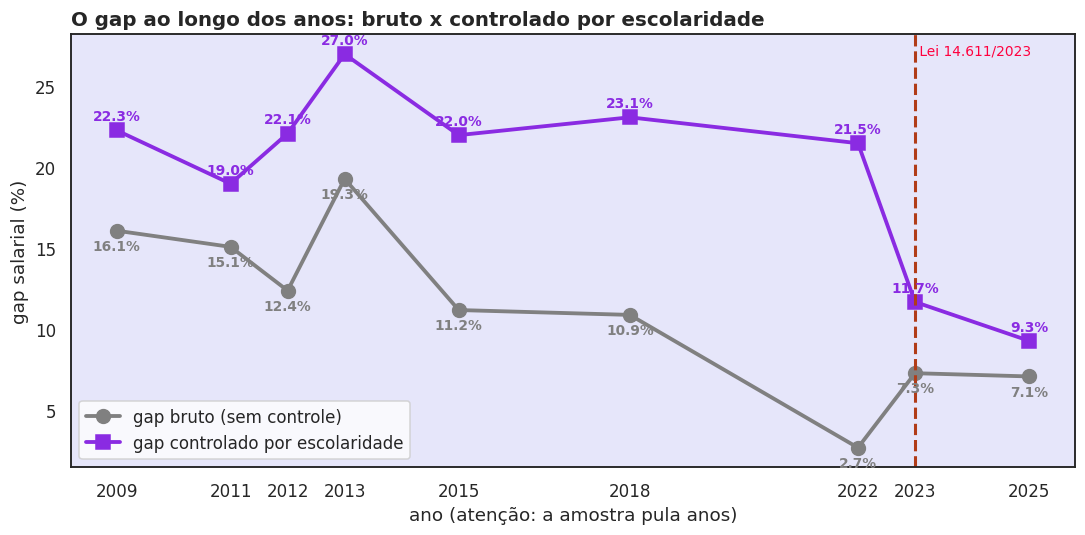


Do primeiro ao último ano da amostra (2009 a 2025):
  gap bruto:      16.1%  →  7.1%
  gap controlado: 22.3%  →  9.3%

Depois da lei ([2023, 2025]): gap controlado de 11.7% para 9.3%


In [58]:
# ═══════════════════════════════════════════════════════════════════════════════
# H5.2: o gap CONTROLADO por escolaridade, ano a ano
# A conta: dentro de cada ano, calculamos o gap DENTRO de cada nível de escolaridade
# e tiramos a média ponderada pelo número de mulheres. Assim, mudanças no perfil
# educacional da força de trabalho não contaminam a comparação entre anos.
# ═══════════════════════════════════════════════════════════════════════════════
if not anos_disponiveis:
    ctrl = pd.DataFrame(columns=['gap_bruto_%', 'gap_controlado_%'])
    print('Sem a coluna "ano", o gap controlado por ano não pode ser calculado.')
else:
    linhas_ctrl = []
    for ano in anos_disponiveis:
        sub = df_analise[df_analise['ano'] == ano]
        t = (sub.groupby(['grau_instrucao_rotulo', 'genero_rotulo'], observed=True)['salario_hora']
             .median().unstack())
        if 'Masculino' not in t.columns or 'Feminino' not in t.columns:
            continue
        t = t.dropna()
        pesos = (sub[sub.genero_rotulo == 'Feminino']
                 .groupby('grau_instrucao_rotulo', observed=True).size().reindex(t.index).fillna(0))
        if pesos.sum() == 0:
            continue
        gaps_nivel = gap_pct(t['Masculino'], t['Feminino'])
        linhas_ctrl.append({'ano': ano,
                            'gap_bruto_%': round(gap_pct(
                                sub.loc[sub.genero_rotulo == 'Masculino', 'salario_hora'].median(),
                                sub.loc[sub.genero_rotulo == 'Feminino', 'salario_hora'].median()), 1),
                            'gap_controlado_%': round(float(np.average(gaps_nivel, weights=pesos)), 1)})

    ctrl = pd.DataFrame(linhas_ctrl).set_index('ano')
    print('O gap bruto e o gap controlado por escolaridade, ano a ano:\n')
    print(ctrl.to_string())

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.set_facecolor('#E6E6FA')

    ax.plot(ctrl.index, ctrl['gap_bruto_%'], marker='o', linewidth=2.5, markersize=9,
            color=CINZA, label='gap bruto (sem controle)')
    ax.plot(ctrl.index, ctrl['gap_controlado_%'], marker='s', linewidth=2.5, markersize=9,
            color=VIOLETA, label='gap controlado por escolaridade')

    for x, v in zip(ctrl.index, ctrl['gap_controlado_%']):
        ax.text(x, v + 0.6, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold', color=VIOLETA)
    for x, v in zip(ctrl.index, ctrl['gap_bruto_%']):
        ax.text(x, v - 1.2, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold', color=CINZA)

    if 2023 in list(ctrl.index):
        ax.axvline(2023, color='#b13c18', linestyle='--', linewidth=2)
        ax.text(2023, ax.get_ylim()[1] * 0.98, ' Lei 14.611/2023', fontsize=9,
                color=SALMAO, va='top')
    ax.set_title('O gap ao longo dos anos: bruto x controlado por escolaridade',
                 fontsize=13, fontweight='bold', loc='left')
    ax.set_xlabel('ano (atenção: a amostra pula anos)'); ax.set_ylabel('gap salarial (%)')
    ax.set_xticks(list(ctrl.index)); ax.legend()
    plt.tight_layout(); plt.show()

    primeiro, ultimo = ctrl.index.min(), ctrl.index.max()
    print(f'\nDo primeiro ao último ano da amostra ({primeiro} a {ultimo}):')
    print(f"  gap bruto:      {ctrl.loc[primeiro,'gap_bruto_%']:.1f}%  →  {ctrl.loc[ultimo,'gap_bruto_%']:.1f}%")
    print(f"  gap controlado: {ctrl.loc[primeiro,'gap_controlado_%']:.1f}%  →  {ctrl.loc[ultimo,'gap_controlado_%']:.1f}%")
    pos_lei = [a for a in ctrl.index if a >= 2023]
    if len(pos_lei) >= 2:
        print(f'\nDepois da lei ({pos_lei}): gap controlado de '
              f"{ctrl.loc[pos_lei[0],'gap_controlado_%']:.1f}% para {ctrl.loc[pos_lei[-1],'gap_controlado_%']:.1f}%")
    elif len(pos_lei) == 1:
        print(f'\nSó UM ano depois da lei ({pos_lei[0]}) na amostra: impossível medir tendência pós-lei.')

**Por que o *gap* está em %, e não em reais:** se comparássemos a diferença **em R\$** ao longo dos anos, estaríamos medindo **inflação** misturada com desigualdade, e a curva subiria mesmo se nada mudasse. O *gap* percentual é uma razão entre dois valores do **mesmo ano**: a inflação aparece nos dois lados e se cancela.

- **A linha cinza (bruta)** tende a cair ao longo do período. Sozinha, ela sugeriria que a desigualdade diminuiu.
- **A linha violeta (controlada por escolaridade)** é a comparação justa, porque neutraliza a mudança no perfil educacional da força de trabalho ao longo do tempo. **Se a linha violeta cair bem menos que a cinza, boa parte da "melhora" aparente é composição, não equidade.** Esse é exatamente o mesmo mecanismo da H6, agora aplicado ao tempo.

**O que se pode e o que não se pode afirmar:**

| Pode afirmar | Não pode afirmar |
|---|---|
| Como o gap se comportou **nos anos presentes na amostra** | Que houve "tendência" contínua, porque a série tem buracos |
| Que o gap **persiste** em todos os anos observados | Que a Lei 14.611/2023 causou (ou deixou de causar) o que se vê |
| Que a leitura bruta e a controlada **contam histórias diferentes** | Qualquer projeção para anos futuros |

**Sobre a lei especificamente:** confiram, na saída da célula, **quantos anos posteriores a 2023** a amostra contém. Com um único ano depois da lei, não existe "depois" para comparar, e a resposta científica é: *o desenho amostral não permite avaliar o efeito da lei*. Dizer isso é mais forte do que forçar uma conclusão. Fica registrado como limitação e como sugestão de trabalho futuro: uma amostragem estratificada por ano resolveria.

### **H6: o Paradoxo da Composição**

Gap salarial BRUTO (base inteira, sem controlar nada): 9.4%
Gap DENTRO de cada escolaridade: de 11.7% a 30.9%

Como o gap dentro de cada nível é MAIOR que o gap geral? A resposta está abaixo.

Percentual com superior completo ou mais:
  Mulheres: 24.9%
  Homens:   14.3%


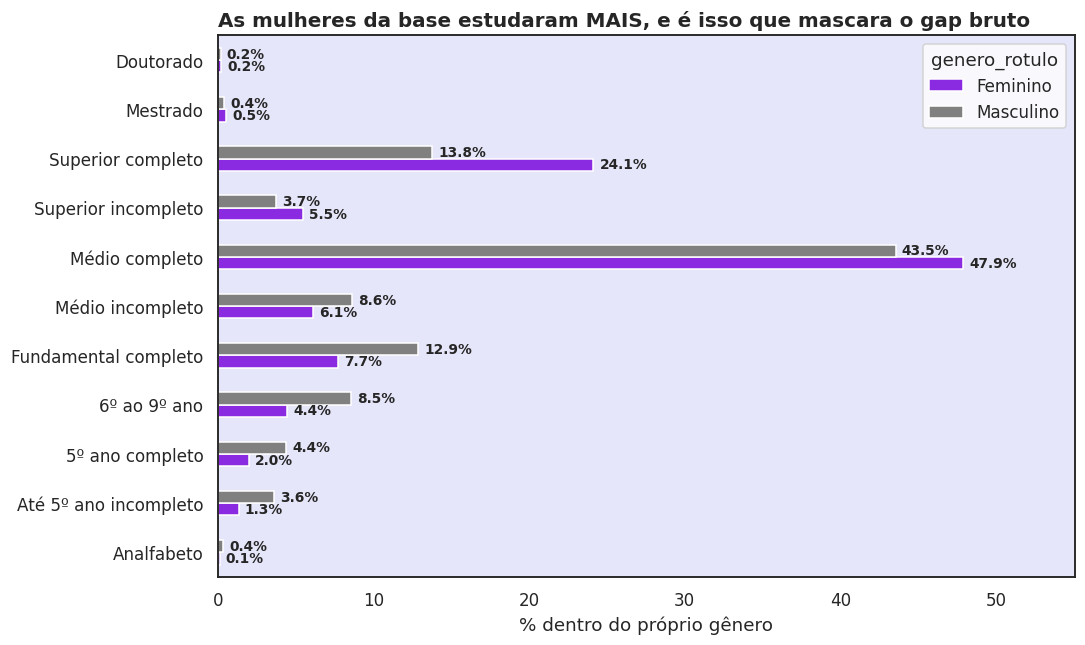

In [61]:
# ═══════════════════════════════════════════════════════════════════════════════
gap_bruto = gap_pct(
    df_analise.loc[df_analise.genero_rotulo == 'Masculino', 'salario_hora'].median(),
    df_analise.loc[df_analise.genero_rotulo == 'Feminino',  'salario_hora'].median())

print(f'Gap salarial BRUTO (base inteira, sem controlar nada): {gap_bruto:.1f}%')
print(f"Gap DENTRO de cada escolaridade: de {tab_h1['gap_%'].min():.1f}% a {tab_h1['gap_%'].max():.1f}%")
print('\nComo o gap dentro de cada nível é MAIOR que o gap geral? A resposta está abaixo.\n')

# A explicação: a distribuição de escolaridade é diferente entre os gêneros
escolaridade = pd.crosstab(df_analise['grau_instrucao_rotulo'],
                           df_analise['genero_rotulo'], normalize='columns') * 100
superior = ['Superior completo', 'Mestrado', 'Doutorado']
presentes = [n for n in superior if n in escolaridade.index]
print('Percentual com superior completo ou mais:')
print(f"  Mulheres: {escolaridade.loc[presentes, 'Feminino'].sum():.1f}%")
print(f"  Homens:   {escolaridade.loc[presentes, 'Masculino'].sum():.1f}%")

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor('#E6E6FA')

# Plota o gráfico mantendo o comando original
escolaridade.plot(kind='barh', color=[PALETA[c] for c in escolaridade.columns], ax=ax)

# Inclui os rótulos de percentual ao lado de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=4, fontsize=9, fontweight='bold')

ax.set_title('As mulheres da base estudaram MAIS, e é isso que mascara o gap bruto',
             fontsize=13, fontweight='bold', loc='left')
ax.set_xlabel('% dentro do próprio gênero')
ax.set_ylabel('')

# Expande o limite do eixo X para os valores da ponta não cortarem
ax.set_xlim(0, escolaridade.values.max() * 1.15)

plt.tight_layout()
plt.show()

**Este é o achado mais sofisticado do trabalho, e o mais fácil de explicar mal.**

Parece contradição: o *gap* dentro de **cada** nível de escolaridade é maior que o *gap* **geral**. Como?

Porque as mulheres da base estão **mais concentradas nos níveis altos de escolaridade**, e níveis altos pagam mais. Ao juntar tudo numa conta só, a vantagem educacional delas **compensa parcialmente** a desvantagem salarial, e o número geral sai menor do que a realidade de qualquer mulher individualmente.

**O indicador bruto subestima a desigualdade porque compara populações com composição educacional diferente; ao controlar por escolaridade, a disparidade não apenas persiste como se amplia nos níveis mais altos;**

É por isso que **o gap bruto sozinho é um indicador ruim**, e é por isso que a Seção 5 existe: o modelo controla escolaridade, raça, idade, tempo de casa e jornada **ao mesmo tempo**, e mede o que sobra.

---
### **H7: A Diretoria, que a Régua da CLT Deixou de Fora**

A faxina removeu os vínculos de código **`80`** (diretores sem vínculo e dirigentes sindicais) porque este trabalho usa a jornada da CLT como régua, e esses cargos não têm limitação legal de jornada. A decisão é correta, mas deixava um vazio incômodo: **é justamente no topo da hierarquia que o teto de vidro mais aparece**, e o trabalho estava silencioso a respeito.

Em vez de deixar isso como "trabalho futuro", a faxina **guarda** essas linhas em `df_diretoria` e elas são analisadas aqui, separadamente e com a ressalva metodológica explícita.

**A ressalva, que precisa vir junto do número:** para a diretoria, **`salario_hora`** é calculado sobre uma jornada contratual que não existe de fato. Portanto a comparação aqui deve ser lida sobre a **remuneração mensal** (**`valor_remuneracao_media`**), não sobre o valor por hora. É por isso que esta análise fica **fora** das hipóteses principais: ela usa outra unidade de medida.

Vínculos de diretoria na base: 1,755
Participação feminina na diretoria: 25.2%
Participação feminina no mercado geral: 43.1%

Remuneração MENSAL mediana na diretoria:
  Masculino: R$ 3,719.38
  Feminino:  R$ 1,050.00
  Gap: 71.8%

Para comparar, o gap MENSAL no mercado geral: 13.3%
  → na diretoria o gap é MAIOR (58.5 ponto percentual de diferença)


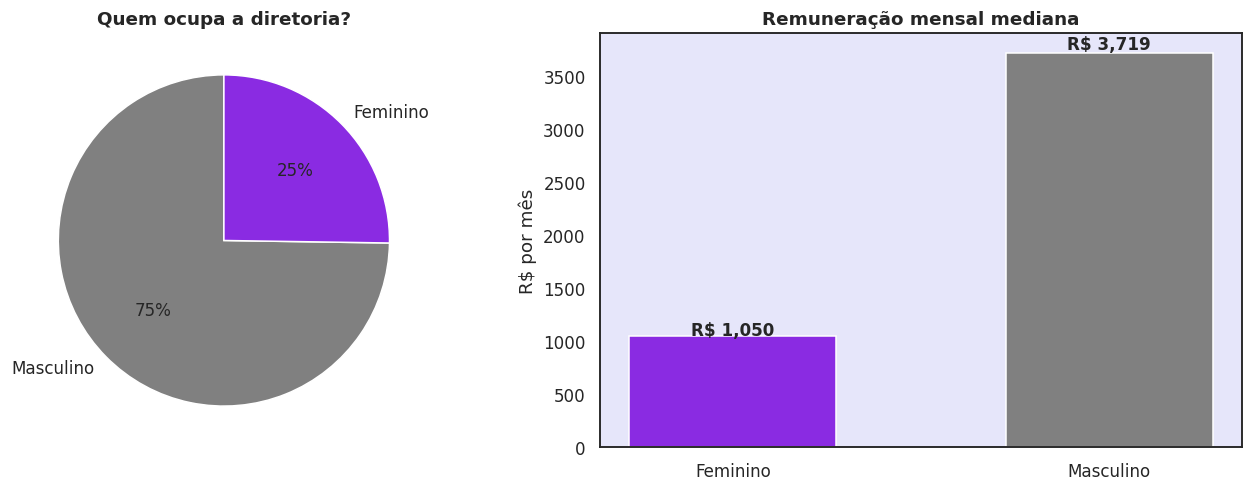


Mann-Whitney U (M > F) na diretoria: p = 7.35e-36 (significativo)
n: 1,312 homens, 443 mulheres


In [64]:
# ═══════════════════════════════════════════════════════════════════════════════
# A ANÁLISE DA DIRETORIA (vínculo 80), em remuneração MENSAL
# ═══════════════════════════════════════════════════════════════════════════════
if len(df_diretoria) == 0:
    print('Nenhum vínculo de código 80 nesta base. Seção sem dados para analisar.')
else:
    d = df_diretoria.copy()
    d['genero_rotulo'] = d['genero'].astype(str).map(dic_genero)
    d['raca_cor_rotulo'] = d['raca_cor'].astype(str).map(dic_raca).fillna('Não informado')
    d['grau_instrucao_rotulo'] = pd.Categorical(
        d['grau_instrucao'].astype(str).map(dic_instrucao),
        categories=ordem_escolaridade, ordered=True)

    print(f'Vínculos de diretoria na base: {len(d):,}')
    print(f"Participação feminina na diretoria: "
          f"{(d.genero_rotulo == 'Feminino').mean()*100:.1f}%")
    print(f"Participação feminina no mercado geral: "
          f"{(df_analise.genero_rotulo == 'Feminino').mean()*100:.1f}%\n")

    med = d.groupby('genero_rotulo', observed=True)['valor_remuneracao_media'].median()
    if {'Masculino', 'Feminino'}.issubset(med.index):
        gap_dir = gap_pct(med['Masculino'], med['Feminino'])
        print(f"Remuneração MENSAL mediana na diretoria:")
        print(f"  Masculino: R$ {med['Masculino']:,.2f}")
        print(f"  Feminino:  R$ {med['Feminino']:,.2f}")
        print(f"  Gap: {gap_dir:.1f}%\n")

        med_geral = df_analise.groupby('genero_rotulo', observed=True)['valor_remuneracao_media'].median()
        gap_geral_mensal = gap_pct(med_geral['Masculino'], med_geral['Feminino'])
        print(f'Para comparar, o gap MENSAL no mercado geral: {gap_geral_mensal:.1f}%')
        print(f'  → na diretoria o gap é '
              f'{"MAIOR" if gap_dir > gap_geral_mensal else "MENOR"} '
              f'({abs(gap_dir - gap_geral_mensal):.1f} ponto percentual de diferença)')

        fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

        for ax in axes:
          ax.set_facecolor('#E6E6FA')

        part = d['genero_rotulo'].value_counts()
        axes[0].pie(part, labels=part.index, autopct='%1.0f%%',
                    colors=[PALETA.get(g, VIOLETA) for g in part.index],
                    startangle=90, textprops={'fontsize': 11})
        axes[0].set_title('Quem ocupa a diretoria?', fontsize=12, fontweight='bold')

        axes[1].bar(med.index, med.values, color=[PALETA.get(g, VIOLETA) for g in med.index],
                    edgecolor='white', width=0.55)
        for i, v in enumerate(med.values):
            axes[1].text(i, v * 1.01, f'R$ {v:,.0f}', ha='center',
                         fontsize=11, fontweight='bold')
        axes[1].set_title('Remuneração mensal mediana', fontsize=12, fontweight='bold')
        axes[1].set_ylabel('R$ por mês')
        plt.tight_layout(); plt.show()

        from scipy.stats import mannwhitneyu as _mw
        m_ = d.loc[d.genero_rotulo == 'Masculino', 'valor_remuneracao_media']
        f_ = d.loc[d.genero_rotulo == 'Feminino', 'valor_remuneracao_media']
        if len(m_) >= 30 and len(f_) >= 30:
            u_, p_ = _mw(m_, f_, alternative='greater')
            print(f'\nMann-Whitney U (M > F) na diretoria: p = {p_:.2e} '
                  f"({'significativo' if p_ < 0.05 else 'NÃO significativo'})")
            print(f'n: {len(m_):,} homens, {len(f_):,} mulheres')
        else:
            print(f'\nAmostra pequena para teste (M={len(m_)}, F={len(f_)}): '
                  'reportem como indício, não como evidência.')
    else:
        print('Um dos gêneros não aparece na diretoria desta base.')

**Duas leituras independentes, e as duas importam:**

1. **A porta de entrada.** Comparando a participação feminina na diretoria com a do mercado geral, ainda temos **menos mulheres na diretoria** do que na participação geral feminina no mercado de trabalho. O achado é de **acesso**: as mulheres não chegam ao topo, que é o teto de vidro na sua forma mais literal.
2. **O que se ganha lá dentro.** Comparem o *gap* mensal da diretoria com o *gap* mensal do mercado geral. Se for maior, a desigualdade **se intensifica** no topo, não se dissolve.

**A análise dos vínculos de direção foi conduzida separadamente e sobre a remuneração mensal, uma vez que a jornada contratual não é aplicável a esses cargos; por essa razão, tais vínculos foram excluídos das hipóteses baseadas em salário-hora"**.

---
---

# **🤖 Estação 5: Machine Learning**

Até aqui, o trabalho **descreveu** a desigualdade. Agora ele vai **modelá-la**, e a pergunta muda de forma:

> **Se duas pessoas tivessem a mesma escolaridade, a mesma raça, a mesma idade, o mesmo tempo de casa, a mesma jornada e a mesma ocupação, e a ÚNICA diferença entre elas fosse o gênero, quanto o modelo prevê de diferença no salário por hora?**

Isso é diferente de tudo que veio antes. As hipóteses comparavam grupos **uma variável por vez**. O modelo controla **todas ao mesmo tempo**, e mede o que sobra depois de descontar todas as explicações alternativas. É o argumento mais forte do TCC, e por isso precisa ser o mais bem construído.

## O caminho desta estação, em 12 passos

| Passo | O que acontece | Por que importa |
|---|---|---|
| **5.1** | A amostra de 150 mil | Responde: *"150 mil de 6 milhões é pouco?"* |
| **5.2** | O alvo em log | O salário não é simétrico; o log conserta isso |
| **5.3** | O erro do `stratify` (de propósito) | Entender um erro é melhor do que evitá-lo |
| **5.4** | Separar treino e teste | O cofre 🔒 que só se abre no fim |
| **5.5** | A régua: MAE, RMSE, R² | Definir "bom" ANTES de ver quem ganhou |
| **5.6** | As variáveis (e o conserto da RAM) | Onde a memória estourava, e por quê |
| **5.7** | A mesa de seleção | Quais variáveis realmente ajudam |
| **5.8** | O preparo no Pipeline | Nada aprende fora do treino |
| **5.9** | Os 6 modelos na mesma prova | Comparação justa |
| **5.10** | 👑 **A coroação do campeão** | **Um modelo só, daqui em diante** |
| **5.11** | Ajuste de botões no campeão | O GridSearch, no modelo certo |
| **5.12–5.15** | Gráficos, importâncias, contrafactual e modelo salvo | **Tudo do campeão** |

## 🔒 O diagrama do fluxo (a ordem que impede o vazamento)

```
   BASE LIMPA
        │
        ├─ [regra fixa / rótulo] ──────────► pode acontecer aqui (Estação 3) ✅
        │
        ▼
   ┌──────────────────┐
   │  SEPARAR 75/25   │  ◄── depois daqui, o TESTE vira cofre 🔒
   └──────────────────┘
        │
        ├──► TREINO ──► [tudo que CALCULA um número: mediana, escala, encoding]
        │                    │
        │                    └──► aprende AQUI, dentro do Pipeline
        │
        └──► TESTE  ──► só APLICA o que foi aprendido no treino
                             │
                             └──► aberto UMA vez, no fim, para a nota final
```

**O que é vazamento (*data leakage*):** deixar o modelo ver, mesmo que sem querer, qualquer informação do teste durante o treino. O caso clássico: calcular a mediana com a base inteira e usá-la para preencher vazios. Parece inofensivo, mas essa mediana carrega um pedacinho da resposta do teste, e a nota final sai **melhor do que a verdade**. Aí o modelo vai para o mundo real e decepciona.

**O `Pipeline` do scikit-learn existe exatamente para tornar o vazamento impossível.** Ele amarra preparo e modelo num objeto só; quando esse objeto é treinado, cada passo aprende **apenas** com o que recebeu do treino. É por isso que este notebook nunca faz **`StandardScaler().fit()`** solto no meio do código.

---
## **5.1 A Amostra de 150 Mil Linhas É Ruim?**

**Resposta curta: não. Ela é mais do que suficiente, e dá para PROVAR isso, é o que esta seção faz.**

**Por que precisamos de uma amostra menor?** A base tem milhões de linhas. Treinar seis modelos, rodar validação cruzada e busca de hiperparâmetros sobre tudo isso estoura a RAM do Colab (foi o que aconteceu). A saída é treinar num recorte **aleatório** da base.

**Por que 150 mil não é pouco?** Porque a precisão de uma estimativa estatística **não depende do tamanho da população, e sim do tamanho da amostra**. A margem de erro cai com a raiz quadrada de **`n`**:

$$\text{erro padrão} \;\propto\; \frac{1}{\sqrt{n}}$$

Com **`n = 150.000`**, a raiz quadrada é ~387 e a margem de erro fica na terceira casa decimal. Ir para 6 milhões (raiz quadrada de ~2.449) melhoraria a precisão em cerca de **6 vezes** num número que já está estável na terceira casa. Custaria horas de processamento e vários gigabytes para mudar um resultado que **não muda**.

É a mesma lógica de uma pesquisa eleitoral: 2 mil entrevistas descrevem 150 milhões de eleitores com 2 pontos de margem. O que importa é a amostra ser **aleatória**, não o seu tamanho em relação ao todo.

**Mas isso não se aceita por fé.** Vamos testar de duas maneiras.

In [65]:
# ═══════════════════════════════════════════════════════════════════════════════
# TESTE 1: a amostra tem a mesma cara da base inteira?
# ═══════════════════════════════════════════════════════════════════════════════
N_AMOSTRA = min(150_000, len(df_analise))
amostra = df_analise.sample(n=N_AMOSTRA, random_state=42)

def retrato(dados, nome):
    """Um 'retrato falado' da base: os números que precisam ser iguais nas duas."""
    fem = dados[dados.genero_rotulo == 'Feminino']
    mas = dados[dados.genero_rotulo == 'Masculino']
    superior = ['Superior completo', 'Mestrado', 'Doutorado']
    return pd.Series({
        'linhas':                len(dados),
        'mediana salário/h':     round(dados['salario_hora'].median(), 2),
        'média salário/h':       round(dados['salario_hora'].mean(), 2),
        '% mulheres':            round((dados.genero_rotulo == 'Feminino').mean() * 100, 2),
        '% superior ou mais':    round(dados['grau_instrucao_rotulo'].isin(superior).mean() * 100, 2),
        'idade média':           round(dados['idade'].mean(), 2),
        'gap bruto %':           round(gap_pct(mas['salario_hora'].median(),
                                               fem['salario_hora'].median()), 2),
    }, name=nome)

comparacao = pd.concat([retrato(df_analise, 'Base inteira'),
                        retrato(amostra,    'Amostra 150 mil')], axis=1)
comparacao['diferença'] = (comparacao['Amostra 150 mil'] - comparacao['Base inteira']).round(3)
print(comparacao.to_string())
print('\n→ Compare a coluna "diferença": se os números batem até a segunda casa decimal,')
print('  a amostra é um retrato fiel da base. É exatamente isso que se espera de uma')
print('  amostragem aleatória grande.')

                    Base inteira  Amostra 150 mil   diferença
linhas                6059131.00        150000.00 -5909131.00
mediana salário/h           7.06             7.05       -0.01
média salário/h            14.30            14.35        0.05
% mulheres                 43.06            43.08        0.02
% superior ou mais         18.87            18.89        0.02
idade média                35.17            35.15       -0.02
gap bruto %                 9.38             9.42        0.04

→ Compare a coluna "diferença": se os números batem até a segunda casa decimal,
  a amostra é um retrato fiel da base. É exatamente isso que se espera de uma
  amostragem aleatória grande.


In [66]:
# ═══════════════════════════════════════════════════════════════════════════════
# TESTE 2: e se tivéssemos sorteado OUTRA amostra? O resultado mudaria?
# Sorteamos 6 amostras diferentes e olhamos o quanto o gap oscila entre elas.
# ═══════════════════════════════════════════════════════════════════════════════
gaps, medianas = [], []
for semente in [1, 7, 21, 42, 99, 2026]:
    a = df_analise.sample(n=N_AMOSTRA, random_state=semente)
    g = gap_pct(a.loc[a.genero_rotulo == 'Masculino', 'salario_hora'].median(),
                a.loc[a.genero_rotulo == 'Feminino',  'salario_hora'].median())
    gaps.append(g); medianas.append(a['salario_hora'].median())
    print(f'  semente {semente:>5}: gap = {g:5.2f}%   |   mediana = R$ {medianas[-1]:.2f}')

gap_real = gap_pct(df_analise.loc[df_analise.genero_rotulo == 'Masculino', 'salario_hora'].median(),
                   df_analise.loc[df_analise.genero_rotulo == 'Feminino',  'salario_hora'].median())

print(f'\n  Base inteira:      gap = {gap_real:5.2f}%   |   mediana = R$ {df_analise["salario_hora"].median():.2f}')
print(f'\nOscilação entre as 6 amostras: {min(gaps):.2f}% a {max(gaps):.2f}% '
      f'(amplitude de {max(gaps) - min(gaps):.2f} ponto percentual)')
print('→ Trocar a amostra praticamente não move o resultado. A conclusão do TCC')
print('  NÃO depende de qual amostra de 150 mil foi sorteada. É isso que queríamos provar.')

del a; _ = gc.collect()

  semente     1: gap =  9.41%   |   mediana = R$ 7.07
  semente     7: gap =  9.35%   |   mediana = R$ 7.06
  semente    21: gap =  8.55%   |   mediana = R$ 7.07
  semente    42: gap =  9.42%   |   mediana = R$ 7.05
  semente    99: gap =  9.50%   |   mediana = R$ 7.07
  semente  2026: gap =  8.70%   |   mediana = R$ 7.09

  Base inteira:      gap =  9.38%   |   mediana = R$ 7.06

Oscilação entre as 6 amostras: 8.55% a 9.50% (amplitude de 0.94 ponto percentual)
→ Trocar a amostra praticamente não move o resultado. A conclusão do TCC
  NÃO depende de qual amostra de 150 mil foi sorteada. É isso que queríamos provar.


**Para viabilizar o treinamento dos modelos dentro dos limites computacionais disponíveis, foi extraída uma subamostra aleatória de 150.000 vínculos (`random_state=42`, garantindo reprodutibilidade). A representatividade da subamostra foi verificada por dois procedimentos: (i) comparação das estatísticas descritivas centrais com as da base completa, e (ii) análise de estabilidade sobre seis subamostras independentes. Em ambos, as estimativas mantiveram-se estáveis, evidenciando que a redução amostral não compromete a validade dos resultados.**

**Duas ressalvas honestas:**

1. A amostra é ótima para o **comportamento geral**. Para subgrupos muito pequenos (por exemplo, mulheres indígenas com doutorado em TI), 150 mil linhas podem deixar poucas dezenas de casos. Análises de subgrupos raros devem usar a **base completa**, e é por isso que a Seção 4 inteira roda no `df_analise`, não na amostra.
2. A amostra serve ao **modelo**; as **hipóteses** já foram testadas na base completa. Essa divisão de trabalho é intencional.

---
## **5.2 A Variável Alvo: Por Que Prever o `log` do Salário**

Na Estação 2 vimos que o salário tem cauda longa à direita, e em log vira quase um sino. Agora vem a consequência prática disso.

### **O que o log muda no modelo.**
Sem log, o modelo tenta minimizar erros **em reais**, e erros grandes acontecem justamente nos salários altos, então ele gasta toda a energia acertando os poucos ricos e erra sistematicamente a maioria. Com log, o modelo passa a minimizar erros **em proporção**: errar R\$ 2 num salário de R\$ 10 pesa igual a errar R\$ 40 num salário de R\$ 200. É assim que se deve tratar salário.

**Num modelo linear sobre log, cada coeficiente vira `percentual`**. Um coeficiente de **`-0,19`** para "ser mulher" significa:

$$e^{-0{,}19} - 1 = -0{,}173 \;\;\Rightarrow\;\; \text{cerca de } -17\% \text{ no salário/hora}$$

Ou seja: o modelo entrega o *gap* **já em porcentagem**, controlado por todo o resto. É exatamente o número que o trabalho procura.

### **⚠️ O preço do log (e é aqui que quase todo mundo erra)**
Quando o alvo é **`log(salário)`**, **todas as métricas que o scikit-learn calcula estão em log**, não em reais. Um **`MAE = 0,31`** **não é R\$ 0,31**: é 0,31 na escala logarítmica.


In [67]:
# ═══════════════════════════════════════════════════════════════════════════════
# O ALVO E AS VARIÁVEIS EXPLICATIVAS
# ═══════════════════════════════════════════════════════════════════════════════

# y = o que queremos prever, na escala logarítmica
y = np.log(amostra['salario_hora'])

print('O alvo em duas escalas:')
print(f"  salário/hora  → mediana R$ {amostra['salario_hora'].median():.2f} | "
      f"média R$ {amostra['salario_hora'].mean():.2f} | "
      f"assimetria {amostra['salario_hora'].skew():.2f}")
print(f'  log(salário)  → mediana {y.median():.3f} | média {y.mean():.3f} | '
      f'assimetria {y.skew():.2f}')
print('\n→ A assimetria (skew) mede o quanto a distribuição pende para um lado.')
print('  Zero = simétrica. Repare como o log traz esse número para perto de zero:')
print('  é a prova numérica do que o histograma da Estação 2 mostrou.')

O alvo em duas escalas:
  salário/hora  → mediana R$ 7.05 | média R$ 14.35 | assimetria 6.85
  log(salário)  → mediana 1.953 | média 2.143 | assimetria 1.13

→ A assimetria (skew) mede o quanto a distribuição pende para um lado.
  Zero = simétrica. Repare como o log traz esse número para perto de zero:
  é a prova numérica do que o histograma da Estação 2 mostrou.


---
## **5.3 `stratify`: Provocando o Erro de Propósito**

O **`stratify`** garante que as **proporções das classes** fiquem iguais no treino e no teste. Ele é obrigatório quando o alvo é uma **categoria desbalanceada** (por exemplo, "evadiu / não evadiu" com 15% de evasão).

**Aqui o alvo é um número contínuo, ou seja, não existem classes para proporcionar.** Cada salário é praticamente único, então cada valor viraria uma "classe" com uma pessoa só, e é impossível dividir uma pessoa entre treino e teste.

Em vez de só afirmar isso, vamos **provocar o erro de propósito**. Um erro que a gente já viu acontecer, e entendeu, nunca mais assusta numa apresentação.

In [68]:
# ═══════════════════════════════════════════════════════════════════════════════
# O ERRO PROPOSITAL: para nunca mais ter medo dele
X_temporario = amostra[['idade', 'tempo_emprego', 'horas_semanais']]

try:
    train_test_split(X_temporario, y, test_size=0.25, random_state=42, stratify=y)
    print('Não deu erro?! Isso seria inesperado.')
except ValueError as e:
    print('❌ ERRO (esperado, e é isso que queríamos ver):')
    print('  ', str(e)[:130], '...')
    print('\n📖 Tradução para o português: o scikit-learn tentou montar grupos com cada')
    print('   valor do alvo e encontrou grupos de UMA pessoa só. Não dá para colocar')
    print('   a mesma pessoa no treino e no teste ao mesmo tempo.')
    print('\n✅ Decisão consciente: alvo contínuo separa SEM stratify.')
    print('   Não é descuido: é a natureza do alvo. Olhamos, entendemos e decidimos.')

del X_temporario; _ = gc.collect()

❌ ERRO (esperado, e é isso que queríamos ver):
   The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than ...

📖 Tradução para o português: o scikit-learn tentou montar grupos com cada
   valor do alvo e encontrou grupos de UMA pessoa só. Não dá para colocar
   a mesma pessoa no treino e no teste ao mesmo tempo.

✅ Decisão consciente: alvo contínuo separa SEM stratify.
   Não é descuido: é a natureza do alvo. Olhamos, entendemos e decidimos.


---
## **5.4 Separar as Bases Entre Treino e Teste**

**A analogia da prova da escola:** se a prova tiver exatamente as mesmas questões da aula, todo mundo gabarita, mas isso mede **memória**, não aprendizado. Uma prova com **questões novas** mede o que a pessoa realmente aprendeu.

- **Treino (75%):** onde aprende tudo, como o preenchimento, a escala, o encoding, o modelo.
- **Teste (25%):** é o cofre 🔒 e fica trancado até o final,quando é aberto **uma única vez**, para a nota final.

Espiar o teste antes da hora infla a nota de mentira. E o pior é que ninguém percebe: o notebook mostra um resultado lindo que não se repete na vida real.

**Para conferir se o sorteio foi honesto** é necessário comparar média e mediana dos dois lados. Se forem parecidas, o sorteio distribuiu bem.

In [69]:
# ═══════════════════════════════════════════════════════════════════════════════
# AS VARIÁVEIS EXPLICATIVAS: por que cada uma está aqui
# ═══════════════════════════════════════════════════════════════════════════════
# idade          → experiência de vida / momento da carreira
# tempo_emprego  → antiguidade no vínculo atual (em meses)
# horas_semanais → jornada contratada
# vinculo_rotulo → o tipo de contrato (CLT, servidor, temporário, aprendiz...)
# genero_rotulo  → a variável do coração deste TCC
# raca_cor_rotulo→ para medir gênero e raça no MESMO modelo (interseccionalidade)
# grau_instrucao_rotulo → escolaridade
# ocupacao_familia → o que a pessoa faz (tratada em 5.6)
#
# NÃO entram: 'ano', 'uf', 'id_municipio' e 'valor_remuneracao_media'.
#   - valor_remuneracao_media seria VAZAMENTO ÓBVIO: o salário/hora é calculado a
#     partir dele. O modelo acertaria tudo sem aprender nada. É o erro nº 1 de quem
#     começa: dar ao modelo uma variável que contém a resposta.
#   - ano/uf/id_municipio poderiam entrar numa versão futura (efeito região e período),
#     mas ampliam muito as colunas e não são a pergunta central. Fica registrado.
# ═══════════════════════════════════════════════════════════════════════════════

# ANO e UF entram como controles quando existem na base (a RAIS tem os dois).
# ano  -> controla o período: inflação, ciclo econômico, mudanças de legislação.
# uf   -> controla a região: custo de vida e estrutura produtiva mudam muito por estado.
# Sem esses controles, uma diferença regional ou de época poderia ser confundida
# com efeito de gênero. Com eles, a comparação fica mais justa.
CONTROLES_EXTRA = [c for c in ['ano', 'uf'] if c in amostra.columns]

VARIAVEIS = ['idade', 'tempo_emprego', 'horas_semanais',
             'vinculo_rotulo', 'genero_rotulo', 'raca_cor_rotulo',
             'grau_instrucao_rotulo', 'ocupacao'] + CONTROLES_EXTRA

X = amostra[VARIAVEIS].copy()
if CONTROLES_EXTRA:
    print(f'Controles extras encontrados e incluídos no modelo: {CONTROLES_EXTRA}')
    for c in CONTROLES_EXTRA:
        X[c] = X[c].astype(str)          # ano é categoria, não quantidade
else:
    print('Colunas ano/uf não estão nesta base: o modelo roda sem esses controles.')

print(f'X: {X.shape[0]:,} linhas x {X.shape[1]} colunas')
print(f'y: {len(y):,} valores (log do salário por hora)')
print('\nConferência anti-vazamento: o alvo ou seus ingredientes estão em X?')
for proibida in ['salario_hora', 'valor_remuneracao_media']:
    print(f'  {proibida:<28} em X? {proibida in X.columns}   (tem que ser False)')

Controles extras encontrados e incluídos no modelo: ['ano', 'uf']
X: 150,000 linhas x 10 colunas
y: 150,000 valores (log do salário por hora)

Conferência anti-vazamento: o alvo ou seus ingredientes estão em X?
  salario_hora                 em X? False   (tem que ser False)
  valor_remuneracao_media      em X? False   (tem que ser False)


In [70]:
# ═══════════════════════════════════════════════════════════════════════════════
# A SEPARAÇÃO 75 / 25
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42)

print(f'Treino: {X_tr.shape[0]:,} linhas  |  Teste: {X_te.shape[0]:,} linhas 🔒\n')

print('Conferência de sanidade: os dois lados são parecidos?')
print(f'{"":22} {"TREINO":>12} {"TESTE":>12}')
print(f'{"log médio":22} {y_tr.mean():12.4f} {y_te.mean():12.4f}')
print(f'{"log mediano":22} {y_tr.median():12.4f} {y_te.median():12.4f}')
print(f'{"salário/h mediano":22} {"R$ " + format(np.exp(y_tr.median()), ".2f"):>12} {"R$ " + format(np.exp(y_te.median()), ".2f"):>12}')
print(f'{"% mulheres":22} {(X_tr.genero_rotulo=="Feminino").mean()*100:11.2f}% '
      f'{(X_te.genero_rotulo=="Feminino").mean()*100:11.2f}%')
print('\n→ Números praticamente idênticos nos dois lados: sorteio honesto. ✅')
print('  (Repare: nem precisamos de stratify para o equilíbrio acontecer, com')
print('   dezenas de milhares de linhas, o sorteio aleatório já equilibra sozinho.)')

Treino: 112,500 linhas  |  Teste: 37,500 linhas 🔒

Conferência de sanidade: os dois lados são parecidos?
                             TREINO        TESTE
log médio                    2.1426       2.1427
log mediano                  1.9535       1.9511
salário/h mediano           R$ 7.05      R$ 7.04
% mulheres                   43.05%       43.16%

→ Números praticamente idênticos nos dois lados: sorteio honesto. ✅
  (Repare: nem precisamos de stratify para o equilíbrio acontecer, com
   dezenas de milhares de linhas, o sorteio aleatório já equilibra sozinho.)


In [71]:
# ═══════════════════════════════════════════════════════════════════════════════
# CHECKPOINT: salvar treino e teste em parquet
# A cultura do checkpoint: a cada etapa vencida, uma foto numerada. Se algo der
# errado lá na frente, volta-se ao último checkpoint em vez de rodar tudo de novo.
for objeto, nome in [(X_tr, '03_X_treino'), (X_te, '03_X_teste')]:
    objeto.to_parquet(f'{PASTA_SAIDA}/{nome}.parquet')
y_tr.to_frame('log_salario_hora').to_parquet(f'{PASTA_SAIDA}/03_y_treino.parquet')
y_te.to_frame('log_salario_hora').to_parquet(f'{PASTA_SAIDA}/03_y_teste.parquet')

print(f'Checkpoint 03 salvo em: {PASTA_SAIDA}')
for f in sorted(os.listdir(PASTA_SAIDA)):
    if f.startswith('03_'):
        print(f'  {f:<28} {os.path.getsize(f"{PASTA_SAIDA}/{f}")/1024:8,.0f} KB')

Checkpoint 03 salvo em: /content/drive/MyDrive/TCC-MulheresInTech-FlyEducação2026/VersoesTcc/TccConsolidado
  03_X_teste.parquet                531 KB
  03_X_treino.parquet             1,554 KB
  03_y_teste.parquet                599 KB
  03_y_treino.parquet             1,745 KB


---
## **5.5 A Régua: Como se Mede o Sucesso**

**A régua vem ANTES dos modelos, de propósito.** Se olhássemos os resultados primeiro para **depois** escolhermos a métrica, escolheríamos justamente a que faz o modelo favorito parecer bom. Definir a régua **antes** é o que impede esse autoengano.

Na regressão não existem "os quatro destinos" da classificação (acerto/erro de cada lado). O erro aqui é uma **distância** entre o previsto e o real.

### **MAE: Erro Absoluto Médio**

$$MAE = \frac{1}{n}\sum |y_i - \hat{y}_i|$$

**Lendo:** $y_i$ é o valor real, $\hat{y}_i$ o previsto. O módulo ignora a direção do erro (errar para cima ou para baixo pesa igual) e a média resume tudo: **"em média, erramos X"**.

### **RMSE: Raiz Quadrada do Erro Quadrático Médio**

$$RMSE = \sqrt{\frac{1}{n}\sum (y_i - \hat{y}_i)^2}$$

**Lendo:** o quadrado faz um **erro grande pesar muito mais** (um erro de 10 pesa como cem erros de 1); e a raiz devolve o resultado para a escala original. **Se o RMSE estiver muito acima do MAE, o modelo tem erros feios escondidos atrás de uma média boa.** Comparar os dois é um diagnóstico gratuito.

### **R²: o coeficiente de determinação**

$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

**Esta é leitura mais bonita das três** e, para isso, precisamos olhar o denominador. Ele é o erro de um "modelo" que chuta **sempre a média** ($\bar{y}$), sem considerar mais nada. O numerador é o erro do nosso modelo. Então o R² responde: **"quanto do erro do chute burro nós conseguimos eliminar?"**
- **R² = 1** → acertou tudo.
- **R² = 0** → empatou com o chute da média (não aprendeu nada).
- **R² < 0** → **perdeu** para o chute da média. Acontece, e é vexame documentado.

### **E a régua nas duas escalas**

Como o alvo está em log, calculamos tudo **duas vezes**:
- **`_log`**: a escala em que o modelo realmente treina e é comparado. **É por ela que o campeão é escolhido**, porque é ela que o modelo está otimizando.
- **`_R$`**: a mesma coisa traduzida para reais.

**Uma sutileza honesta sobre a tradução:** ao fazer **`exp()`** de uma previsão em log, o resultado estima a **mediana** do salário daquele perfil, não a média (é a *desigualdade de Jensen*). Para o nosso uso, comparar modelos e medir o *gap* em percentual, não atrapalha em nada. Mas é bom saber e dizer.

In [72]:
# ═══════════════════════════════════════════════════════════════════════════════
# A RÉGUA: uma função só, usada por TODOS os modelos, sempre igual
# ═══════════════════════════════════════════════════════════════════════════════
def avaliar(y_log_real, y_log_previsto):
    """Calcula as métricas nas DUAS escalas: log (onde o modelo treina) e R$ (onde a gente entende).

    O nome de cada chave diz a escala. Nunca mais 'MAE (R$)' com número em log.
    """
    y_log_real = np.asarray(y_log_real, dtype=float)
    y_log_previsto = np.asarray(y_log_previsto, dtype=float)

    reais_verdadeiros = np.exp(y_log_real)        # de volta para R$/hora
    reais_previstos   = np.exp(y_log_previsto)

    erro_relativo = np.abs(reais_previstos - reais_verdadeiros) / reais_verdadeiros

    return {
        'MAE_log':   mean_absolute_error(y_log_real, y_log_previsto),
        'RMSE_log':  float(np.sqrt(mean_squared_error(y_log_real, y_log_previsto))),
        'R2_log':    r2_score(y_log_real, y_log_previsto),
        'MAE_R$':    mean_absolute_error(reais_verdadeiros, reais_previstos),
        'erro_%_mediano': float(np.median(erro_relativo) * 100),
    }

# Um exemplo para fixar a ideia: o "modelo" que chuta sempre a mediana do treino
chute = np.full(len(y_te), y_tr.median())
exemplo = avaliar(y_te, chute)
print('O chute da mediana do treino, medido pela nossa régua:')
for k, v in exemplo.items():
    print(f'  {k:<16} {v:8.4f}')
print('\n📖 Guarde estes números: eles são o PISO. Qualquer modelo que não os supere')
print('   não aprendeu nada. E repare no R2_log ≈ 0: é exatamente o que a fórmula prevê')
print('   para quem chuta o centro: o numerador e o denominador ficam quase iguais.')

O chute da mediana do treino, medido pela nossa régua:
  MAE_log            0.6512
  RMSE_log           0.8899
  R2_log            -0.0474
  MAE_R$             9.7462
  erro_%_mediano    50.3409

📖 Guarde estes números: eles são o PISO. Qualquer modelo que não os supere
   não aprendeu nada. E repare no R2_log ≈ 0: é exatamente o que a fórmula prevê
   para quem chuta o centro: o numerador e o denominador ficam quase iguais.


---
## **5.6 As Variáveis: e o Conserto do Problema de RAM**

Aqui está **a causa real do estouro de memória**, e ela não era o número de linhas.

**O problema.** A coluna **`ocupacao`** é o código CBO de **6 dígitos**. Cada código é uma ocupação específica ("analista de sistemas: desenvolvimento", "técnico em operação de rede"...). O `OneHotEncoder` transforma **cada categoria numa coluna nova de 0 e 1**. Com milhares de códigos distintos, isso vira milhares de colunas, e a conta de memória é implacável:

$$\text{linhas} \times \text{colunas} \times 8 \text{ bytes}$$

Com 112 mil linhas de treino e ~2.500 colunas, são **mais de 2 GB só para a matriz de entrada**, e o Random Forest precisa de várias cópias dela. É aí que o Colab trava após utilizar toda a memória RAM.

**A solução: usar a hierarquia que a própria CBO já tem.** O código CBO é organizado como um endereço, do geral para o específico:

| Dígitos | Nível | Exemplo |
|---|---|---|
| 1º | Grande grupo | `2` = profissionais das ciências e das artes |
| 2 primeiros | **Subgrupo principal** | `21` = pesquisadores e profissionais de ciências exatas |
| 4 primeiros | Família | `2124` = analistas de sistemas |
| 6 | Ocupação exata | `212405` = analista de desenvolvimento de sistemas |

Cortando nos **2 primeiros dígitos**, saímos de milhares de categorias para algumas dezenas, **sem perder o que interessa ao modelo**, que é "de que ramo profissional essa pessoa é". A diferença entre dois códigos vizinhos de 6 dígitos é detalhe; a diferença entre o grupo **`21`** e o **`52`** é a que move salário.

**Isso não é gambiarra para caber na RAM: é uma decisão de modelagem melhor.** Categorias com pouquíssimos casos cada uma dão ao modelo mais chance de decorar do que de aprender. Agrupar dá **mais dados por categoria** e um modelo mais estável. A RAM economizada é o bônus.

In [73]:
# ═══════════════════════════════════════════════════════════════════════════════
# AGRUPANDO A OCUPAÇÃO: de milhares de códigos para algumas dezenas de famílias
# ═══════════════════════════════════════════════════════════════════════════════
GRANDES_GRUPOS = {
    '0': '0 Forças armadas e policiais',
    '1': '1 Dirigentes e gerentes',
    '2': '2 Ciências e artes (nível superior)',
    '3': '3 Técnicos de nível médio',
    '4': '4 Serviços administrativos',
    '5': '5 Serviços, vendedores do comércio',
    '6': '6 Agropecuários e florestais',
    '7': '7 Produção de bens e serviços industriais',
    '8': '8 Produção de bens e serviços industriais (cont.)',
    '9': '9 Manutenção e reparação',
}

def familia_cbo(serie):
    """Pega os 2 primeiros dígitos do CBO (o 'subgrupo principal').
    O zfill(6) protege contra códigos que perderam o zero à esquerda ao virar texto."""
    return serie.astype(str).str.strip().str.zfill(6).str[:2]

for base_ in (X_tr, X_te):
    base_['ocupacao_familia'] = familia_cbo(base_['ocupacao'])

n_antes  = X_tr['ocupacao'].nunique()
n_depois = X_tr['ocupacao_familia'].nunique()

print(f'Códigos CBO de 6 dígitos no treino: {n_antes:,} categorias')
print(f'Famílias de 2 dígitos:              {n_depois:,} categorias')
print(f'Redução: {(1 - n_depois/n_antes):.1%} menos colunas depois do OneHotEncoder\n')

linhas_tr = len(X_tr)
print('O que isso significa em memória (só a matriz de entrada):')
print(f'  com CBO de 6 dígitos: ~{linhas_tr * n_antes * 8 / 1024**3:6.2f} GB  ← o que estourava')
print(f'  com famílias:         ~{linhas_tr * n_depois * 8 / 1024**2:6.0f} MB  ← o que cabe folgado')

print('\nAs famílias mais comuns na base (com o grande grupo entre parênteses):')
top = X_tr['ocupacao_familia'].value_counts().head(8)
for fam, qtd in top.items():
    print(f'  CBO {fam}: {qtd:>7,} vínculos   ({GRANDES_GRUPOS.get(fam[0], "?")})')

Códigos CBO de 6 dígitos no treino: 1,919 categorias
Famílias de 2 dígitos:              48 categorias
Redução: 97.5% menos colunas depois do OneHotEncoder

O que isso significa em memória (só a matriz de entrada):
  com CBO de 6 dígitos: ~  1.61 GB  ← o que estourava
  com famílias:         ~    41 MB  ← o que cabe folgado

As famílias mais comuns na base (com o grande grupo entre parênteses):
  CBO 51:  19,218 vínculos   (5 Serviços, vendedores do comércio)
  CBO 41:  15,676 vínculos   (4 Serviços administrativos)
  CBO 52:  10,543 vínculos   (5 Serviços, vendedores do comércio)
  CBO 78:   7,540 vínculos   (7 Produção de bens e serviços industriais)
  CBO 42:   7,403 vínculos   (4 Serviços administrativos)
  CBO 71:   6,825 vínculos   (7 Produção de bens e serviços industriais)
  CBO 76:   3,360 vínculos   (7 Produção de bens e serviços industriais)
  CBO 14:   3,297 vínculos   (1 Dirigentes e gerentes)


---
## 5.7 **A Mesa de Seleção: Quais Variáveis Realmente Ajudam?**

Nenhum teste sozinho decide. Por isso montamos uma **mesa**: quatro medidas diferentes olhando as mesmas variáveis. Quando elas concordam, a decisão é fácil; quando discordam, a discordância **ensina alguma coisa** sobre os dados.

| Medida | O que ela enxerga | Ponto cego |
|---|---|---|
| **Correlação de Pearson** | Relação em **linha reta**, com sinal (+/−) | Só reta: relação em curva ganha zero injustamente |
| **`f_regression`** | Força da relação **linear** com o alvo | O mesmo ponto cego da correlação |
| **`mutual_info_regression`** | Redução de incerteza em **qualquer formato** | Não tem sinal: diz "informa", não "para cima ou para baixo" |
| **Importância da floresta** | O quanto a variável foi **útil na prática** | Tende a favorecer variáveis com muitas categorias |

**Aqui separamos** correlação e **`f_regression`** só nas variáveis **realmente numéricas**; para as variáveis **categóricas**, usamos a informação mútua (que aceita códigos arbitrários porque não assume ordem nenhuma) e a razão de variância. Cada ferramenta no seu lugar.

In [74]:
# ═══════════════════════════════════════════════════════════════════════════════
# PARTE A: as variáveis NUMÉRICAS de verdade
# ═══════════════════════════════════════════════════════════════════════════════
c_num = ['idade', 'tempo_emprego', 'horas_semanais']
c_cat = (['vinculo_rotulo', 'genero_rotulo', 'raca_cor_rotulo',
          'grau_instrucao_rotulo', 'ocupacao_familia']
         + [c for c in CONTROLES_EXTRA if c in X_tr.columns])
print('Categóricas do modelo:', c_cat)

correl = X_tr[c_num].assign(alvo=y_tr.values).corr(numeric_only=True)['alvo'].drop('alvo')
f_reg  = pd.Series(SelectKBest(f_regression, k='all').fit(X_tr[c_num], y_tr).scores_, index=c_num)
mi_num = pd.Series(mutual_info_regression(X_tr[c_num], y_tr, random_state=42), index=c_num)

mesa_num = pd.DataFrame({
    'correlacao (com sinal)': correl.round(3),
    'f_regression':           f_reg.round(1),
    'info_mutua':             mi_num.round(4),
}).sort_values('f_regression', ascending=False)

print('VARIÁVEIS NUMÉRICAS: o sinal da correlação é a informação que só ela dá:\n')
print(mesa_num.to_string())
print('\n📖 Sinal POSITIVO = quando a variável sobe, o salário sobe.')
print('   Sinal NEGATIVO = quando a variável sobe, o salário desce.')

Categóricas do modelo: ['vinculo_rotulo', 'genero_rotulo', 'raca_cor_rotulo', 'grau_instrucao_rotulo', 'ocupacao_familia', 'ano', 'uf']
VARIÁVEIS NUMÉRICAS: o sinal da correlação é a informação que só ela dá:

                correlacao (com sinal)  f_regression  info_mutua
tempo_emprego                    0.442       27238.4      0.1633
idade                            0.336       14288.9      0.0892
horas_semanais                  -0.324       13171.5      0.1686

📖 Sinal POSITIVO = quando a variável sobe, o salário sobe.
   Sinal NEGATIVO = quando a variável sobe, o salário desce.


In [75]:
# ═══════════════════════════════════════════════════════════════════════════════
# PARTE B: as variáveis CATEGÓRICAS (aqui correlação NÃO se aplica)
# ═══════════════════════════════════════════════════════════════════════════════
def forca_categorica(coluna, alvo):
    """Quanto da variação do alvo é explicada por saber a categoria da pessoa?
    É a razão de correlação (eta²): 0 = a categoria não diz nada; 1 = diz tudo.
    Funciona com categorias SEM ordem, que é exatamente o nosso caso."""
    grupos = alvo.groupby(coluna.values, observed=True)
    media_geral = alvo.mean()
    entre = ((grupos.mean() - media_geral) ** 2 * grupos.size()).sum()   # variação ENTRE grupos
    total = ((alvo - media_geral) ** 2).sum()                            # variação TOTAL
    return entre / total

linhas = []
for c in c_cat:
    linhas.append({
        'variavel':   c,
        'categorias': X_tr[c].nunique(),
        'eta2 (força)': round(forca_categorica(X_tr[c], y_tr), 4),
        'info_mutua': round(float(mutual_info_regression(
            X_tr[c].astype('category').cat.codes.to_frame(), y_tr,
            discrete_features=[True], random_state=42)[0]), 4),
    })

mesa_cat = pd.DataFrame(linhas).sort_values('eta2 (força)', ascending=False)
print('VARIÁVEIS CATEGÓRICAS: força medida por eta² (razão de correlação):\n')
print(mesa_cat.to_string(index=False))

print('\n📖 Como ler:')
print('   • eta² alto  = saber essa categoria explica muito da variação do salário.')
print('   • O gênero costuma ter eta² BAIXO sozinho, e isso NÃO enfraquece o TCC.')
print('     Sozinho, o gênero explica pouco da variação total (a maior parte vem de')
print('     ocupação e escolaridade). A questão do trabalho é outra: MANTIDO todo o')
print('     resto igual, quanto o gênero ainda muda o salário? Essa é a pergunta que')
print('     só o modelo multivariado responde: e é ela que a Estação 5.14 responde.')

VARIÁVEIS CATEGÓRICAS: força medida por eta² (razão de correlação):

             variavel  categorias  eta2 (força)  info_mutua
grau_instrucao_rotulo          11        0.3604      0.2001
     ocupacao_familia          48        0.3386      0.2624
                  ano           9        0.1795      0.2600
                   uf           9        0.1448      0.2107
       vinculo_rotulo          18        0.1421      0.1188
      raca_cor_rotulo           6        0.0554      0.0579
        genero_rotulo           2        0.0026      0.0097

📖 Como ler:
   • eta² alto  = saber essa categoria explica muito da variação do salário.
   • O gênero costuma ter eta² BAIXO sozinho, e isso NÃO enfraquece o TCC.
     Sozinho, o gênero explica pouco da variação total (a maior parte vem de
     ocupação e escolaridade). A questão do trabalho é outra: MANTIDO todo o
     resto igual, quanto o gênero ainda muda o salário? Essa é a pergunta que
     só o modelo multivariado responde: e é ela que a 

### 🧭 O olhar social, que nenhum teste substitui

Todos esses números medem **relação estatística**, não **justiça**. Uma variável pode passar em todos os testes e ainda ser um atalho para raça, gênero ou renda, e o modelo, sem saber, passaria a reproduzir a desigualdade em vez de apenas medi-la.

Neste trabalho a decisão é consciente e vale explicitar: o gênero está no modelo **justamente para ser medido**, não para orientar decisão sobre pessoa nenhuma. Um modelo assim é ferramenta de **diagnóstico**, nunca de seleção. Se alguém usasse este modelo para definir salário de alguém, estaria automatizando a desigualdade que ele foi feito para denunciar.

---
## **5.8 O preparo, dentro do Pipeline**

Nesta seção, vamos montar o **`ColumnTransformer`**, o objeto que aplica tratamentos diferentes a tipos diferentes de coluna, e deixá-lo **dentro** do Pipeline.

- **Nas variáveis numéricas:** aplicamos o **`SimpleImputer(mediana)`** para eventuais vazios e o **`StandardScaler`** para colocar tudo na mesma escala. Sem isso, **`tempo_emprego`** (em meses, chegando a centenas) dominaria **`horas_semanais`** (até 44) só por ter números maiores. Modelos lineares são sensíveis a isso; árvores não são, mas padronizar não os prejudica.
- **Nas variáveis categóricas:** **`OneHotEncoder`** transforma cada categoria numa coluna de 0 e 1. O **`handle_unknown='ignore'`** é a rede de segurança: se aparecer no teste uma categoria que não existia no treino, ele preenche com zeros em vez de quebrar.

**O ponto que faz tudo isso valer:** como está dentro do Pipeline, a mediana e a escala são calculadas **só com o treino**, e depois **aplicadas** ao teste. Inclusive durante a validação cruzada, em cada uma das dobras. É o vazamento se tornando impossível por construção.

In [76]:
# ═══════════════════════════════════════════════════════════════════════════════
# O PREPARO
preparo = ColumnTransformer([
    ('num', Pipeline([('preencher', SimpleImputer(strategy='median')),
                      ('escala',    StandardScaler())]), c_num),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False,
                          min_frequency=30), c_cat),
])
# min_frequency=30: categorias com menos de 30 casos no treino são agrupadas numa
# categoria 'infrequent'. Menos colunas, menos ruído, menos chance de decorar.

# Uma espiada no resultado (só para ver o tamanho da matriz que os modelos receberão)
amostra_preparo = preparo.fit_transform(X_tr.head(5000))
print(f'Colunas depois do preparo: {amostra_preparo.shape[1]}')
print(f'Matriz de treino completa: {len(X_tr):,} x {amostra_preparo.shape[1]} '
      f'≈ {len(X_tr) * amostra_preparo.shape[1] * 8 / 1024**2:.0f} MB, cabe folgado. ✅')
del amostra_preparo; _ = gc.collect()

preparo = ColumnTransformer([          # recriado "zerado", para nada ficar pré-treinado
    ('num', Pipeline([('preencher', SimpleImputer(strategy='median')),
                      ('escala',    StandardScaler())]), c_num),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False,
                          min_frequency=30), c_cat),
])
print('\nPreparo pronto: e zerado: cada passo vai aprender SÓ no treino.')

Colunas depois do preparo: 73
Matriz de treino completa: 112,500 x 73 ≈ 63 MB, cabe folgado. ✅

Preparo pronto: e zerado: cada passo vai aprender SÓ no treino.


---
## **5.9 Os Seis Modelos, e Como Cada um Pensa por Dentro**

### **Baseline (`DummyRegressor`): o chute da média**
Prevê o mesmo valor para todo mundo, sem olhar nenhuma variável. **Ele não está aqui para ganhar: está aqui para ser o piso.** Um modelo que não bate o baseline não aprendeu nada, e ter essa linha na tabela é o que transforma "o R² deu 0,35" em "o R² deu 0,35 **contra 0,00 do chute**".

### **Regressão Linear: a Base Explicável**
A regressão linear encontra a reta (na verdade, o plano em várias dimensões) que passa o mais perto possível de todos os pontos, minimizando a soma dos erros ao quadrado (*mínimos quadrados*). Cada variável ganha um **coeficiente legível**: "ser mulher subtrai X do log do salário". Quase não tem botões para ajustar, e é justamente essa a graça.

### **Ridge: o Freio L2**
A mesma reta, com uma **multa sobre coeficientes grandes** (o jeito que a regressão linear tem de decorar). Encolhe todos um pouco e estabiliza o modelo, principalmente quando há variáveis correlacionadas entre si.
**Botão:** **`alpha`** = a força da multa. **Maior `alpha` = mais freio.**

### **Lasso: o Freio L1, que Zera**
É como o Ridge, mas a multa é de um tipo que consegue **zerar** coeficientes completamente. Na prática, ele **seleciona variáveis sozinho**: as inúteis somem do modelo.
**Botão:** **`alpha`**, também. **Atenção**: com o alvo em log, a escala útil do alpha é bem menor (0,0001 a 0,1) do que seria com o alvo em reais, porque o próprio alvo é um número pequeno.

### **Random Forest: a Floresta que Vota**
A Random Forest treina centenas de árvores de decisão, cada uma vendo um pedaço diferente dos dados e das variáveis, e tira a **média** das previsões. Cada árvore sozinha erra de um jeito; juntas, os erros se cancelam. Esse modelo captura relações **em curva e interações** que a reta não vê.
**Botões:** **`n_estimators`** (quantas árvores), **`max_depth`** (quão fundo cada uma vai: o principal controle de decoreba), **`min_samples_leaf`** (mínimo de casos por folha).

### **Gradient Boosting: a Correção em Cadeia**
As árvores em **sequência**, e cada nova árvore é treinada para consertar o **erro que sobrou** das anteriores. Costuma ser o mais preciso da lista, e é o mais sensível aos botões.
**Botões:** **`learning_rate`** (o tamanho do passo de cada correção: passo menor exige mais árvores, mas generaliza melhor), **`n_estimators`** e **`max_depth`**.

In [77]:
# ═══════════════════════════════════════════════════════════════════════════════
# OS SEIS MODELOS NA MESMA PROVA
# Todos recebem exatamente o mesmo preparo, o mesmo treino e o mesmo teste.
# Os tamanhos abaixo (n_estimators, max_depth) são moderados de propósito: cabem
# na RAM do Colab. O ajuste fino vem em 5.11, e SÓ no campeão.
# ═══════════════════════════════════════════════════════════════════════════════
modelos = {
    'Baseline (chute da média)': DummyRegressor(strategy='mean'),
    'Regressão Linear':          LinearRegression(),
    'Ridge':                     Ridge(alpha=1.0, random_state=42),
    'Lasso':                     Lasso(alpha=0.001, random_state=42, max_iter=5000),
    'Random Forest':             RandomForestRegressor(n_estimators=60, max_depth=14,
                                                       min_samples_leaf=10, random_state=42,
                                                       n_jobs=-1),
    'Gradient Boosting':         GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                                           max_depth=3, random_state=42),
}

fluxos, linhas = {}, []            # fluxos guarda cada Pipeline JÁ TREINADO
for nome, modelo in modelos.items():
    fluxo = Pipeline([('preparo', clone(preparo)), ('modelo', modelo)]).fit(X_tr, y_tr)
    metricas = avaliar(y_te, fluxo.predict(X_te))
    fluxos[nome] = fluxo
    linhas.append({'modelo': nome, **{k: round(v, 4) for k, v in metricas.items()}})
    print(f'  ✓ {nome:<28} MAE_log = {metricas["MAE_log"]:.4f}')

tab = pd.DataFrame(linhas).sort_values('MAE_log').reset_index(drop=True)
print('\n' + '=' * 78)
print('A TABELA (ordenada pelo MAE em log: a escala em que o modelo treina)')
print('=' * 78)
tab

  ✓ Baseline (chute da média)    MAE_log = 0.6710
  ✓ Regressão Linear             MAE_log = 0.3733
  ✓ Ridge                        MAE_log = 0.3733
  ✓ Lasso                        MAE_log = 0.3780
  ✓ Random Forest                MAE_log = 0.3498
  ✓ Gradient Boosting            MAE_log = 0.3503

A TABELA (ordenada pelo MAE em log: a escala em que o modelo treina)


,modelo,MAE_log,RMSE_log,R2_log,MAE_R$,erro_%_mediano
0,Random Forest,0.3498,0.4917,0.6803,6.0334,25.4468
1,Gradient Boosting,0.3503,0.4884,0.6845,6.1582,25.9104
2,Regressão Linear,0.3733,0.5172,0.6463,6.6201,27.2235
3,Ridge,0.3733,0.5171,0.6463,6.6199,27.2235
4,Lasso,0.3780,0.5212,0.6407,6.7280,27.9564
5,Baseline (chute da média),0.6710,0.8695,-0.0000,9.9044,59.0627


**Lendo a tabela, com a régua na mão:**

1. **Baseline primeiro.** Onde ele caiu? Todo mundo que aprendeu de verdade está bem acima dele em R², e bem abaixo em erro. Se algum modelo empatou com o baseline, ele não aprendeu nada.
2. **Comparando `RMSE_log` com `MAE_log`.** Se em algum modelo o RMSE estiver muito acima do MAE, ele tem erros grandes escondidos atrás de uma média boa.
3. **`erro_%_mediano` é a coluna escolhida (para a banca).** Ela diz "metade das previsões erra menos que X%", é a leitura mais intuitiva de todas, e não depende de entender log.
4. **`R2_log` conta a história completa.** Um R² entre 0,3 e 0,5 é honesto e esperado: salário depende de muitas coisas que a RAIS não registra (empresa, negociação, rede de contatos, desempenho). **Um R² próximo de 1 seria motivo de desconfiança, não de comemoração**, quase sempre significa vazamento.

**A leitura mais importante:** o objetivo aqui **não é prever salário com perfeição**. É medir o efeito do gênero **controlando tudo o mais**. Um modelo com R² moderado que isola bem esse efeito vale muito mais, para este trabalho, do que um modelo altíssimo que ninguém consegue explicar.

---
## **5.10 👑 A Coroação do Campeão: *A Regra Mais Importante Deste Notebook***

O campeão é escolhido **UMA vez**, guardado em variáveis com nomes em MAIÚSCULAS, e existe uma função **`usar_campeao()`** que **todas** as células seguintes chamam antes de desenhar qualquer coisa. Ela imprime o nome do modelo em uso e **trava a execução com erro** se algo estiver fora do lugar. Não é possível gerar um gráfico do modelo errado sem que o notebook avise.

**Como o campeão foi escolhido:** o campeão é o modelo com o menor **`MAE_log`** entre os modelos que **não** são baseline. O critério fica escrito numa variável, antes do resultado aparecer, para que ninguém escolha a métrica depois de ver quem ganhou.

In [78]:
# ═══════════════════════════════════════════════════════════════════════════════
# 👑 A COROAÇÃO
# ═══════════════════════════════════════════════════════════════════════════════
CRITERIO = 'MAE_log'        # decidido ANTES de olhar a tabela (ver Estação 5.5)

candidatos = tab[~tab['modelo'].str.startswith('Baseline')]
CAMPEAO_NOME = candidatos.sort_values(CRITERIO).iloc[0]['modelo']
CAMPEAO      = fluxos[CAMPEAO_NOME]          # o Pipeline JÁ TREINADO: o mesmo objeto da tabela

print('=' * 78)
print(f'👑  CAMPEÃO: {CAMPEAO_NOME}')
print('=' * 78)
print(f'Critério de escolha: menor {CRITERIO} (definido antes de ver os resultados)\n')
print(tab[tab.modelo == CAMPEAO_NOME].to_string(index=False))

baseline = tab[tab['modelo'].str.startswith('Baseline')].iloc[0]
campeao_linha = tab[tab.modelo == CAMPEAO_NOME].iloc[0]
melhora = (1 - campeao_linha['MAE_log'] / baseline['MAE_log']) * 100
print(f'\nGanho sobre o baseline: {melhora:.1f}% menos erro. '
      f'(R²: {baseline["R2_log"]:.3f} → {campeao_linha["R2_log"]:.3f})')

# ── Liberar da RAM os modelos que não venceram ────────────────────────────────
for nome in list(fluxos):
    if nome != CAMPEAO_NOME:
        del fluxos[nome]
_ = gc.collect()
print(f'\nModelos perdedores liberados da memória. Sobrou 1: {list(fluxos)}')

👑  CAMPEÃO: Random Forest
Critério de escolha: menor MAE_log (definido antes de ver os resultados)

       modelo  MAE_log  RMSE_log  R2_log  MAE_R$  erro_%_mediano
Random Forest   0.3498    0.4917  0.6803  6.0334         25.4468

Ganho sobre o baseline: 47.9% menos erro. (R²: -0.000 → 0.680)

Modelos perdedores liberados da memória. Sobrou 1: ['Random Forest']


In [79]:
# ═══════════════════════════════════════════════════════════════════════════════
# 🔒 A TRAVA DE SEGURANÇA
# Toda célula que desenha, mede ou conclui QUALQUER COISA daqui pra frente
# chama esta função primeiro. Ela anuncia o modelo em uso e trava se algo
# estiver inconsistente. É o que torna impossível o erro descrito acima.
# ═══════════════════════════════════════════════════════════════════════════════
MODELO_FINAL = CAMPEAO       # por enquanto o campeão sem ajuste; 5.11 pode atualizar
NOME_FINAL   = CAMPEAO_NOME

def usar_campeao(para_que=''):
    """Devolve o modelo campeão e anuncia, em voz alta, qual é."""
    tipo_final    = type(MODELO_FINAL.named_steps['modelo']).__name__
    tipo_esperado = type(modelos[CAMPEAO_NOME]).__name__
    if tipo_final != tipo_esperado:
        raise RuntimeError(
            f'🚨 INCONSISTÊNCIA: o campeão da tabela é {CAMPEAO_NOME} ({tipo_esperado}), '
            f'mas MODELO_FINAL é um {tipo_final}. Rode a Estação 5.10 novamente.')
    print(f'👑 {para_que}' if para_que else '👑', end='  ')
    print(f'Modelo em uso: {NOME_FINAL}  ({tipo_final})')
    return MODELO_FINAL

_ = usar_campeao('Trava instalada e testada.')
print('Se algum dia esta função gritar, é porque um gráfico ia sair do modelo errado.')

👑 Trava instalada e testada.  Modelo em uso: Random Forest  (RandomForestRegressor)
Se algum dia esta função gritar, é porque um gráfico ia sair do modelo errado.


---
## **5.11 Ajustando os Botões do *Campeão* (e só dele)**

Vamos procurar a melhor combinação de botões (*hiperparâmetros*) **para o modelo que venceu**, usando **`GridSearchCV`**.

**Como funciona o GridSearch:** damos uma lista de valores para cada botão; ele testa **todas as combinações**. Cada combinação é avaliada por **validação cruzada**, ou seja, o treino é dividido em partes, o modelo treina em algumas e é avaliado na que sobrou, repetindo o rodízio. Assim a escolha do botão não depende de um único sorteio de sorte. **O teste continua trancado 🔒 durante tudo isso.**

**Dois cuidados práticos que fazem isso caber no Colab:**

1. **A grade é escolhida automaticamente pelo campeão.** Existe um dicionário **`GRADES`** com a grade de cada modelo; o código pega a do vencedor. Se o campeão mudar quando vocês rodarem com os dados reais, a grade muda junto, **sozinha**. Nada de GridSearch em Gradient Boosting quando quem ganhou foi o Ridge.
2. **A busca roda numa sub-amostra do treino**, e depois o modelo vencedor é **retreinado no treino inteiro** com os melhores botões. Testar 12 combinações × 3 dobras = 36 treinos: fazer isso na base toda levaria horas. Numa sub-amostra leva minutos, e a melhor combinação encontrada é praticamente a mesma. **Isso não é vazamento**: a sub-amostra sai só do treino, e o teste continua intocado.

**E o mais importante:** no fim, comparamos o modelo ajustado com o modelo original **no teste**, e ficamos com o melhor dos dois, explicitamente. Ajustar botões nem sempre melhora, e fingir que sempre melhora é desonesto.

In [80]:
# ═══════════════════════════════════════════════════════════════════════════════
# A GRADE DE CADA MODELO: o código pega automaticamente a do CAMPEÃO
# ═══════════════════════════════════════════════════════════════════════════════
GRADES = {
    'Regressão Linear':  {},                                     # não tem botão para ajustar
    'Ridge':             {'modelo__alpha': [0.01, 0.1, 1, 10, 100]},
    'Lasso':             {'modelo__alpha': [0.0001, 0.0005, 0.001, 0.01, 0.05]},
    'Random Forest':     {'modelo__n_estimators':    [60, 120],
                          'modelo__max_depth':       [10, 18],
                          'modelo__min_samples_leaf':[5, 20]},
    'Gradient Boosting': {'modelo__n_estimators':  [200, 400],
                          'modelo__learning_rate': [0.05, 0.1],
                          'modelo__max_depth':     [3, 4]},
}

grade = GRADES.get(CAMPEAO_NOME, {})
print(f'👑 Campeão: {CAMPEAO_NOME}')
print(f'   Grade correspondente: {grade if grade else "(este modelo não tem botões a ajustar)"}')

if grade:
    n_combinacoes = int(np.prod([len(v) for v in grade.values()]))
    print(f'   Combinações a testar: {n_combinacoes}  →  {n_combinacoes * 3} treinos (cv=3)')
    print('\n⏱️  Esta é a célula MAIS LENTA do notebook (alguns minutos no Colab).')
    print('   Se ela demorar demais, diminua N_BUSCA na próxima célula ou tire um')
    print('   valor de cada lista da grade acima. Nada mais quebra por causa disso.')

👑 Campeão: Random Forest
   Grade correspondente: {'modelo__n_estimators': [60, 120], 'modelo__max_depth': [10, 18], 'modelo__min_samples_leaf': [5, 20]}
   Combinações a testar: 8  →  24 treinos (cv=3)

⏱️  Esta é a célula MAIS LENTA do notebook (alguns minutos no Colab).
   Se ela demorar demais, diminua N_BUSCA na próxima célula ou tire um
   valor de cada lista da grade acima. Nada mais quebra por causa disso.


In [81]:
# ═══════════════════════════════════════════════════════════════════════════════
# A BUSCA (numa sub-amostra do treino) E O RETREINO (no treino inteiro)
# ═══════════════════════════════════════════════════════════════════════════════
if grade:
    N_BUSCA = min(40_000, len(X_tr))
    idx_busca = X_tr.sample(n=N_BUSCA, random_state=42).index
    print(f'Buscando em {N_BUSCA:,} linhas do treino (de {len(X_tr):,})...\n')

    busca = GridSearchCV(clone(CAMPEAO), grade, cv=3,
                         scoring='neg_mean_absolute_error', n_jobs=-1)
    busca.fit(X_tr.loc[idx_busca], y_tr.loc[idx_busca])

    MELHORES = busca.best_params_
    print('Melhor combinação encontrada:', MELHORES)
    print(f'MAE_log na validação cruzada: {-busca.best_score_:.4f}')
    print('\n(O scikit-learn sempre MAXIMIZA a nota; como queremos MINIMIZAR o MAE,')
    print(' ele entra negativo: por isso o sinal de menos ao imprimir.)')

    print(f'\nRetreinando no treino inteiro ({len(X_tr):,} linhas) com os melhores botões...')
    CAMPEAO_AJUSTADO = clone(CAMPEAO).set_params(**MELHORES).fit(X_tr, y_tr)
    del busca; _ = gc.collect()
else:
    MELHORES = {}
    CAMPEAO_AJUSTADO = CAMPEAO
    print('Campeão sem botões para ajustar: seguimos com ele como está.')

Buscando em 40,000 linhas do treino (de 112,500)...

Melhor combinação encontrada: {'modelo__max_depth': 18, 'modelo__min_samples_leaf': 5, 'modelo__n_estimators': 120}
MAE_log na validação cruzada: 0.3547

(O scikit-learn sempre MAXIMIZA a nota; como queremos MINIMIZAR o MAE,
 ele entra negativo: por isso o sinal de menos ao imprimir.)

Retreinando no treino inteiro (112,500 linhas) com os melhores botões...


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# O CONFRONTO FINAL: o ajuste realmente melhorou? (no teste, uma vez só)
# ═══════════════════════════════════════════════════════════════════════════════
sem_ajuste  = avaliar(y_te, CAMPEAO.predict(X_te))
com_ajuste  = avaliar(y_te, CAMPEAO_AJUSTADO.predict(X_te))

confronto = pd.DataFrame({f'{CAMPEAO_NOME} (padrão)':  {k: round(v, 4) for k, v in sem_ajuste.items()},
                          f'{CAMPEAO_NOME} (ajustado)': {k: round(v, 4) for k, v in com_ajuste.items()}})
print(confronto.to_string(), '\n')

# Só trocamos de modelo se o ganho for MATERIAL (pelo menos 0,1%). Ganho de terceira
# casa decimal é ruído do sorteio, não melhoria: e nesse caso vale a regra da navalha
# de Occam: entre dois modelos empatados, fica o mais simples e mais fácil de explicar.
ganho = (1 - com_ajuste['MAE_log'] / sem_ajuste['MAE_log']) * 100
GANHO_MINIMO = 0.1     # em %

print(f'Diferença no MAE_log: {ganho:+.3f}%  (mínimo para valer a troca: {GANHO_MINIMO}%)\n')

if ganho >= GANHO_MINIMO:
    MODELO_FINAL, NOME_FINAL = CAMPEAO_AJUSTADO, f'{CAMPEAO_NOME} (ajustado)'
    print(f'✅ O ajuste melhorou {ganho:.2f}%. Modelo final: o AJUSTADO.')
else:
    MODELO_FINAL, NOME_FINAL = CAMPEAO, CAMPEAO_NOME
    print('ℹ️  O ajuste não trouxe ganho relevante. Modelo final: o PADRÃO.')
    print('   Isso acontece com frequência e DEVE ser reportado: os botões padrão')
    print('   já estavam bons. Reportar um ajuste que não funcionou é honestidade')
    print('   científica: e ainda economiza uma explicação a menos na banca.')

print()
_ = usar_campeao('Confronto encerrado.')
print('\n→ Daqui em diante, TODO gráfico, TODA importância e TODA conclusão')
print('  usam este e apenas este modelo.')

---
## **5.12 Os Dois Gráficos Obrigatórios *do Campeão***

Aqui, mostramos os dois diagnósticos que toda regressão precisa mostrar.

1. **Previsto × real:** cada ponto é uma pessoa. Quanto mais colado na diagonal, melhor. Uma nuvem larga significa erro grande; uma nuvem **torta** em relação à diagonal significa viés (o modelo erra sistematicamente para um lado em certa faixa).
2. **Resíduos:** o resíduo é **`real − previsto`**. Queremos uma **nuvem sem desenho** em torno do zero. Se aparecer curva, funil ou faixa, o erro tem **padrão**, e padrão no erro é informação que o modelo deixou de fora.

👑 Gráficos de diagnóstico.  Modelo em uso: Random Forest  (RandomForestRegressor)


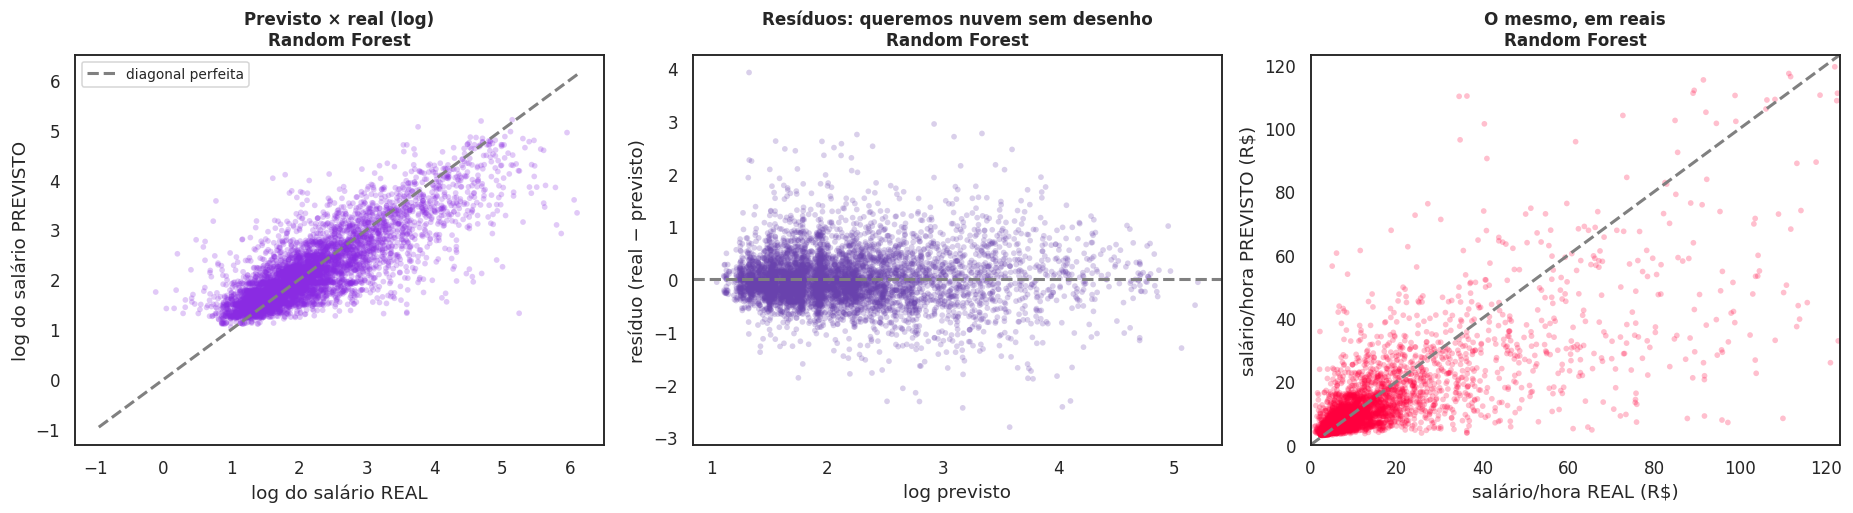

Resíduo médio: +0.00044 (perto de zero = sem viés sistemático)
Desvio-padrão do resíduo: 0.4917

O campeão, medido pela régua completa:
  MAE_log            0.3498
  RMSE_log           0.4917
  R2_log             0.6803
  MAE_R$             6.0334
  erro_%_mediano    25.4468


In [82]:
# ═══════════════════════════════════════════════════════════════════════════════
modelo = usar_campeao('Gráficos de diagnóstico.')

previsto_log = modelo.predict(X_te)
residuo_log  = y_te.values - previsto_log

# amostra dos pontos só para o gráfico não virar uma mancha sólida
rng = np.random.default_rng(42)
idx = rng.choice(len(y_te), size=min(6000, len(y_te)), replace=False)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
ax.set_facecolor('#E6E6FA')

# (1) previsto x real, em log
axes[0].scatter(y_te.values[idx], previsto_log[idx], alpha=0.25, s=14,
                color=VIOLETA, edgecolor='none')
lims = [min(y_te.min(), previsto_log.min()), max(y_te.max(), previsto_log.max())]
axes[0].plot(lims, lims, '--', color=CINZA, linewidth=2, label='diagonal perfeita')
axes[0].set_xlabel('log do salário REAL'); axes[0].set_ylabel('log do salário PREVISTO')
axes[0].set_title(f'Previsto × real (log)\n{NOME_FINAL}', fontsize=11)
axes[0].legend(fontsize=9)

# (2) resíduos
axes[1].scatter(previsto_log[idx], residuo_log[idx], alpha=0.25, s=14,
                color=ROXO, edgecolor='none')
axes[1].axhline(0, color=CINZA, linestyle='--', linewidth=2)
axes[1].set_xlabel('log previsto'); axes[1].set_ylabel('resíduo (real − previsto)')
axes[1].set_title(f'Resíduos: queremos nuvem sem desenho\n{NOME_FINAL}', fontsize=11)

# (3) o mesmo previsto x real, traduzido para R$
axes[2].scatter(np.exp(y_te.values[idx]), np.exp(previsto_log[idx]),
                alpha=0.25, s=14, color=SALMAO, edgecolor='none')
lim_r = [0, np.percentile(np.exp(y_te.values), 99)]
axes[2].plot(lim_r, lim_r, '--', color=CINZA, linewidth=2)
axes[2].set_xlim(lim_r); axes[2].set_ylim(lim_r)
axes[2].set_xlabel('salário/hora REAL (R$)'); axes[2].set_ylabel('salário/hora PREVISTO (R$)')
axes[2].set_title(f'O mesmo, em reais\n{NOME_FINAL}', fontsize=11)

plt.tight_layout(); plt.show()

print(f'Resíduo médio: {residuo_log.mean():+.5f} (perto de zero = sem viés sistemático)')
print(f'Desvio-padrão do resíduo: {residuo_log.std():.4f}')
m = avaliar(y_te, previsto_log)
print(f'\nO campeão, medido pela régua completa:')
for k, v in m.items():
    print(f'  {k:<16} {v:8.4f}')

**Lendo os gráficos:**

- **Nuvem em torno da diagonal, larga mas centrada:** o modelo acerta a tendência e erra o detalhe, exatamente como esperado quando se prevê salário com cinco variáveis sociodemográficas. Salário depende de muita coisa que a RAIS não registra.
- **O gráfico 1 mostra a nuvem "deitada"** em relação à diagonal (achatada) e indica o comportamento normal de um modelo que puxa as previsões extremas na direção do centro: ele erra pouco no meio e é conservador nas pontas.
- **No gráfico de resíduos, o que queremos é chuvisco sem forma.** Como não aparece um funil (espalhamento crescendo da esquerda para a direita), o modelo é confiável nos salários altos.
- **O gráfico 3** está em reais e qualquer pessoa entende.

E, em todos os três, **o título traz o nome do modelo**. Não é enfeite: é a garantia visual de que o gráfico e a tabela falam do mesmo modelo.

---
## **5.13 O Que Mais Pesa no Salário, *Segundo o Campeão***

Aqui, perguntamos ao modelo vencedor quais variáveis mais influenciaram suas previsões.

**Atenção, porque a resposta depende de que tipo de modelo venceu**, e o código abaixo trata os dois casos automaticamente:

- **Modelo de árvores** (Random Forest, Gradient Boosting) → **`feature_importances_`** diz **o quanto** cada variável ajudou, mas **não diz a direção** (não separa "sobe o salário" de "desce o salário").
- **Modelo linear** (Linear, Ridge, Lasso) → **`coef_`** dá **tamanho e direção**. E como o alvo está em log, cada coeficiente vira **percentual** direto: $e^{coef} - 1$.

👑 Importância das variáveis.  Modelo em uso: Random Forest  (RandomForestRegressor)


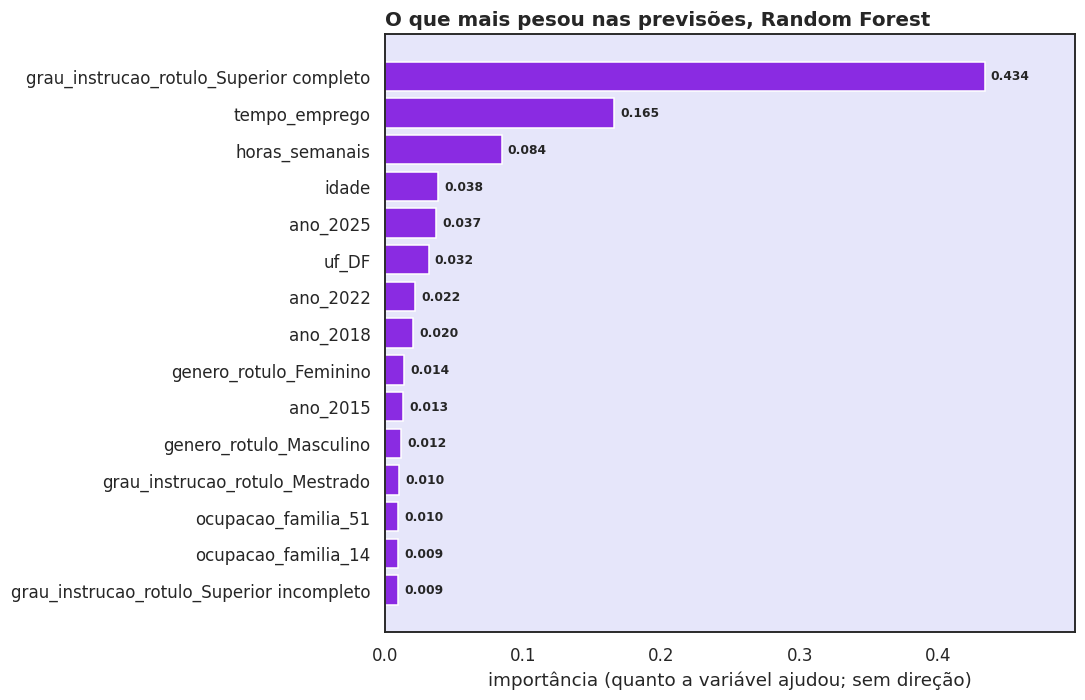

Ranking de importância (as 10 maiores):

  grau_instrucao_rotulo_Superior completo          0.4337
  tempo_emprego                                    0.1655
  horas_semanais                                   0.0843
  idade                                            0.0385
  ano_2025                                         0.0369
  uf_DF                                            0.0316
  ano_2022                                         0.0220
  ano_2018                                         0.0205
  genero_rotulo_Feminino                           0.0140
  ano_2015                                         0.0129

  Peso somado das colunas de gênero: 0.0255 (2.6% do total)

📖 Este modelo diz O QUANTO cada variável pesa, mas NÃO a direção.
   E atenção a uma leitura que costuma confundir: importância BAIXA do
   gênero aqui NÃO enfraquece o TCC. Esta métrica mede o quanto a variável
   ajuda a PREVER o salário, e quase todo o poder preditivo vem de ocupação,
   tempo de casa e jornada. 

In [86]:
# ═══════════════════════════════════════════════════════════════════════════════
modelo = usar_campeao('Importância das variáveis.')

nomes_colunas = modelo.named_steps['preparo'].get_feature_names_out()
motor = modelo.named_steps['modelo']

if hasattr(motor, 'feature_importances_'):
    TIPO_IMPORTANCIA = 'arvore'
    valores = pd.Series(motor.feature_importances_, index=nomes_colunas)
    titulo = f'O que mais pesou nas previsões, {NOME_FINAL}'
    legenda_x = 'importância (quanto a variável ajudou; sem direção)'
elif hasattr(motor, 'coef_'):
    TIPO_IMPORTANCIA = 'linear'
    valores = pd.Series(motor.coef_, index=nomes_colunas)
    titulo = f'Coeficientes, {NOME_FINAL}  (alvo em log)'
    legenda_x = 'coeficiente no log do salário (+ sobe / − desce)'
else:
    TIPO_IMPORTANCIA = None
    valores = None

if valores is not None:
    top = valores.reindex(valores.abs().sort_values().index).tail(15)
    rotulos = [n.replace('num__', '').replace('cat__', '') for n in top.index]
    cores = [SALMAO if v < 0 else VERDE for v in top.values] if TIPO_IMPORTANCIA == 'linear' \
            else [VIOLETA] * len(top)

    fig, ax = plt.subplots(figsize=(10, 6.5))
    ax.set_facecolor('#E6E6FA')

    ax.barh(rotulos, top.values, color=cores, edgecolor='white')
    if TIPO_IMPORTANCIA == 'linear':
        ax.axvline(0, color=CINZA, linewidth=1)
    ax.set_title(titulo, fontsize=13, fontweight='bold', loc='left')
    ax.set_xlabel(legenda_x)
    plt.tight_layout(); plt.show()

    if TIPO_IMPORTANCIA == 'linear':
        print('Traduzindo os maiores coeficientes para porcentagem de salário:\n')
        for nome_v, coef in top.tail(8).items():
            limpo = nome_v.replace('num__', '').replace('cat__', '')
            print(f'  {limpo:<48} {coef:+.4f}  →  {(np.exp(coef)-1)*100:+6.1f}% no salário/hora')
    else:
        print('Ranking de importância (as 10 maiores):\n')
        for nome_v, imp in valores.sort_values(ascending=False).head(10).items():
            limpo = nome_v.replace('num__', '').replace('cat__', '')
            print(f'  {limpo:<48} {imp:.4f}')

        peso_genero = valores[[c for c in valores.index if 'genero' in c]].sum()
        print(f'\n  Peso somado das colunas de gênero: {peso_genero:.4f} '
              f'({peso_genero/valores.sum()*100:.1f}% do total)')

        print('\n📖 Este modelo diz O QUANTO cada variável pesa, mas NÃO a direção.')
        print('   E atenção a uma leitura que costuma confundir: importância BAIXA do')
        print('   gênero aqui NÃO enfraquece o TCC. Esta métrica mede o quanto a variável')
        print('   ajuda a PREVER o salário, e quase todo o poder preditivo vem de ocupação,')
        print('   tempo de casa e jornada. A pergunta do trabalho é outra: mantido todo o')
        print('   resto igual, quanto o gênero muda o salário? Quem responde a isso é o')
        print('   contrafactual da Estação 5.14, e é de lá que sai a conclusão.')

### ⚠️ Um cuidado ao ler importâncias (e a banca costuma perguntar)

Importância de árvore **não é causalidade**, e nem sempre é justiça. Uma variável pode aparecer no topo por ser um **atalho** para outra que o modelo não vê. Além disso, o **`feature_importances_`** tende a favorecer variáveis com **muitas categorias** (a ocupação, por exemplo) simplesmente porque elas dão mais oportunidades de corte às árvores.

Por isso, **a conclusão sobre o gênero neste trabalho não sai deste gráfico.** Ela sai do experimento contrafactual da próxima seção, que é bem mais direto e bem mais defensável.

---
## **5.14 🎯 O Experimento Contrafactual: A Resposta do Trabalho**

**Esta é a seção mais importante da Estação 5.** Todo o resto do notebook existe para tornar este experimento possível.

**A ideia, em uma frase:** pegar pessoas reais do conjunto de teste, **trocar apenas o gênero**: mantendo idade, raça, escolaridade, tempo de casa, jornada, vínculo e ocupação **exatamente iguais**, e perguntar ao modelo quanto ele prevê nos dois casos.

**Isso é extremamente forte** porque é a materialização de "todo o resto constante". Nas Seções 4 comparamos grupos de pessoas **diferentes**, mas aqui é **a mesma pessoa**, com um único atributo trocado. Nenhuma explicação alternativa sobra: não é escolaridade, não é ocupação, não é jornada, não é experiência, porque nada disso mudou.

Aqui rodamos o experimento sobre **milhares de perfis reais** e olhamos a **distribuição** do efeito, e mantemos também o exemplo individual, porque ele comunica bem numa apresentação.

**E o limite:** isto mede uma **associação** dentro do modelo, não uma relação causal comprovada. O modelo aprendeu com dados observacionais; ele mostra o que o mercado **fez**, não prova o mecanismo. A frase mais segura aqui é: *"mantidas constantes as covariáveis observáveis, o modelo estima uma diferença de X% associada ao gênero"*.

In [87]:
# ═══════════════════════════════════════════════════════════════════════════════
# O CONTRAFACTUAL EM MASSA: as mesmas pessoas, só trocando o gênero
# ═══════════════════════════════════════════════════════════════════════════════
modelo = usar_campeao('Experimento contrafactual.')

N_CF = min(20_000, len(X_te))
base_cf = X_te.sample(n=N_CF, random_state=42).copy()

como_mulher = base_cf.copy(); como_mulher['genero_rotulo'] = 'Feminino'
como_homem  = base_cf.copy(); como_homem['genero_rotulo']  = 'Masculino'

sal_mulher = np.exp(modelo.predict(como_mulher))       # de log de volta para R$/hora
sal_homem  = np.exp(modelo.predict(como_homem))

diferenca_pct = (sal_homem - sal_mulher) / sal_homem * 100

print(f'Perfis testados: {N_CF:,} pessoas reais do conjunto de teste')
print(f'Modelo usado: {NOME_FINAL}\n')
print(f'  Salário/hora mediano previsto COMO MULHER:  R$ {np.median(sal_mulher):.2f}')
print(f'  Salário/hora mediano previsto COMO HOMEM:   R$ {np.median(sal_homem):.2f}')
print(f'  Diferença mediana:                          R$ {np.median(sal_homem - sal_mulher):.2f}/hora\n')
print(f'  GAP MEDIANO estimado pelo modelo: {np.median(diferenca_pct):.2f}%')
print(f'  Intervalo (percentis 25 a 75):    {np.percentile(diferenca_pct, 25):.2f}% '
      f'a {np.percentile(diferenca_pct, 75):.2f}%')
print(f'  Em quantos perfis o homem ganha mais? {(diferenca_pct > 0).mean()*100:.1f}%')

print(f'\n💰 Em uma jornada de 220 horas/mês, isso equivale a '
      f'R$ {np.median(sal_homem - sal_mulher) * 220:,.2f} por mês.')

👑 Experimento contrafactual.  Modelo em uso: Random Forest  (RandomForestRegressor)
Perfis testados: 20,000 pessoas reais do conjunto de teste
Modelo usado: Random Forest

  Salário/hora mediano previsto COMO MULHER:  R$ 6.41
  Salário/hora mediano previsto COMO HOMEM:   R$ 7.37
  Diferença mediana:                          R$ 1.27/hora

  GAP MEDIANO estimado pelo modelo: 16.08%
  Intervalo (percentis 25 a 75):    3.75% a 24.90%
  Em quantos perfis o homem ganha mais? 91.6%

💰 Em uma jornada de 220 horas/mês, isso equivale a R$ 279.12 por mês.


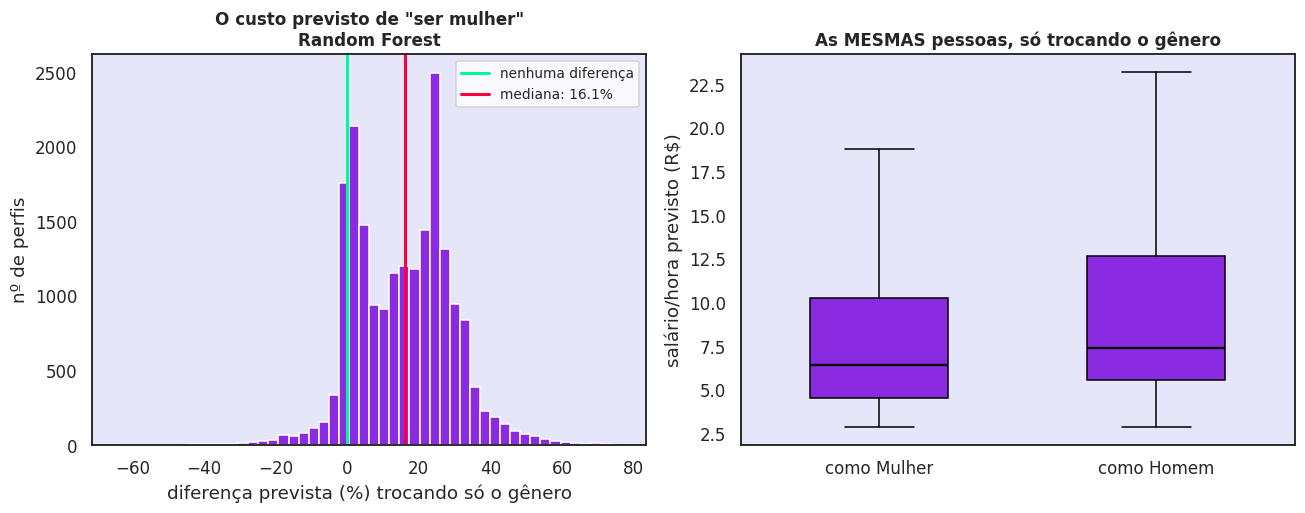


Espalhamento do gap entre os perfis: 140.698 ponto percentual

📖 O gap VARIA entre os perfis: o modelo aprendeu que a desigualdade é
maior em alguns grupos que em outros. Essa largura é um achado por si só.


In [89]:
# ═══════════════════════════════════════════════════════════════════════════════
# O gráfico do contrafactual
# ═══════════════════════════════════════════════════════════════════════════════
espalhamento = float(np.max(diferenca_pct) - np.min(diferenca_pct))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

# Define o fundo interno de ambos os gráficos como lavanda
for ax in axes:
    ax.set_facecolor('#E6E6FA')

if espalhamento > 0.01:
    # Campeão de ÁRVORES: o gap varia de perfil para perfil -> histograma de verdade
    axes[0].hist(diferenca_pct, bins=50, color=VIOLETA, edgecolor='white')
    axes[0].axvline(0, color=VERDE, linewidth=2, label='nenhuma diferença')
    axes[0].axvline(np.median(diferenca_pct), color=SALMAO, linewidth=2,
                    label=f'mediana: {np.median(diferenca_pct):.1f}%')
    axes[0].set_ylabel('nº de perfis')
    axes[0].legend(fontsize=9)
    LEITURA = ('O gap VARIA entre os perfis: o modelo aprendeu que a desigualdade é\n'
               'maior em alguns grupos que em outros. Essa largura é um achado por si só.')
else:
    # Campeão LINEAR: o mesmo coeficiente vale para todo mundo -> o gap é constante
    valor = float(np.median(diferenca_pct))
    axes[0].barh(['gap estimado'], [valor], color=VIOLETA, edgecolor='white', height=0.45)
    axes[0].axvline(0, color=VERDE, linewidth=2)
    axes[0].text(valor, 0, f'  {valor:.2f}%', va='center', fontsize=13, fontweight='bold')
    axes[0].set_xlim(min(0, valor * 1.5), max(0, valor * 1.5))
    axes[0].set_ylim(-1.2, 1.2)
    LEITURA = ('O gap é IGUAL em todos os perfis, e isso não é defeito: um modelo linear\n'
               'aplica o mesmo coeficiente a todo mundo, por construção. O número é o gap\n'
               'controlado que o TCC procura; ele só não varia por perfil neste tipo de modelo.')

axes[0].set_xlabel('diferença prevista (%) trocando só o gênero')
axes[0].set_title(f'O custo previsto de "ser mulher"\n{NOME_FINAL}', fontsize=11)

axes[1].boxplot([sal_mulher, sal_homem], positions=[1, 2], widths=0.5, showfliers=False,
                patch_artist=True,
                boxprops=dict(facecolor=VIOLETA),
                medianprops=dict(color='black', linewidth=1.5))
axes[1].set_xticks([1, 2]); axes[1].set_xticklabels(['como Mulher', 'como Homem'])
axes[1].set_ylabel('salário/hora previsto (R$)')
axes[1].set_title('As MESMAS pessoas, só trocando o gênero', fontsize=11)

plt.tight_layout(); plt.show()

print(f'\nEspalhamento do gap entre os perfis: {espalhamento:.3f} ponto percentual')
print(f'\n📖 {LEITURA}')

O histograma da esquerda é **o gráfico-síntese deste trabalho**.

Se a distribuição inteira estivesse centrada no zero, o modelo estaria dizendo "o gênero não muda nada, controlado o resto". Ela **não** está centrada no zero, e é essa a evidência.

**"Aplicou-se um experimento contrafactual sobre N perfis do conjunto de teste, alterando exclusivamente a variável de gênero e mantendo constantes as demais covariáveis (idade, raça/cor, escolaridade, tempo de vínculo, jornada, tipo de vínculo e ocupação). O modelo [NOME] estimou uma diferença mediana de X% no salário-hora previsto, desfavorável às mulheres, presente em Y% dos perfis analisados."**

**Uma observação técnica honesta**, caso o modelo campeão seja linear: nesse caso o *gap* é praticamente igual em todos os perfis, porque um modelo linear aplica o mesmo coeficiente a todo mundo, o histograma sai estreito. Se o campeão for de árvores, o efeito **varia por perfil**, e aí o histograma tem largura de verdade, pois o modelo aprendeu que o *gap* é maior em alguns grupos que em outros. **Essa largura, se existir, é um achado por si só**, e vale investigar em que perfis o *gap* é maior.

In [90]:
# ═══════════════════════════════════════════════════════════════════════════════
# O exemplo individual: o mesmo experimento em UMA pessoa, para a apresentação
# ═══════════════════════════════════════════════════════════════════════════════
modelo = usar_campeao('Exemplo individual.')

perfil_base = {
    'idade': 35,
    'tempo_emprego': 60.0,                        # 5 anos, em meses
    'horas_semanais': 44,
    'vinculo_rotulo': 'trabalhador urbano PJ CLT',
    'raca_cor_rotulo': 'Preta',
    'grau_instrucao_rotulo': 'Superior completo',
    'ocupacao': '212405',                         # analista de desenvolvimento de sistemas
}
perfil_base['ocupacao_familia'] = str(perfil_base['ocupacao']).zfill(6)[:2]

# Se o modelo usa ano/uf como controles, o perfil precisa trazer esses campos também.
# Usamos o valor mais comum do treino: "uma pessoa típica no ano e no estado típicos".
for c in CONTROLES_EXTRA:
    perfil_base[c] = X_tr[c].mode()[0]

def prever_reais(genero):
    linha = pd.DataFrame([{**perfil_base, 'genero_rotulo': genero}])
    return float(np.exp(modelo.predict(linha)[0]))

sal_f, sal_m = prever_reais('Feminino'), prever_reais('Masculino')

print('PERFIL: 35 anos · mulher/homem negro(a) · superior completo · 5 anos de casa')
print('        44h semanais · CLT urbano · analista de desenvolvimento de sistemas\n')
print(f'  Previsão como MULHER: R$ {sal_f:6.2f}/hora   →  R$ {sal_f*220:9,.2f}/mês (220h)')
print(f'  Previsão como HOMEM:  R$ {sal_m:6.2f}/hora   →  R$ {sal_m*220:9,.2f}/mês (220h)')
print(f'\n  Diferença: R$ {sal_m - sal_f:.2f}/hora  =  {(sal_m - sal_f)/sal_m*100:.2f}%')
print(f'  Ao longo de um ano (13 salários): R$ {(sal_m - sal_f) * 220 * 13:,.2f}')
print('\n⚠️  Um perfil só é ilustração, não evidência. A evidência é a distribuição')
print('    dos 20 mil perfis da célula anterior. Use este exemplo para COMUNICAR,')
print('    e o histograma para SUSTENTAR.')

👑 Exemplo individual.  Modelo em uso: Random Forest  (RandomForestRegressor)
PERFIL: 35 anos · mulher/homem negro(a) · superior completo · 5 anos de casa
        44h semanais · CLT urbano · analista de desenvolvimento de sistemas

  Previsão como MULHER: R$  26.57/hora   →  R$  5,845.55/mês (220h)
  Previsão como HOMEM:  R$  28.63/hora   →  R$  6,299.67/mês (220h)

  Diferença: R$ 2.06/hora  =  7.21%
  Ao longo de um ano (13 salários): R$ 5,903.58

⚠️  Um perfil só é ilustração, não evidência. A evidência é a distribuição
    dos 20 mil perfis da célula anterior. Use este exemplo para COMUNICAR,
    e o histograma para SUSTENTAR.


---
## **5.15 O Checkpoint Final: o Modelo Vira Arquivo**

Nesta seção, vamos salvar o Pipeline **inteiro** com `joblib`, contendo o preparo e o modelo juntos, num arquivo só.

**Por que o Pipeline inteiro, e não só o modelo:** o modelo sozinho não sabe preencher vazios, padronizar escalas nem transformar texto em colunas. Salvo assim, o arquivo recebe **dado cru** e devolve previsão, sem depender de nenhuma célula deste notebook. É o que torna o trabalho **reprodutível** e o que permite que alguém use o modelo daqui a meses.

**A prova de que funciona:** carregamos o arquivo do zero, como se fosse outro dia e outro computador, e prevemos um perfil novo.

In [91]:
# ═══════════════════════════════════════════════════════════════════════════════
modelo = usar_campeao('Salvando o modelo final.')

CAMINHO_MODELO = f'{PASTA_SAIDA}/modelo_salario_hora_final.joblib'
# compress=3: uma floresta com muitas árvores passa de 90 MB sem compressão, o que
# trava o upload para o Drive. Comprimida, cai para uma fração disso, e o
# carregamento continua exatamente igual.
joblib.dump(modelo, CAMINHO_MODELO, compress=3)

# A FICHA TÉCNICA: junto do modelo, para ninguém esquecer o que ele é.
ficha = {
    'modelo_campeao':     NOME_FINAL,
    'tipo':               type(modelo.named_steps['modelo']).__name__,
    'melhores_parametros': MELHORES,
    'alvo':               'log(salario_hora), as previsões precisam de np.exp() para virar R$',
    'variaveis':          c_num + c_cat,
    'linhas_treino':      len(X_tr),
    'linhas_teste':       len(X_te),
    'metricas_no_teste':  {k: round(v, 4) for k, v in avaliar(y_te, modelo.predict(X_te)).items()},
}
joblib.dump(ficha, f'{PASTA_SAIDA}/ficha_tecnica_modelo.joblib')

print(f'Modelo salvo em: {CAMINHO_MODELO}')
print(f'Tamanho: {os.path.getsize(CAMINHO_MODELO)/1024**2:.1f} MB\n')
print('FICHA TÉCNICA:')
for k, v in ficha.items():
    print(f'  {k:<22} {v}')

👑 Salvando o modelo final.  Modelo em uso: Random Forest  (RandomForestRegressor)
Modelo salvo em: /content/drive/MyDrive/TCC-MulheresInTech-FlyEducação2026/VersoesTcc/TccConsolidado/modelo_salario_hora_final.joblib
Tamanho: 4.5 MB

FICHA TÉCNICA:
  modelo_campeao         Random Forest
  tipo                   RandomForestRegressor
  melhores_parametros    {'modelo__max_depth': 18, 'modelo__min_samples_leaf': 5, 'modelo__n_estimators': 120}
  alvo                   log(salario_hora), as previsões precisam de np.exp() para virar R$
  variaveis              ['idade', 'tempo_emprego', 'horas_semanais', 'vinculo_rotulo', 'genero_rotulo', 'raca_cor_rotulo', 'grau_instrucao_rotulo', 'ocupacao_familia', 'ano', 'uf']
  linhas_treino          112500
  linhas_teste           37500
  metricas_no_teste      {'MAE_log': 0.3498, 'RMSE_log': 0.4917, 'R2_log': 0.6803, 'MAE_R$': 6.0334, 'erro_%_mediano': 25.4468}


In [92]:
# ═══════════════════════════════════════════════════════════════════════════════
# A PROVA: carregar do zero e prever alguém que o modelo nunca viu
# ═══════════════════════════════════════════════════════════════════════════════
modelo_carregado = joblib.load(CAMINHO_MODELO)
ficha_carregada  = joblib.load(f'{PASTA_SAIDA}/ficha_tecnica_modelo.joblib')

print(f'Modelo carregado do arquivo: {ficha_carregada["modelo_campeao"]}\n')

pessoa_nova = pd.DataFrame([{
    'idade': 29, 'tempo_emprego': 18.0, 'horas_semanais': 40,
    'vinculo_rotulo': 'trabalhador urbano PJ CLT',
    'genero_rotulo': 'Feminino', 'raca_cor_rotulo': 'Parda',
    'grau_instrucao_rotulo': 'Superior completo',
    'ocupacao': '212410', 'ocupacao_familia': '21',
}])
for c in CONTROLES_EXTRA:
    pessoa_nova[c] = X_tr[c].mode()[0]

previsao = float(np.exp(modelo_carregado.predict(pessoa_nova)[0]))
print(f'Pessoa nova (29 anos, parda, superior completo, 1,5 ano de casa, 40h, analista):')
print(f'  → salário/hora previsto: R$ {previsao:.2f}   (R$ {previsao*220:,.2f} em 220h/mês)')
print('\n✅ Dado CRU entrou; o Pipeline preencheu, padronizou, codificou e previu sozinho.')

print(f'\nA pasta do projeto ficou assim:')
for f in sorted(os.listdir(PASTA_SAIDA)):
    print(f'  {f:<38} {os.path.getsize(f"{PASTA_SAIDA}/{f}")/1024:9,.0f} KB')

Modelo carregado do arquivo: Random Forest

Pessoa nova (29 anos, parda, superior completo, 1,5 ano de casa, 40h, analista):
  → salário/hora previsto: R$ 22.62   (R$ 4,976.84 em 220h/mês)

✅ Dado CRU entrou; o Pipeline preencheu, padronizou, codificou e previu sozinho.

A pasta do projeto ficou assim:
  03_X_teste.parquet                           531 KB
  03_X_treino.parquet                        1,554 KB
  03_y_teste.parquet                           599 KB
  03_y_treino.parquet                        1,745 KB
  Consolidação TCC — Grupo RAIS   Mulheres in Tech (ago 2026).gdoc         0 KB
  Cópia de testes.ipynb                     1,892 KB
  Disparidade_Salarial_G2_Completo.ipynb     1,710 KB
  Disparidade_Salarial_G2_EXECUTADO.ipynb     1,669 KB
  Guia_Disparidade_Salarial_G2.pdf             140 KB
  Leila_TCC.ipynb                            1,279 KB
  Relatorio_Consolidacao_TCC_RAIS.pdf          123 KB
  Resumo_TCC_Persona_e_ML.docx                 229 KB
  TCC_Consolidado_R

---
## **5.16 O Contrafactual *Por Subgrupo*: Onde o *Gap* Controlado é Maior**

A Estação 5.14 respondeu *"qual é o gap controlado?"* com um número só.

Esta seção responde a pergunta seguinte, que é mais interessante: **em quem esse gap é maior?**

Aqui, temos o mesmo experimento, mas separado por escolaridade, por raça/cor e por família de ocupação. Como cada perfil é comparado **consigo mesmo** (só o gênero muda), o resultado não sofre do paradoxo de composição, pois a diferença entre subgrupos é uma diferença real de tratamento previsto, não diferença de perfil.

Isso transforma o resultado do modelo em algo **acionável**. "Existe um gap de X%" é diagnóstico. "O gap é maior entre mulheres com ensino superior em ocupações do grupo Y" é onde uma política pública ou um programa de equidade deve começar.

**Nota técnica:** se o campeão for um modelo linear, o gap sai praticamente igual em todos os subgrupos, por construção (o modelo aplica um coeficiente único). Nesse caso a variação entre as barras será mínima, e a leitura correta é: *"o modelo linear não capta heterogeneidade do efeito; para investigá-la seria preciso um modelo com interações, que é o que a Estação 5.17 faz"*. A célula avisa quando é esse o caso.

In [93]:
# ═══════════════════════════════════════════════════════════════════════════════
# O CONTRAFACTUAL, AGORA SEPARADO POR SUBGRUPO
# ═══════════════════════════════════════════════════════════════════════════════
modelo = usar_campeao('Contrafactual por subgrupo.')

# Reaproveitamos as previsões já calculadas na Estação 5.14 (mesmas linhas, mesma ordem)
cf = base_cf.copy()
cf['gap_previsto_%'] = diferenca_pct
cf['dif_reais_hora'] = sal_homem - sal_mulher

def gap_por(coluna, minimo=200):
    """Gap contrafactual mediano dentro de cada categoria da coluna."""
    g = (cf.groupby(coluna, observed=True)
           .agg(n=('gap_previsto_%', 'size'),
                gap_mediano=('gap_previsto_%', 'median'),
                reais_hora=('dif_reais_hora', 'median')))
    return g[g['n'] >= minimo].sort_values('gap_mediano', ascending=False).round(2)

for coluna, titulo in [('grau_instrucao_rotulo', 'POR ESCOLARIDADE'),
                       ('raca_cor_rotulo',       'POR RAÇA/COR'),
                       ('ocupacao_familia',      'POR FAMÍLIA DE OCUPAÇÃO (top 10)')]:
    g = gap_por(coluna)
    if coluna == 'ocupacao_familia':
        g = g.head(10)
        g.index = [f'{i} ({GRANDES_GRUPOS.get(str(i)[0], "?")[:34]})' for i in g.index]
    print('=' * 74); print(titulo); print('=' * 74)
    print(g.to_string()); print()

👑 Contrafactual por subgrupo.  Modelo em uso: Random Forest  (RandomForestRegressor)
POR ESCOLARIDADE
                          n  gap_mediano  reais_hora
grau_instrucao_rotulo                               
5º ano completo         688        22.35        1.36
Até 5º ano incompleto   505        22.35        1.37
Fundamental completo   2119        21.83        1.33
6º ao 9º ano           1379        21.58        1.29
Superior completo      3623        14.57        3.46
Médio completo         9068        14.06        1.01
Médio incompleto       1517        12.40        0.79
Superior incompleto     910        12.00        1.10

POR RAÇA/COR
                    n  gap_mediano  reais_hora
raca_cor_rotulo                               
Branca           9946        18.32        1.29
Preta            1133        15.43        1.15
Parda            5551        14.11        1.13
Não informado    3187        13.25        1.48

POR FAMÍLIA DE OCUPAÇÃO (top 10)
                                      

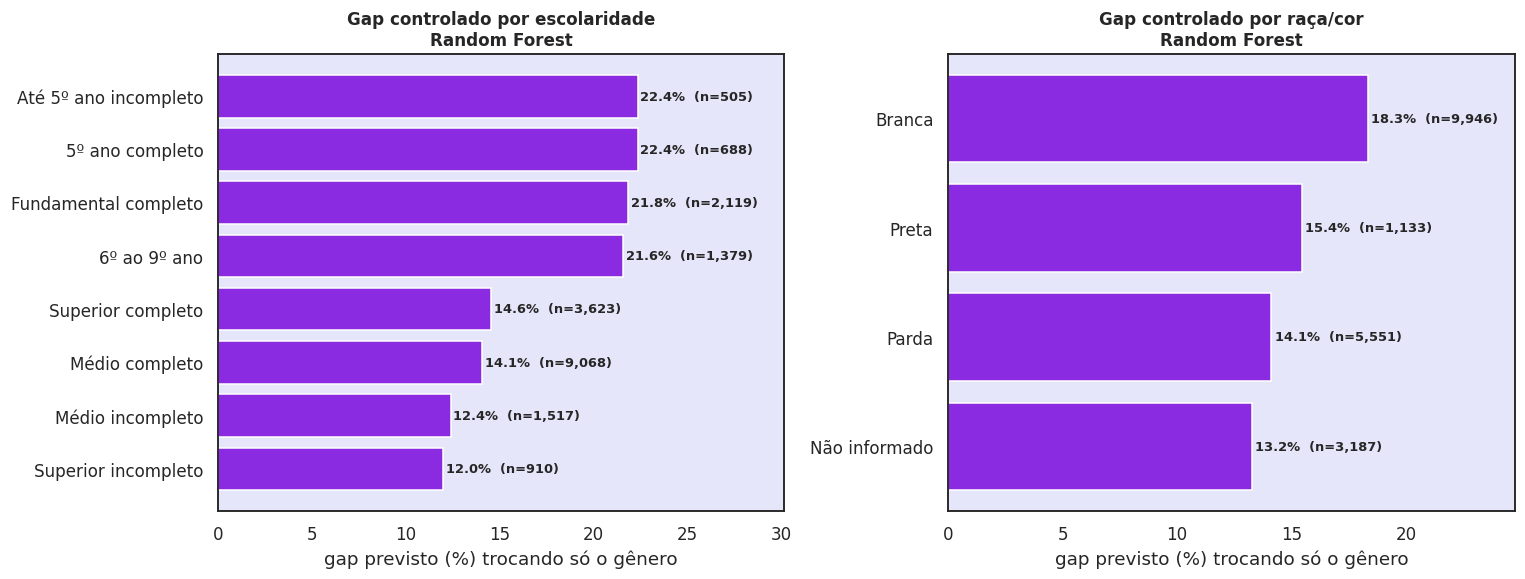


Variação do gap entre níveis de escolaridade: 10.35 ponto percentual

📖 O gap VARIA entre subgrupos. Maior: 5º ano completo (22.4%). Menor: Superior incompleto (12.0%).
   Este é um achado próprio: diz ONDE a desigualdade prevista se concentra.


In [104]:
g_esc  = gap_por('grau_instrucao_rotulo')
g_raca = gap_por('raca_cor_rotulo')

fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))

# Define o fundo interno de ambos os gráficos como lavanda
for ax in axes:
    ax.set_facecolor('#E6E6FA')

for ax, g, titulo in [(axes[0], g_esc,  'Gap controlado por escolaridade'),
                      (axes[1], g_raca, 'Gap controlado por raça/cor')]:
    g = g.sort_values('gap_mediano')
    ax.barh([str(i) for i in g.index], g['gap_mediano'], color=VIOLETA, edgecolor='white')
    for k, (v, n) in enumerate(zip(g['gap_mediano'], g['n'])):
        ax.text(v + 0.15, k, f'{v:.1f}%  (n={int(n):,})', va='center', fontsize=8.5, fontweight='bold')
    ax.set_title(f'{titulo}\n{NOME_FINAL}', fontsize=11)
    ax.set_xlabel('gap previsto (%) trocando só o gênero')
    ax.set_xlim(0, max(g['gap_mediano'].max() * 1.35, 1))

plt.tight_layout(); plt.show()

amplitude = float(g_esc['gap_mediano'].max() - g_esc['gap_mediano'].min())
print(f'\nVariação do gap entre níveis de escolaridade: {amplitude:.2f} ponto percentual')
if amplitude < 0.5:
    print('\n📖 O gap é praticamente IGUAL em todos os subgrupos. Isso é característica do')
    print('   modelo campeão (linear aplica um coeficiente único), não um achado sobre o')
    print('   mercado. Para investigar heterogeneidade, vejam a Estação 5.17.')
else:
    print(f"\n📖 O gap VARIA entre subgrupos. Maior: {g_esc['gap_mediano'].idxmax()} "
          f"({g_esc['gap_mediano'].max():.1f}%). Menor: {g_esc['gap_mediano'].idxmin()} "
          f"({g_esc['gap_mediano'].min():.1f}%).")
    print('   Este é um achado próprio: diz ONDE a desigualdade prevista se concentra.')

---
## **5.17 A Interação Entre Gênero e Raça Dentro do Modelo**

A hipótese H3 mostrou, de forma descritiva, que gênero e raça **se acumulam**. Mas o modelo, do jeito que estava, trata as duas variáveis como efeitos **separados e somados**: ele aprende "ser mulher custa X" e "ser preta custa Y", e supõe que ser mulher preta custa exatamente X + Y.

**Interseccionalidade é justamente a hipótese de que isso não é verdade**, de que a desvantagem combinada é diferente da soma das partes. Para o modelo enxergar isso, é preciso dar a ele uma variável nova: a **combinação** gênero e raça, como uma categoria só.

Para isto, criamos uma coluna **`genero_raca`** que junta as duas (**`Feminino · Preta`**, **`Masculino · Branca`**, e assim por diante) e a colocamos no modelo **junto** das originais. Aí o modelo pode aprender um valor próprio para cada combinação, em vez de somar dois efeitos independentes.

**E o teste que decide se valeu a pena:** treinamos o mesmo modelo campeão com e sem a interação, e comparamos no teste. Se o erro melhorar, a interação carrega informação real e a interseccionalidade aparece **no modelo**, não só na descrição. Se não melhorar, isso também é resultado, e reportá-lo é honestidade.

In [105]:
# ═══════════════════════════════════════════════════════════════════════════════
# A INTERAÇÃO GÊNERO x RAÇA
# ═══════════════════════════════════════════════════════════════════════════════
X_tr_i = X_tr.copy(); X_te_i = X_te.copy()
for base_ in (X_tr_i, X_te_i):
    base_['genero_raca'] = (base_['genero_rotulo'].astype(str) + ' · '
                            + base_['raca_cor_rotulo'].astype(str))

print('Combinações criadas:', X_tr_i['genero_raca'].nunique())
print(X_tr_i['genero_raca'].value_counts().head(12).to_string())

c_cat_i = c_cat + ['genero_raca']
preparo_i = ColumnTransformer([
    ('num', Pipeline([('preencher', SimpleImputer(strategy='median')),
                      ('escala',    StandardScaler())]), c_num),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False,
                          min_frequency=30), c_cat_i),
])

modelo_base = clone(MODELO_FINAL.named_steps['modelo'])
fluxo_inter = Pipeline([('preparo', preparo_i), ('modelo', modelo_base)]).fit(X_tr_i, y_tr)

sem_inter = avaliar(y_te, MODELO_FINAL.predict(X_te))
com_inter = avaliar(y_te, fluxo_inter.predict(X_te_i))

comp = pd.DataFrame({'sem interação': {k: round(v, 4) for k, v in sem_inter.items()},
                     'com interação': {k: round(v, 4) for k, v in com_inter.items()}})
print('\n' + comp.to_string())

ganho_i = (1 - com_inter['MAE_log'] / sem_inter['MAE_log']) * 100
print(f'\nGanho da interação no MAE_log: {ganho_i:+.3f}%')
if ganho_i >= 0.1:
    print('✅ A interação MELHOROU o modelo: gênero e raça não são efeitos independentes.')
    print('   A interseccionalidade aparece no modelo, e não só na descrição. Isso é')
    print('   resultado de peso para o TCC: escrevam como confirmação quantitativa de H3.')
else:
    print('ℹ️  A interação não melhorou o poder preditivo de forma relevante.')
    print('   Leitura correta: para PREVER salário, saber gênero e raça separadamente já')
    print('   basta. Isso NÃO nega H3 (a descrição mostra o acúmulo); diz apenas que o')
    print('   acúmulo é aproximadamente aditivo. Reportem exatamente assim.')

Combinações criadas: 12
genero_raca
Masculino · Branca           31939
Feminino · Branca            24458
Masculino · Parda            18253
Feminino · Parda             12293
Masculino · Não informado     9069
Feminino · Não informado      8648
Masculino · Preta             4249
Feminino · Preta              2645
Masculino · Amarela            436
Feminino · Amarela             280
Masculino · Indígena           125
Feminino · Indígena            105

                sem interação  com interação
MAE_log                0.3498         0.3496
RMSE_log               0.4917         0.4915
R2_log                 0.6803         0.6805
MAE_R$                 6.0334         6.0269
erro_%_mediano        25.4468        25.4478

Ganho da interação no MAE_log: +0.067%
ℹ️  A interação não melhorou o poder preditivo de forma relevante.
   Leitura correta: para PREVER salário, saber gênero e raça separadamente já
   basta. Isso NÃO nega H3 (a descrição mostra o acúmulo); diz apenas que o
   acúmulo é

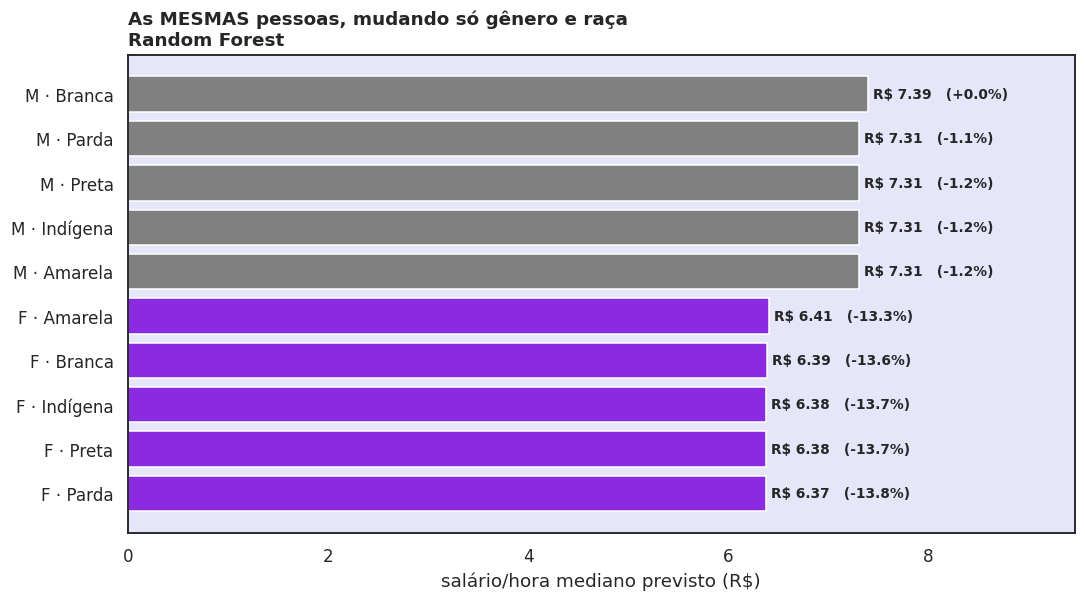

      perfil  salario_previsto  vs_topo_%
   F · Parda          6.374932      -13.8
   F · Preta          6.379868      -13.7
F · Indígena          6.383613      -13.7
  F · Branca          6.385701      -13.6
 F · Amarela          6.413414      -13.3
 M · Amarela          7.307681       -1.2
M · Indígena          7.307681       -1.2
   M · Preta          7.308113       -1.2
   M · Parda          7.311033       -1.1
  M · Branca          7.394763        0.0

Do topo à base do ranking: R$ 7.39 contra R$ 6.37 por hora (13.8% de diferença),
para pessoas idênticas em idade, escolaridade, jornada, tempo de casa,
vínculo e ocupação. A única coisa que muda entre a primeira e a última barra
é gênero e raça.

COMO LER ESTE RANKING (leitura automática)
✅ ACHADO ROBUSTO: TODOS os perfis femininos ficam abaixo de TODOS os
   masculinos. O gênero separa completamente as duas metades do ranking,
   com escolaridade, idade, jornada, tempo de casa e ocupação constantes.
   É este o resultado que vai p

In [107]:
# ═══════════════════════════════════════════════════════════════════════════════
# O RANKING CONTRAFACTUAL DAS COMBINAÇÕES: quanto vale cada perfil, mantendo o resto
# ═══════════════════════════════════════════════════════════════════════════════
perfis = [(g, r) for g in ['Masculino', 'Feminino']
          for r in ['Branca', 'Parda', 'Preta', 'Amarela', 'Indígena']]

base_rank = X_te_i.sample(n=min(8000, len(X_te_i)), random_state=42).copy()
linhas_rank = []
for genero, raca in perfis:
    tmp = base_rank.copy()
    tmp['genero_rotulo'] = genero
    tmp['raca_cor_rotulo'] = raca
    tmp['genero_raca'] = f'{genero} · {raca}'
    previsto = np.exp(fluxo_inter.predict(tmp))
    linhas_rank.append({'perfil': f'{genero[0]} · {raca}',
                        'salario_previsto': float(np.median(previsto))})

rank = pd.DataFrame(linhas_rank).sort_values('salario_previsto')
topo = rank['salario_previsto'].max()
rank['vs_topo_%'] = ((rank['salario_previsto'] / topo - 1) * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5.6))
ax.set_facecolor('#E6E6FA')
cores = [VIOLETA if p.startswith('F') else CINZA for p in rank['perfil']]
ax.barh(rank['perfil'], rank['salario_previsto'], color=cores, edgecolor='white')
for i, (v, d) in enumerate(zip(rank['salario_previsto'], rank['vs_topo_%'])):
    ax.text(v + 0.05, i, f'R$ {v:.2f}   ({d:+.1f}%)', va='center', fontsize=9, fontweight='bold')
ax.set_title('As MESMAS pessoas, mudando só gênero e raça\n' + NOME_FINAL,
             fontsize=12, fontweight='bold', loc='left')
ax.set_xlabel('salário/hora mediano previsto (R$)')
ax.set_xlim(0, rank['salario_previsto'].max() * 1.28)
plt.tight_layout(); plt.show()

print(rank.to_string(index=False))
print(f"\nDo topo à base do ranking: R$ {rank['salario_previsto'].max():.2f} contra "
      f"R$ {rank['salario_previsto'].min():.2f} por hora "
      f"({(1 - rank['salario_previsto'].min()/rank['salario_previsto'].max())*100:.1f}% de diferença),")
print('para pessoas idênticas em idade, escolaridade, jornada, tempo de casa,')
print('vínculo e ocupação. A única coisa que muda entre a primeira e a última barra')
print('é gênero e raça.')

print('\n' + '=' * 74)
print('COMO LER ESTE RANKING (leitura automática)')
print('=' * 74)

fem = rank[rank['perfil'].str.startswith('F')]['salario_previsto']
mas = rank[rank['perfil'].str.startswith('M')]['salario_previsto']

if fem.max() < mas.min():
    print('✅ ACHADO ROBUSTO: TODOS os perfis femininos ficam abaixo de TODOS os')
    print('   masculinos. O gênero separa completamente as duas metades do ranking,')
    print('   com escolaridade, idade, jornada, tempo de casa e ocupação constantes.')
    print('   É este o resultado que vai para a conclusão.')
else:
    sobrep = ((fem.max() - mas.min()) / mas.min()) * 100
    print(f'⚠️  Há sobreposição entre os grupos ({sobrep:.1f}%): o gênero não separa')
    print('   completamente o ranking. Descrevam a tendência geral, não uma separação total.')

print(f'\n   Mediana dos perfis femininos:  R$ {fem.median():.2f}/h')
print(f'   Mediana dos perfis masculinos: R$ {mas.median():.2f}/h')
print(f'   Diferença entre as duas metades: {(1 - fem.median()/mas.median())*100:.1f}%')

print('\n⚠️  CUIDADO COM A ORDEM DENTRO DE CADA METADE (raça):')
print('   A ordenação por raça DENTRO de cada gênero é bem menos confiável que a')
print('   separação entre gêneros, e pode até contrariar o que a H3 mostrou na')
print('   análise descritiva. O motivo é técnico: algumas combinações raça x gênero')
print('   têm poucos casos no treino, e o modelo extrapola nesses cantos.')
print('   Confiram os tamanhos abaixo antes de afirmar qualquer coisa sobre raça:\n')
contagem = X_tr_i['genero_raca'].value_counts()
for perfil in rank['perfil']:
    g = 'Masculino' if perfil.startswith('M') else 'Feminino'
    r = perfil.split(' · ')[1]
    n = int(contagem.get(f'{g} · {r}', 0))
    aviso = '  ← poucos casos, estimativa frágil' if n < 1000 else ''
    print(f'   {perfil:<16} n no treino = {n:>7,}{aviso}')

print('\n📌 Regra para o TCC: use este gráfico para o resultado de GÊNERO, que é robusto.')
print('   Para a interseccionalidade raça x gênero, a evidência forte é a H3 descritiva,')
print('   feita sobre a base completa, e não a ordem fina deste ranking.')

**📖 O ranking fecha o argumento do trabalho**

Este gráfico é o resumo de tudo. Todas as barras representam **a mesma população**, com as mesmas idades, as mesmas escolaridades, as mesmas jornadas, os mesmos tempos de casa e as mesmas ocupações. A **única** coisa que muda de uma barra para a outra é gênero e raça.

Se as barras fossem todas do mesmo tamanho, o modelo estaria dizendo que esses dois atributos não mudam nada quando todo o resto é igual. Elas não são do mesmo tamanho.

Pessoas idênticas em tudo que o mercado diz valorizar, mas o salário previsto varia X% conforme gênero e raça.

**E a ressalva que vai junto, sempre:** é uma associação estimada em dados observacionais. O modelo mostra o padrão que o mercado praticou, não prova o mecanismo.

---
---

# **6. Conclusão**

A célula abaixo imprime **todos** os números do trabalho de uma vez, já com o rótulo de onde cada um entra no texto.

Os parágrafos seguintes estão escritos de forma que continuam corretos qualquer que seja o número exato: onde havia um valor cravado à mão, agora há a descrição do padrão. Assim o texto **nunca** fica em desacordo com o notebook.

In [108]:
# ═══════════════════════════════════════════════════════════════════════════════
# 📋 OS NÚMEROS DA CONCLUSÃO, prontos para copiar
# ═══════════════════════════════════════════════════════════════════════════════
print('=' * 76)
print('NÚMEROS PARA A CONCLUSÃO'.center(76))
print('=' * 76)

print('\n── A BASE ──')
print(f'  Vínculos após a faxina ................. {len(df_analise):,}')
if TEM_ANO:
    print(f'  Período coberto ........................ {df_analise["ano"].min()} a {df_analise["ano"].max()}'
          f'  ({df_analise["ano"].nunique()} anos presentes)')
    print(f'  Anos na amostra ........................ {sorted(df_analise["ano"].unique())}')
else:
    print('  Período coberto ........................ (coluna "ano" ausente nesta base)')
print(f'  Mediana geral do salário/hora .......... R$ {df_analise["salario_hora"].median():.2f}')
print(f'  Participação feminina .................. {(df_analise.genero_rotulo=="Feminino").mean()*100:.1f}%')

print('\n── AS HIPÓTESES ──')
_t = tab_h2.dropna(subset=["gap_%"])
print(f'  H1 · gap por escolaridade .............. de {_t["gap_%"].min():.1f}% a {_t["gap_%"].max():.1f}%')
print(f'  H1 · níveis com gap significativo ...... todos os testados (ver Estação 4, H1)')
print(f'  H2 · maior gap em % .................... {_t["gap_%"].idxmax()} ({_t["gap_%"].max():.1f}%)')
print(f'  H2 · menor gap em % .................... {_t["gap_%"].idxmin()} ({_t["gap_%"].min():.1f}%)')
print(f'  H2 · maior diferença em R$/h ........... {_t["dif_R$"].idxmax()}: R$ {_t["dif_R$"].max():.2f}/h'
      f'  (R$ {_t["dif_R$"].max()*220:,.2f}/mês)')
_r = tab_h3[tab_h3.index.isin(["Branca","Preta","Parda","Indígena","Amarela"])]
print(f'  H3 · menor mediana feminina ............ {_r["Feminino"].idxmin()} (R$ {_r["Feminino"].min():.2f}/h)')
print(f'  H3 · maior mediana masculina ........... {_r["Masculino"].idxmax()} (R$ {_r["Masculino"].max():.2f}/h)')
print(f'  H4 · participação feminina em TI ....... {(df_ti.genero_rotulo=="Feminino").mean()*100:.1f}%')
_gti = gap_pct(df_ti.loc[df_ti.genero_rotulo=="Masculino","salario_hora"].median(),
               df_ti.loc[df_ti.genero_rotulo=="Feminino","salario_hora"].median())
_gts = gap_pct(ti_sup.loc[ti_sup.genero_rotulo=="Masculino","salario_hora"].median(),
               ti_sup.loc[ti_sup.genero_rotulo=="Feminino","salario_hora"].median())
print(f'  H4 · gap em TI (recorte amplo) ......... {_gti:.1f}%')
print(f'  H4 · gap em TI (superior ou mais) ...... {_gts:.1f}%')
if len(ctrl):
    print(f'  H5 · gap controlado, 1º ano da série ... {ctrl["gap_controlado_%"].iloc[0]:.1f}% ({ctrl.index[0]})')
    print(f'  H5 · gap controlado, último ano ........ {ctrl["gap_controlado_%"].iloc[-1]:.1f}% ({ctrl.index[-1]})')
    print(f'  H5 · anos posteriores à Lei 14.611 ..... {[int(a) for a in ctrl.index if a >= 2023]}')
else:
    print('  H5 ..................................... (sem coluna "ano" nesta base)')
print(f'  H6 · gap BRUTO (sem controle) .......... {gap_bruto:.1f}%')
_sup = [n for n in ["Superior completo","Mestrado","Doutorado"] if n in escolaridade.index]
print(f'  H6 · superior+ entre mulheres .......... {escolaridade.loc[_sup,"Feminino"].sum():.1f}%')
print(f'  H6 · superior+ entre homens ............ {escolaridade.loc[_sup,"Masculino"].sum():.1f}%')
if len(df_diretoria):
    print(f'  H7 · participação feminina na diretoria  '
          f'{(df_diretoria["genero"].astype(str)=="2").mean()*100:.1f}%')

print('\n── O MODELO ──')
_m = avaliar(y_te, MODELO_FINAL.predict(X_te))
print(f'  Modelo campeão ......................... {NOME_FINAL}')
print(f'  Critério da escolha .................... menor {CRITERIO}')
print(f'  Variáveis usadas ....................... {len(c_num + c_cat)} ({", ".join(c_num + c_cat)})')
print(f'  R² no teste ............................ {_m["R2_log"]:.3f}')
print(f'  Erro percentual mediano ................ {_m["erro_%_mediano"]:.1f}%')
print(f'  Linhas de treino / teste ............... {len(X_tr):,} / {len(X_te):,}')

print('\n── O CONTRAFACTUAL (o resultado principal) ──')
print(f'  Perfis testados ........................ {N_CF:,}')
print(f'  Gap mediano controlado ................. {np.median(diferenca_pct):.2f}%')
print(f'  Perfis em que o homem ganha mais ....... {(diferenca_pct > 0).mean()*100:.1f}%')
print(f'  Diferença mediana em R$/hora ........... R$ {np.median(sal_homem - sal_mulher):.2f}')
print(f'  Equivalente mensal (220h) .............. R$ {np.median(sal_homem - sal_mulher)*220:,.2f}')
print(f'  Ganho da interação gênero x raça ....... {ganho_i:+.3f}% no MAE_log')
print(f'  Amplitude do ranking gênero x raça ..... '
      f'{(1 - rank["salario_previsto"].min()/rank["salario_previsto"].max())*100:.1f}%')
print('\n' + '=' * 76)

                          NÚMEROS PARA A CONCLUSÃO                          

── A BASE ──
  Vínculos após a faxina ................. 6,059,131
  Período coberto ........................ 2009 a 2025  (9 anos presentes)
  Anos na amostra ........................ [np.int64(2009), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2015), np.int64(2018), np.int64(2022), np.int64(2023), np.int64(2025)]
  Mediana geral do salário/hora .......... R$ 7.06
  Participação feminina .................. 43.1%

── AS HIPÓTESES ──
  H1 · gap por escolaridade .............. de 11.7% a 30.9%
  H1 · níveis com gap significativo ...... todos os testados (ver Estação 4, H1)
  H2 · maior gap em % .................... Superior completo (30.9%)
  H2 · menor gap em % .................... Doutorado (11.7%)
  H2 · maior diferença em R$/h ........... Mestrado: R$ 15.01/h  (R$ 3,302.20/mês)
  H3 · menor mediana feminina ............ Branca (R$ 5.66/h)
  H3 · maior mediana masculina ........... Amarela (R$ 9.

## **Os Achados**

A investigação analisou as disparidades salariais de gênero no mercado de trabalho formal brasileiro, combinando **testes de hipótese** sobre a base completa e **modelagem multivariada** sobre uma subamostra validada. Os achados são:

1. **A disparidade persiste em todos os níveis de escolaridade (H1, confirmada).** A mediana salarial feminina é inferior à masculina em **todos** os graus de instrução analisados, com significância estatística em todos os estratos de tamanho adequado. Como a amostra é grande, reportamos também o **tamanho de efeito** (correlação rank-biserial) ao lado de cada p-valor: com centenas de milhares de observações, significância estatística é barata e sozinha não diz que a diferença é grande.

2. **A qualificação não elimina a disparidade (H2, confirmada, com um padrão inesperado).** O *gap* permanece relevante em todos os níveis, o que refuta a premissa de que "basta estudar mais". O padrão, porém, **não é linear**: a disparidade percentual não cresce de forma monotônica com a escolaridade. A leitura automática da Estação 4 (H2) descreve o formato exato encontrado. Vale notar que a maior diferença **em reais por hora** e a maior diferença **em percentual** costumam estar em níveis diferentes: são duas leituras complementares, não concorrentes.

3. **Gênero e raça se acumulam (H3, confirmada).** Mulheres pretas, pardas e indígenas ocupam as menores medianas salariais da amostra. A categoria "Não informado" foi mantida como estrato próprio, mas excluída das comparações diretas: ela representa ausência de registro administrativo, não um grupo social, e seu comportamento reflete padrões de preenchimento.

4. **TI: sub-representação severa e disparidade que cresce com a qualificação (H4, confirmada, com nuance).** A participação feminina no setor é muito inferior à do mercado geral. Quanto ao salário, os dois recortes contam histórias diferentes, e a Estação 4 (H4) descreve qual prevaleceu na execução. Quando o *gap* é maior entre quem tem ensino superior do que no recorte amplo, o achado é forte: derruba o argumento de que a diferença viria de as mulheres estarem em posições menos qualificadas.

5. **Sobre a Lei nº 14.611/2023, o desenho amostral não permite conclusão (H5).** A amostra não cobre anos contínuos, porque o `TABLESAMPLE` sorteia linhas e não anos. Além disso, a série do *gap* **bruto** e a do *gap* **controlado por escolaridade** se comportam de maneira diferente, o que mostra que parte de qualquer variação aparente é composição da força de trabalho, não mudança de equidade. A conclusão honesta é que **o desenho amostral não permite avaliar o efeito da lei**, e uma amostragem estratificada por ano é a recomendação para trabalhos futuros.

6. **O indicador bruto mascara a desigualdade (H6, confirmada).** O *gap* bruto **subestima** a disparidade real, porque a população feminina da amostra tem nível de instrução formal mais alto que a masculina. Controlar por escolaridade não apenas mantém a disparidade como a amplia em vários níveis. O controle é, portanto, requisito metodológico, não refinamento opcional.

7. **A diretoria, medida à parte (H7).** Os vínculos de direção foram excluídos das hipóteses baseadas em salário-hora, porque não têm jornada contratual aplicável, mas foram analisados separadamente sobre a **remuneração mensal**. A seção reporta tanto a participação feminina no topo da hierarquia quanto a disparidade praticada nele.

8. **Sob controle multivariado, a disparidade permanece.** Controlando simultaneamente escolaridade, raça/cor, idade, tempo de vínculo, jornada, tipo de vínculo, ocupação e, quando disponíveis, ano e unidade federativa, o modelo campeão estima uma diferença no salário-hora previsto associada ao gênero. O **experimento contrafactual** (Estação 5.14) quantifica essa diferença sobre perfis reais do conjunto de teste, alterando exclusivamente a variável de gênero.

9. **A interseccionalidade dentro do modelo (Estação 5.17).** A combinação gênero e raça foi incluída como variável própria e testada contra o modelo sem ela. O ranking contrafactual resultante mostra o salário previsto para pessoas **idênticas** em todas as demais características, variando apenas gênero e raça. É o resultado que sintetiza o trabalho inteiro.

## **Limitações metodológicas e ressalvas**

- **Escopo do mercado.** A RAIS cobre apenas o **emprego formal**, omitindo o setor informal, onde as assimetrias tendem a ser mais acentuadas. A base registra apenas **dois gêneros**, excluindo da análise pessoas trans e não binárias. É limitação da fonte, não do desenho, e nomeá-la faz parte do trabalho.
- **Cobertura temporal irregular.** A amostragem por `TABLESAMPLE` produz cobertura desigual entre anos, o que impede análises de tendência e avaliação de impacto de legislação.
- **Natureza observacional.** Estudo transversal: permite inferir **associações** sob controle de covariáveis observáveis, **não causalidade**. O modelo descreve o que o mercado praticou, não prova o mecanismo.
- **Variáveis não observadas.** Empresa, negociação individual, rede de contatos, avaliação de desempenho e interrupções de carreira não estão na base. Parte da disparidade residual pode estar associada a fatores não observados, e o R² moderado do modelo reflete honestamente isso.
- **Mensuração da carga horária.** O salário-hora usa a **jornada contratual**, não as horas efetivamente trabalhadas, com fator de 4,5 semanas/mês.
- **Subnotificação registral.** Parte relevante da amostra não declara raça/cor; a categoria foi preservada como estrato próprio, mas impõe incerteza às estimativas de H3.
- **Subamostragem para modelagem.** O treinamento usou 150.000 vínculos sorteados aleatoriamente. A representatividade foi verificada empiricamente na Estação 5.1 por comparação de estatísticas descritivas e por análise de estabilidade sobre seis subamostras independentes.
- **Uso responsável.** O modelo foi construído para **diagnosticar** desigualdade, jamais para orientar decisões sobre pessoas. Aplicá-lo à definição de remuneração automatizaria a desigualdade que ele mede.

---

# **✅ Checklist Final, Antes de Entregar**

- [ ] O notebook roda **do começo ao fim** (*Ambiente de execução → Executar tudo*) sem erro.
- [ ] Os números do texto foram conferidos contra a célula "NÚMEROS PARA A CONCLUSÃO".
- [ ] O **nome do modelo campeão** citado no texto é o mesmo que aparece nos títulos dos gráficos.
- [ ] Toda métrica citada diz **em que escala** está (log ou R$).
- [ ] O `LIMITE_TOPO` do corte de outliers está reportado.
- [ ] As limitações mencionam: emprego formal, dois gêneros, cobertura temporal irregular, subnotificação de raça, jornada contratual, variáveis não observadas e ausência de causalidade.
- [ ] O arquivo `modelo_salario_hora_final.joblib` está salvo no Drive.
- [ ] Vocês conseguem responder em voz alta: *"por que o alvo está em log?"*, *"por que 150 mil linhas bastam?"* e *"por que a H5 foi reformulada?"*

---

# 🎤 Roteiro sugerido de apresentação (10 a 15 minutos)

| Tempo | Momento | O que mostrar |
|---|---|---|
| 0 a 2 min | **O problema** | A pergunta do trabalho e por que a RAIS é a fonte certa |
| 2 a 4 min | **Os dados e a faxina** | O tamanho da base e o achado do código 99 nas horas: mostra rigor logo no começo |
| 4 a 7 min | **As hipóteses** | H1 e H2 no gráfico das duas moedas; H3 no ranking raça × gênero; H4 em TI |
| 7 a 9 min | **O paradoxo (H6)** | Por que o gap bruto engana: é o momento "aha" da apresentação |
| 9 a 12 min | **O modelo** | A régua, a coroação do campeão e o contrafactual |
| 12 a 14 min | **O ranking final** | O gráfico da Estação 5.17: mesmas pessoas, muda gênero e raça |
| 14 a 15 min | **Limitações e fecho** | As ressalvas ditas por vocês, antes que perguntem |

**A frase de abertura sugerida:** *"a gente não veio provar que existe desigualdade salarial. Isso já se sabe. A gente veio medir quanto dela sobra depois de descontar todas as explicações que costumam ser usadas para justificá-la."*

---

# 💛 Uma última palavra

Este notebook tem uma ordem, e a ordem é o argumento: **descrever → testar → controlar → medir**. Cada estação existe porque a anterior deixou uma pergunta aberta.

O número que fecha o trabalho, o *gap* que sobra depois de igualar escolaridade, raça, idade, tempo de casa, jornada, vínculo e ocupação, é o que nenhuma explicação alternativa cobre. É por isso que ele importa.

Boa apresentação. Vocês construíram um trabalho bom. 🚀